# Projet : Modélisation de portefeuilles avec Python & Machine Learning


## Présentation

Ce projet constitue une intersection entre la finance de marché, les mathématiques appliquées et le développement informatique. Son objectif principal est de concevoir un outil d’analyse de portefeuille financier en nous appuyant sur des algorithmes de machine learning pour l’optimiser et prédire des rendements. Par la suite, il est question de réaliser une application intégrant des données réelles via une API financière pour réaliser une analyse comparative. 

## Collecte et nettoyage des données 

In [54]:
# Etape 2 : Collecte et nettoyage des données 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("../data/CAC40_stocks_2010_2021.csv")
data.head()
data.info()
#D'après le descriptif du fichier, il n'y a pas de valeur nulle et les informations qui nous intéressent sont bien des valeurs numériques
#Ce dataset a probablement été traité en among avant d'être publié sur Kaggle

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81735 entries, 0 to 81734
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CompanyName  81735 non-null  object 
 1   StockName    81735 non-null  object 
 2   High         81735 non-null  float64
 3   Low          81735 non-null  float64
 4   Open         81735 non-null  float64
 5   Close        81735 non-null  float64
 6   Volume       81735 non-null  float64
 7   Date         81735 non-null  object 
dtypes: float64(5), object(3)
memory usage: 5.0+ MB


## Visualisation avancée + statistiques de base

In [55]:
#Etape 3 : Visualisation avancée + statistiques
# Essayons de représenter l'évolution des prix des sur chaque années pour toutes les companies listées dans le tableau
company_distinct = list(dict.fromkeys(data['CompanyName']))

company_distinct

    

['TechnipFMC',
 'Atos',
 'Publicis',
 'Accor',
 'Carrefour',
 'Renault',
 'Veolia',
 'Bouygues',
 'Sodexo',
 'ArcelorMittal',
 'Capgemini',
 'Thales Group',
 'Groupe PSA',
 'Michelin',
 'Legrand',
 'Unibail-Rodamco-Westfield',
 'Saint-Gobain',
 'STMicroelectronics',
 'Société Générale',
 'Vivendi',
 'Engie',
 'Orange',
 'Crédit Agricole',
 'Dassault Systèmes',
 'Pernod Ricard',
 'Danone',
 'Schneider Electric',
 'Air Liquide',
 'Vinci',
 'Essilor',
 'AXA',
 'Safran',
 'BNP Paribas',
 'Kering',
 'Hermès',
 'Airbus',
 'Sanofi',
 'Total',
 'L’Oréal',
 'LVMH']

Essayons tout d'abord de visualiser les features de chaque actifs pour observer comment elles évoluent dans le temps.

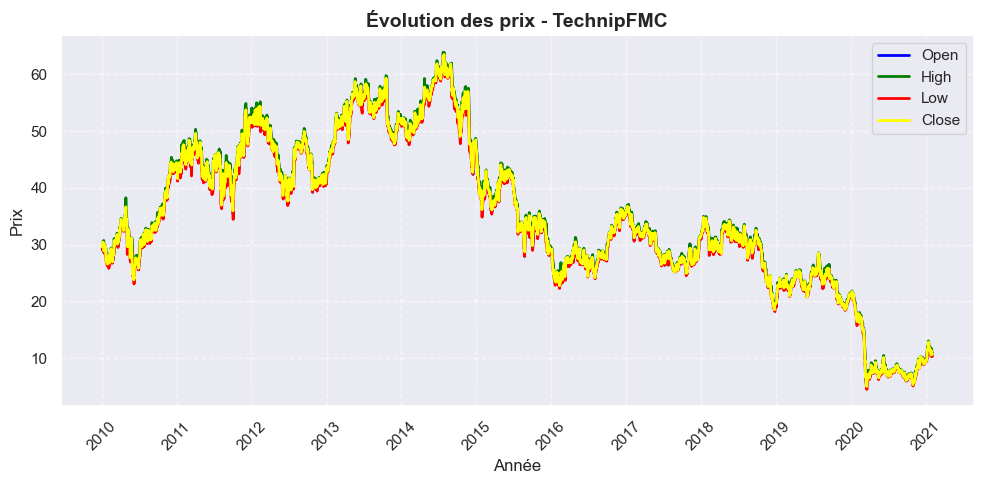

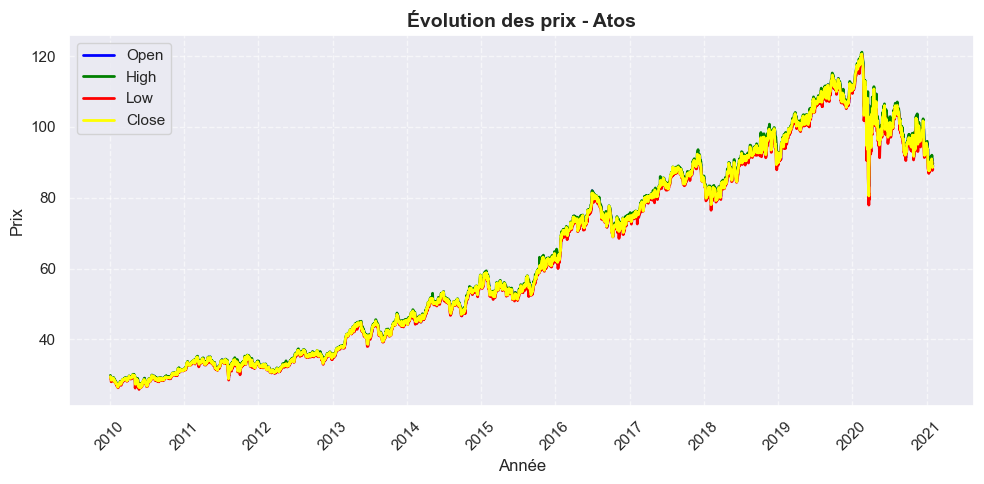

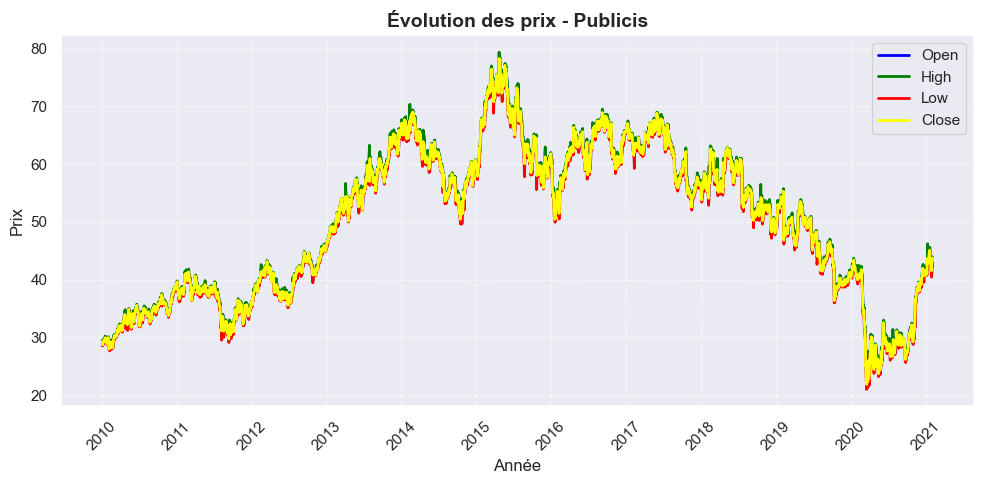

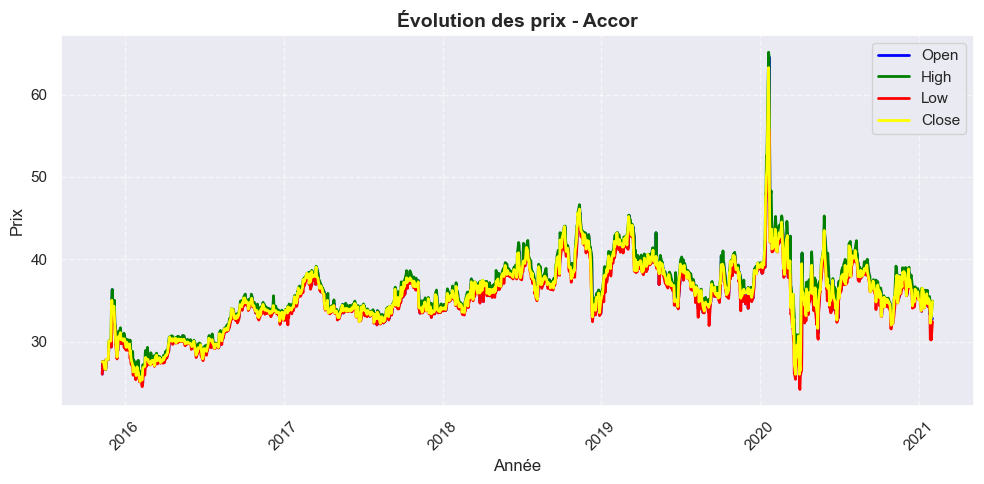

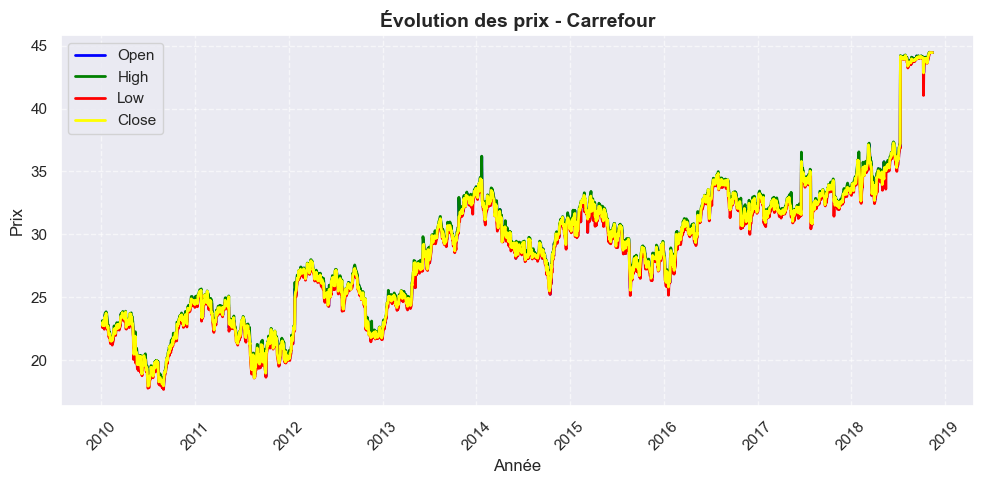

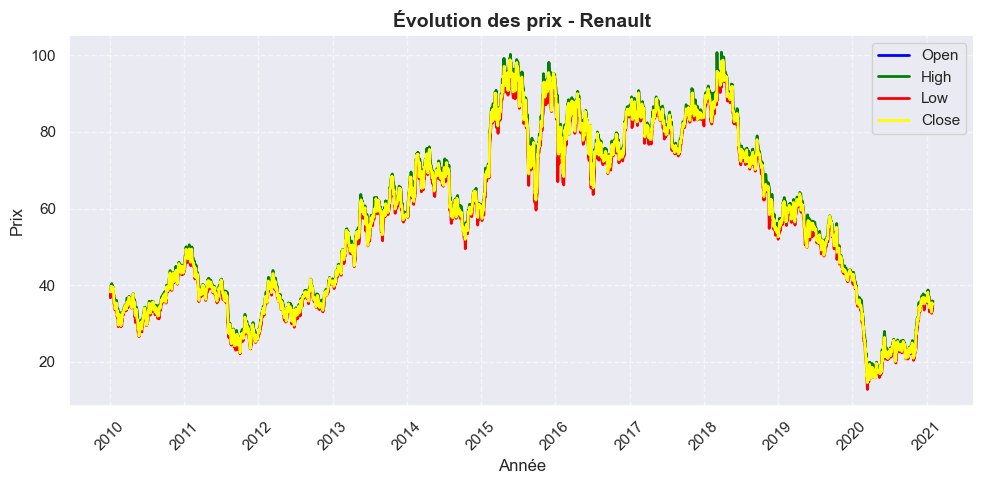

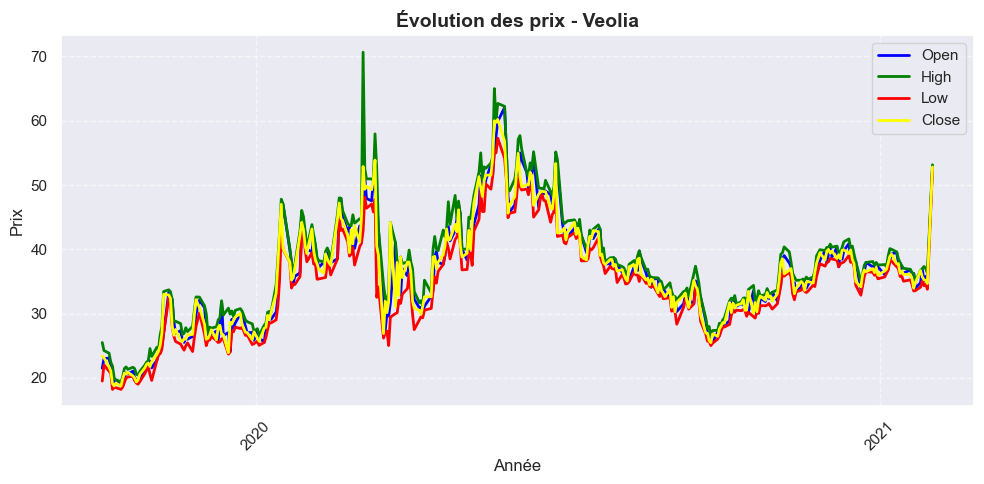

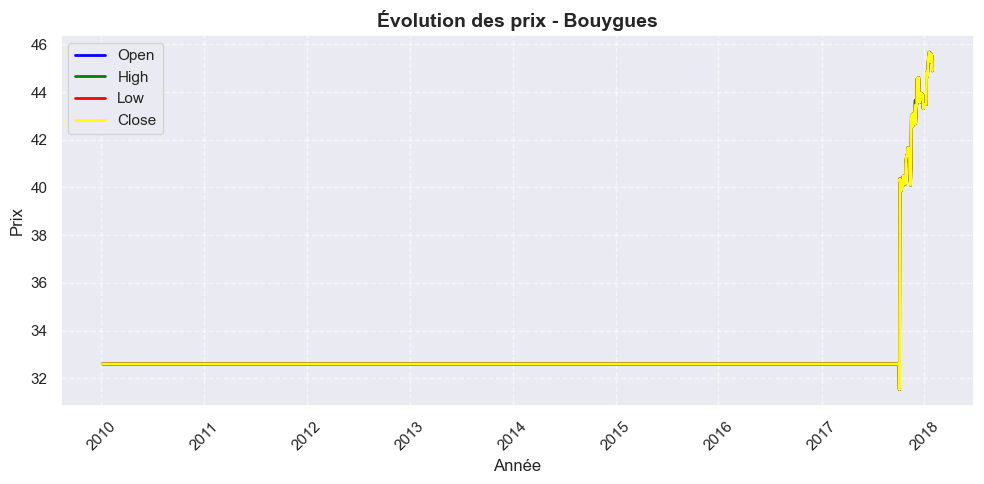

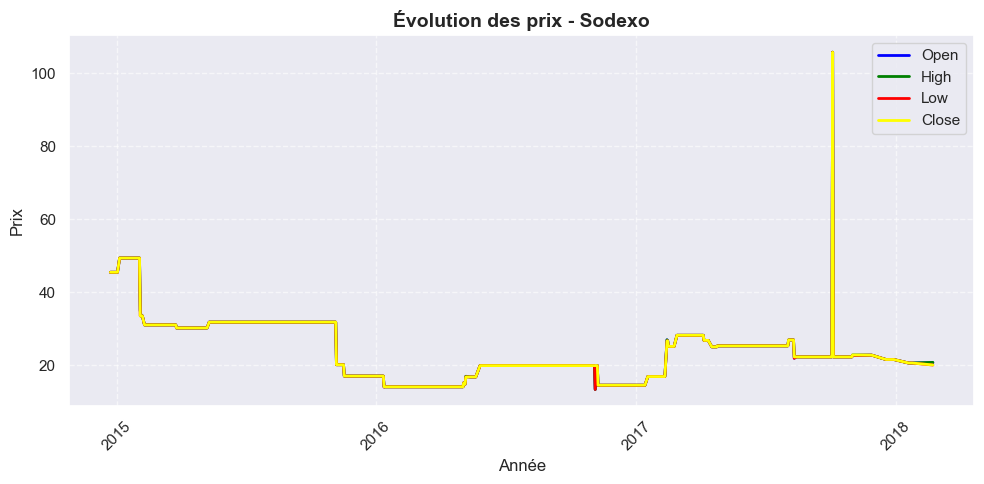

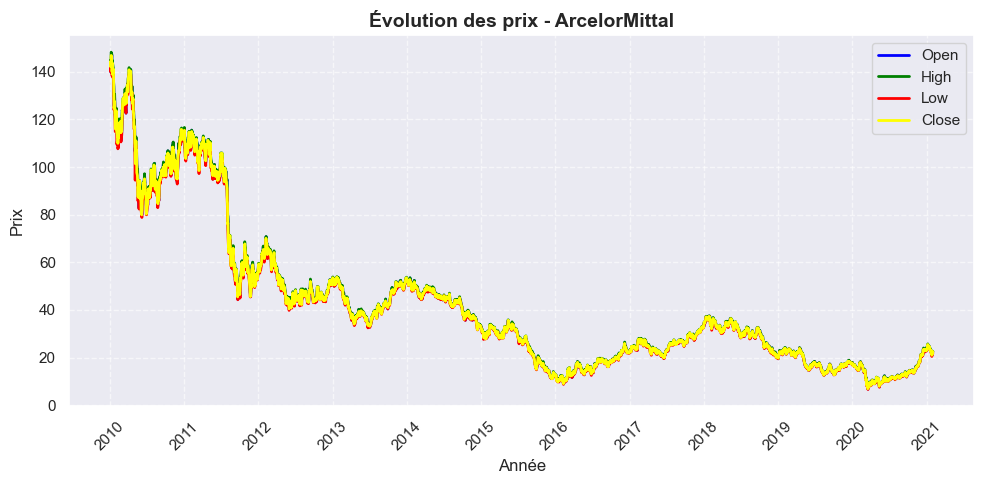

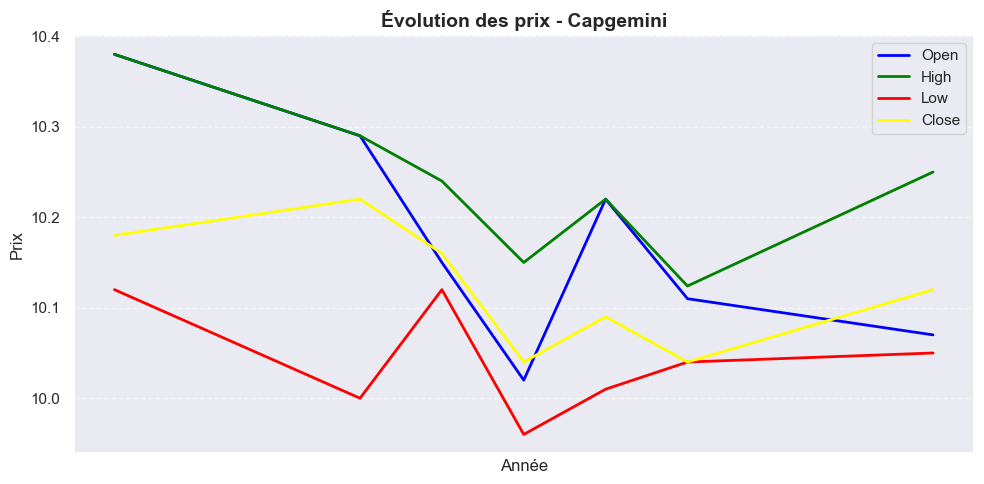

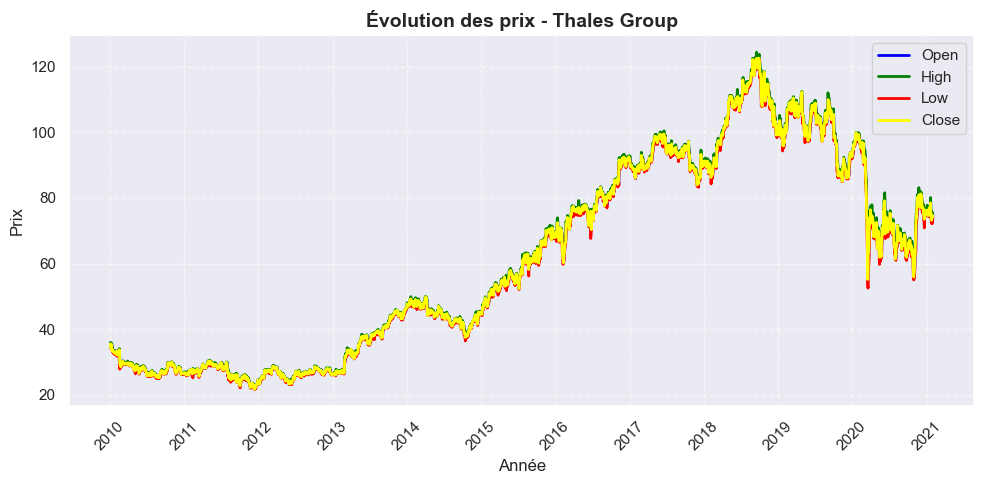

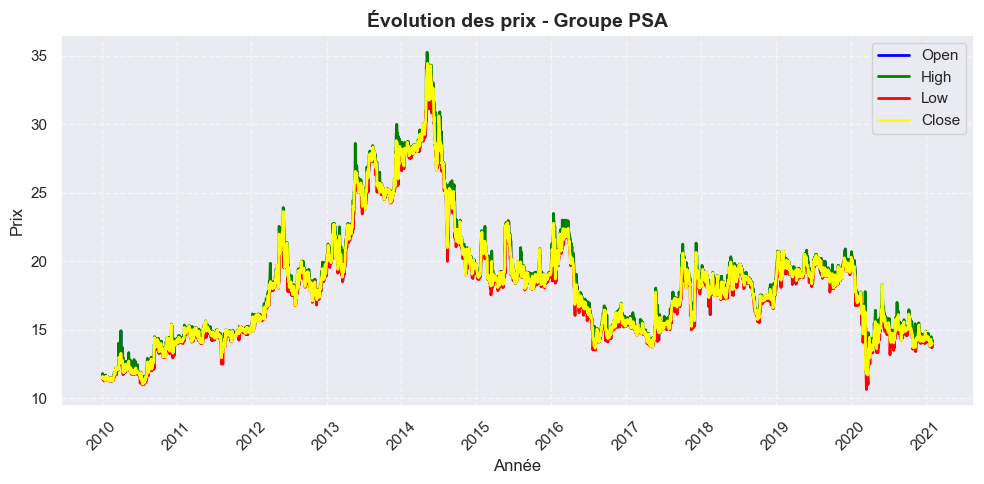

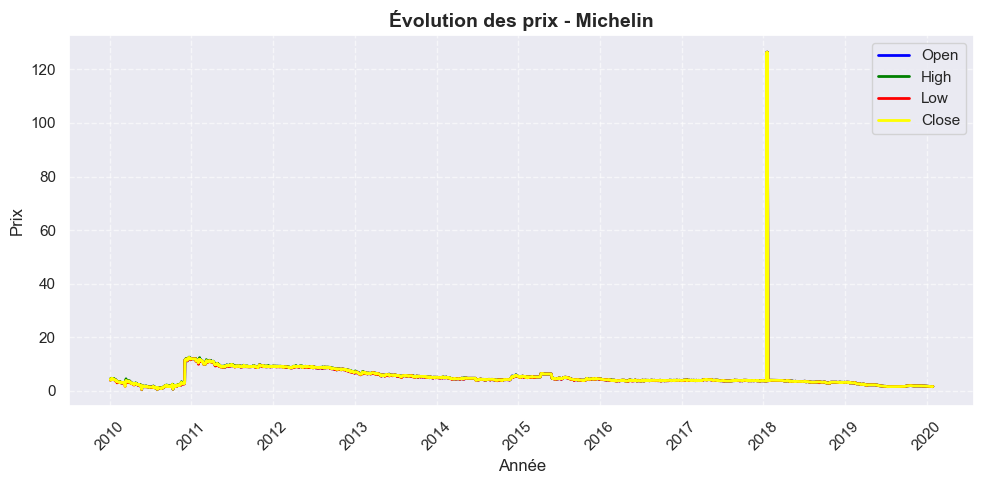

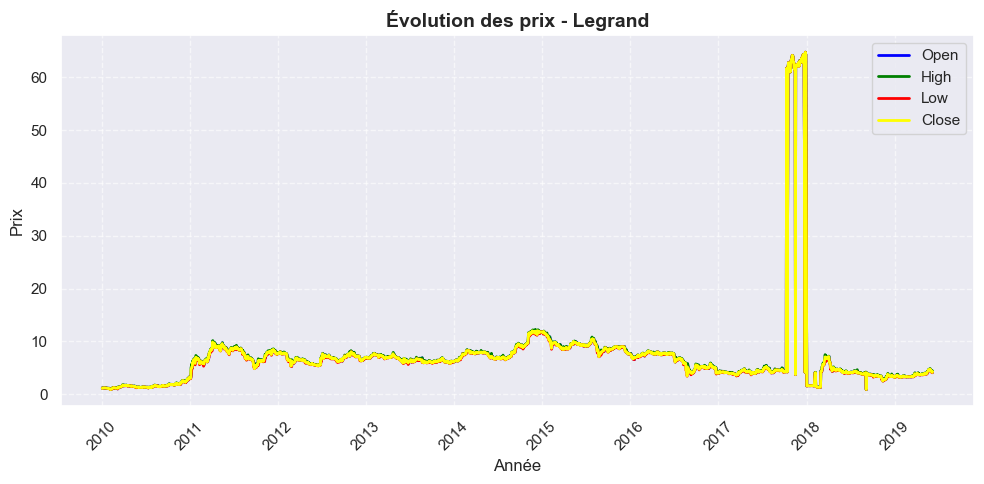

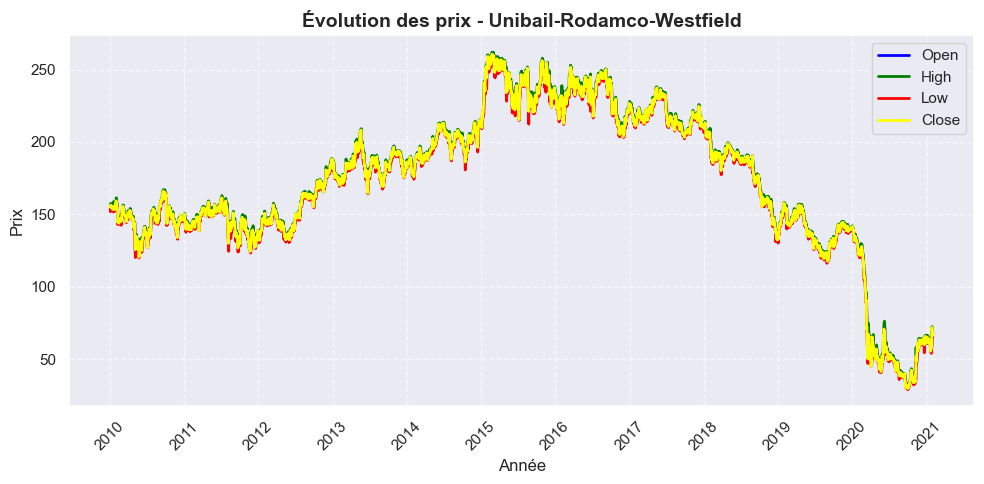

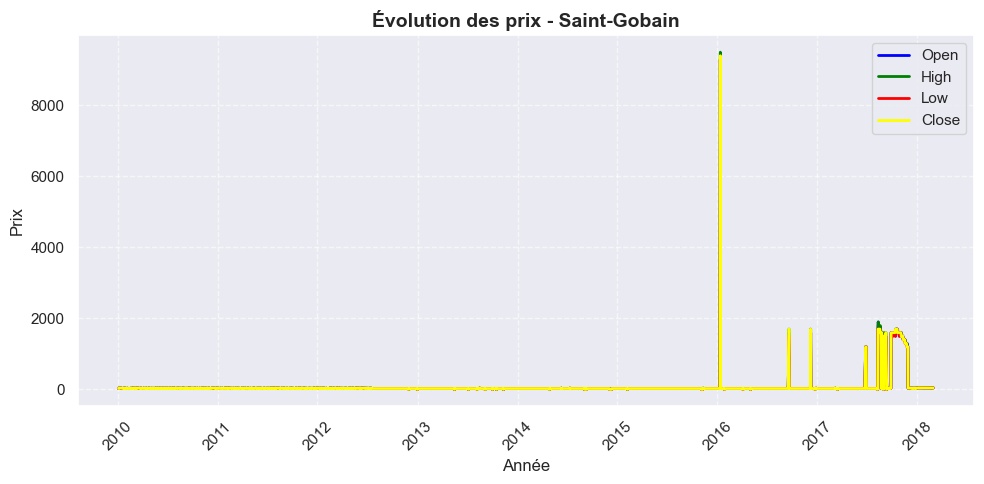

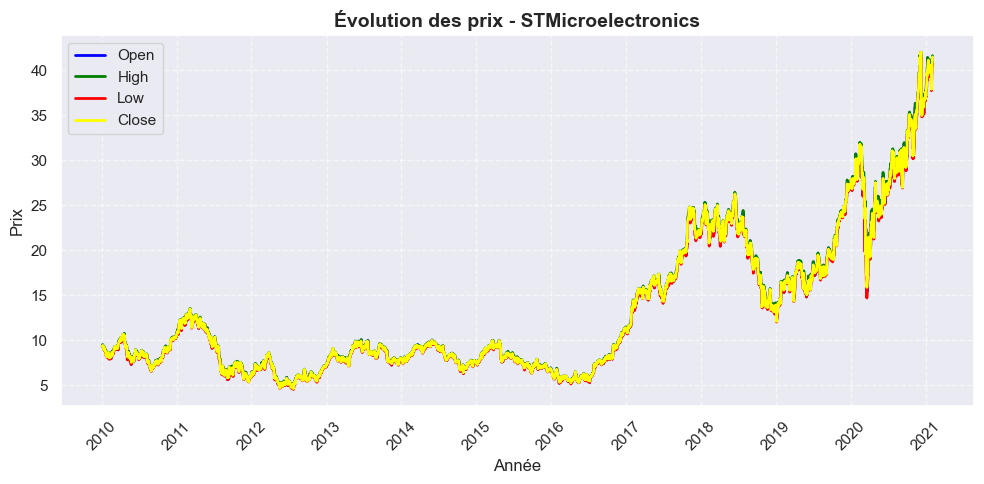

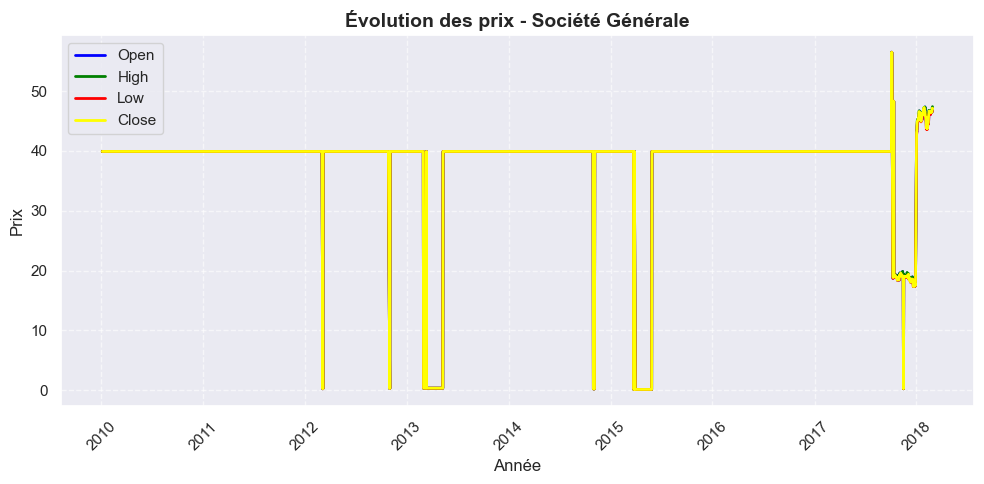

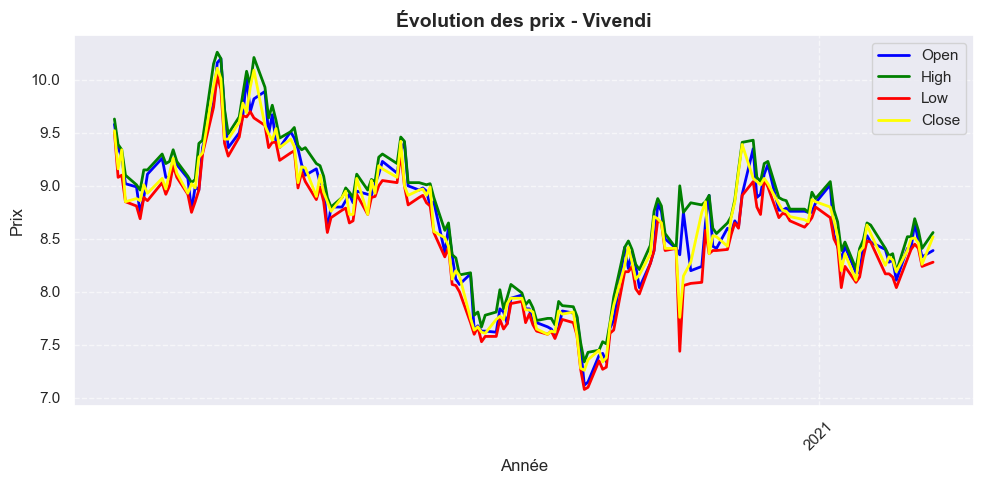

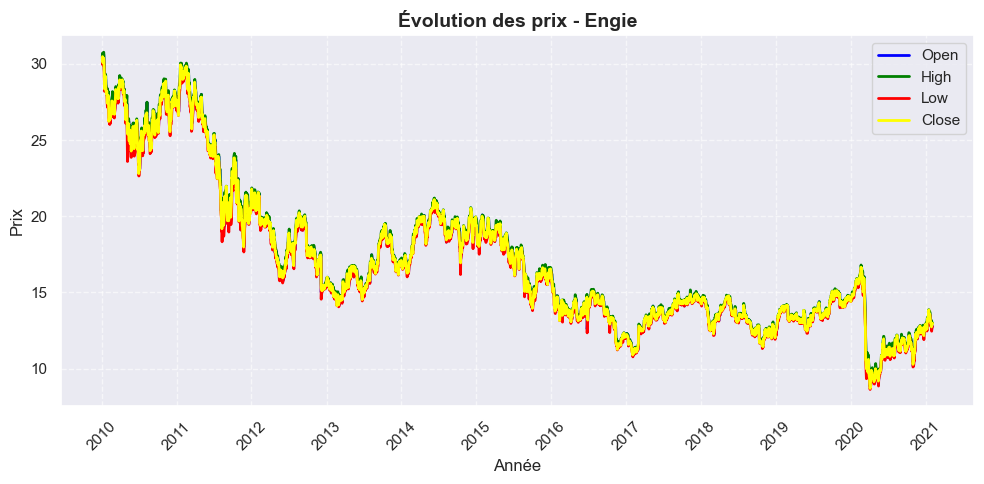

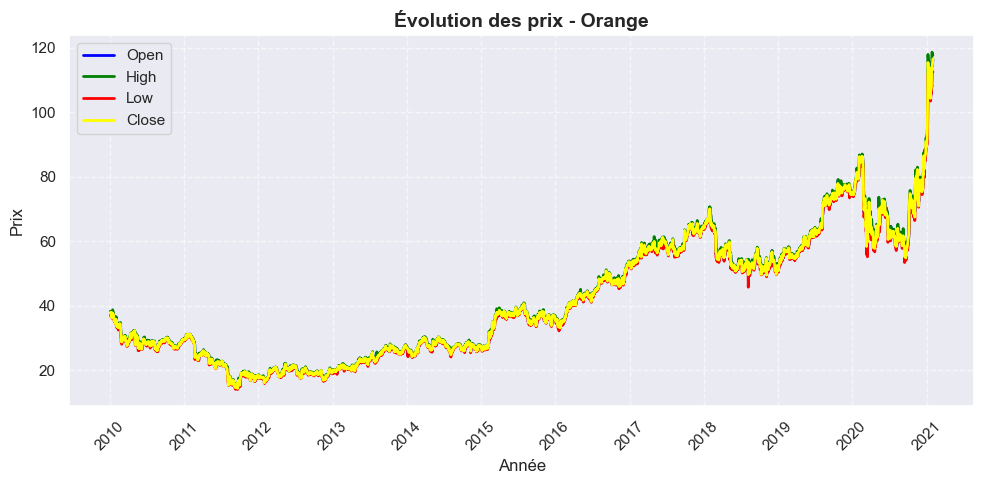

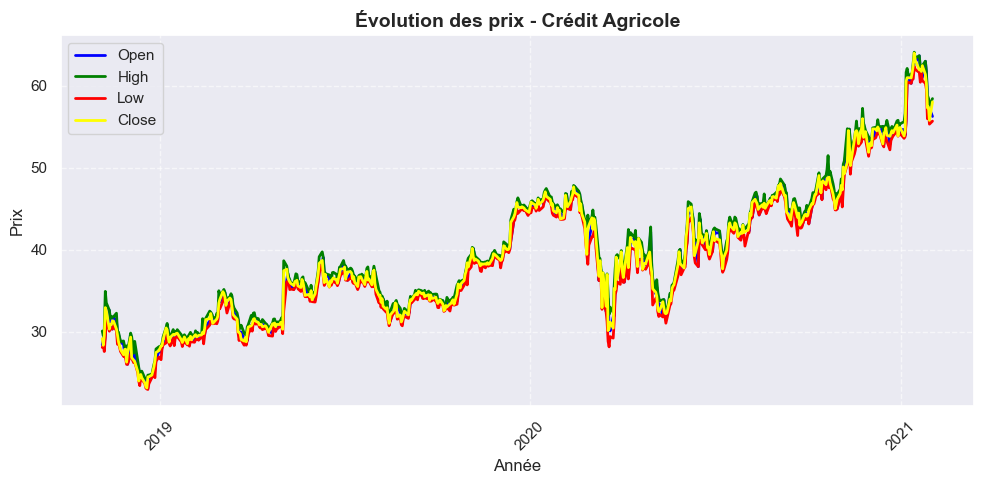

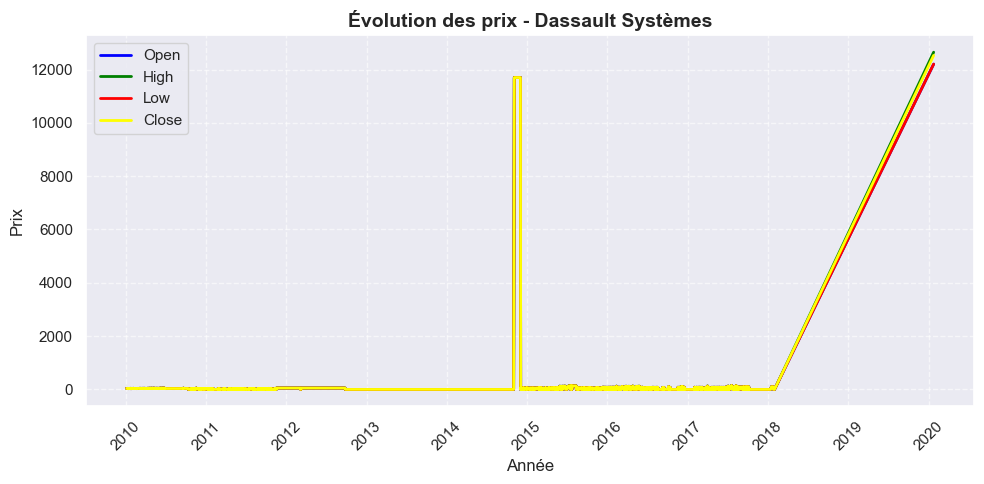

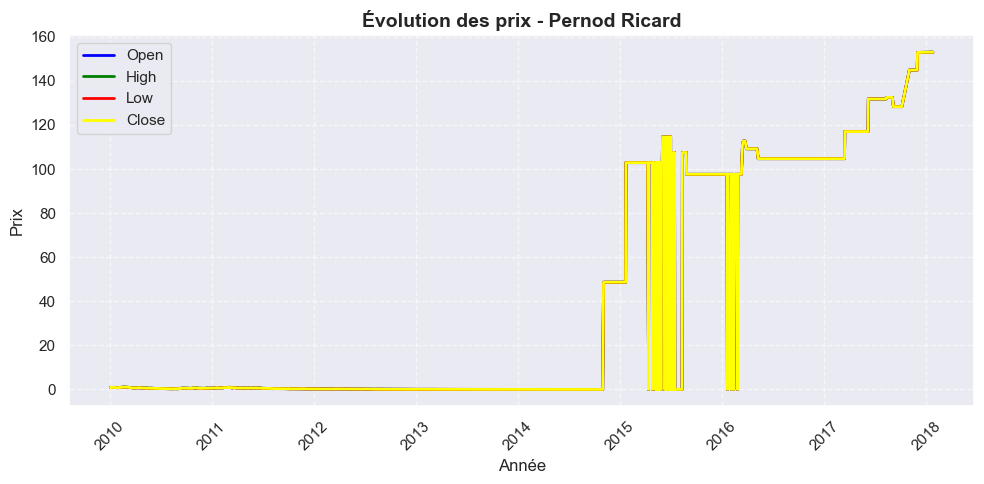

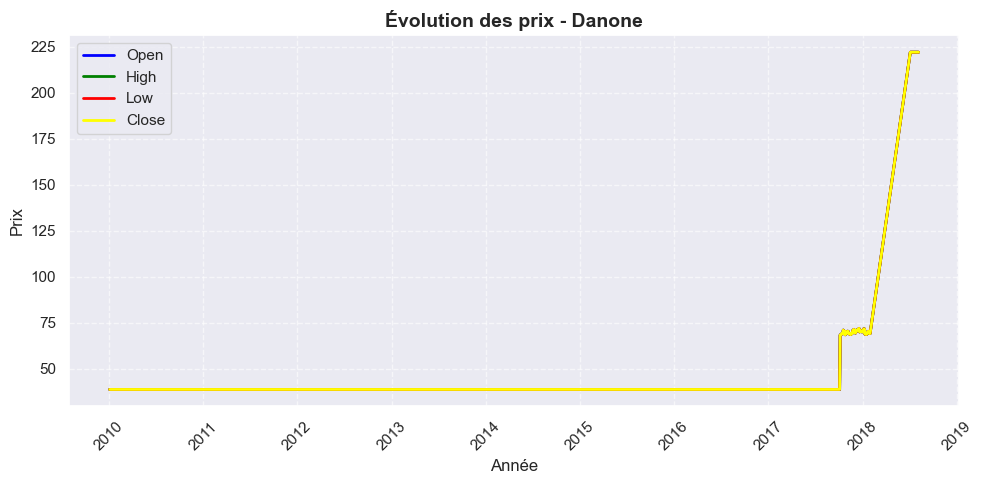

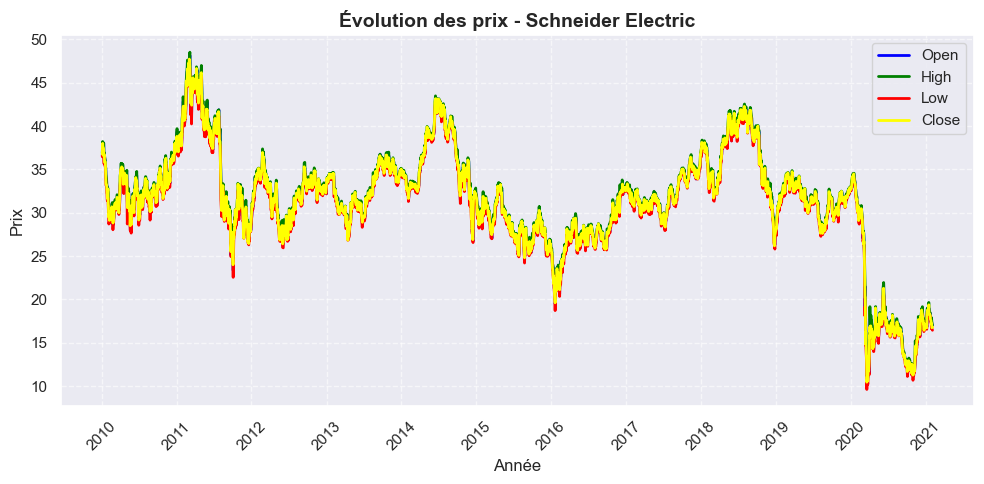

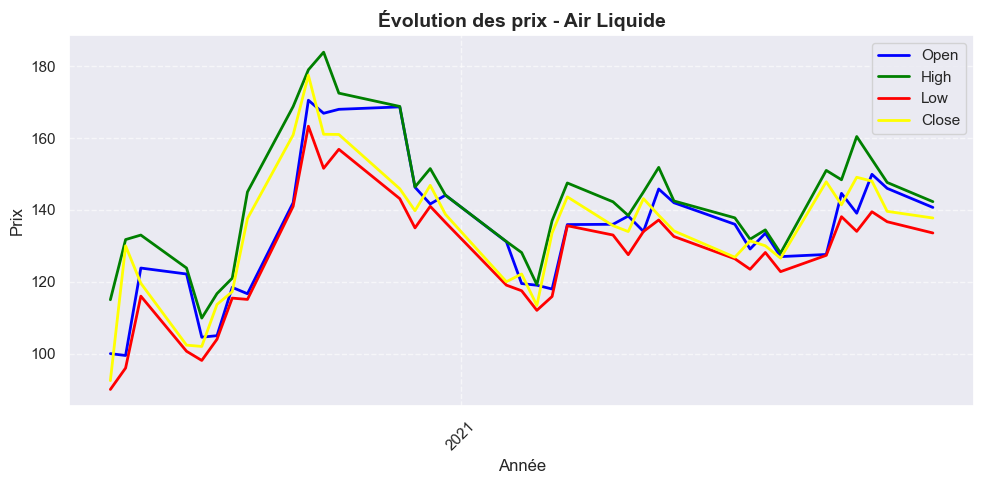

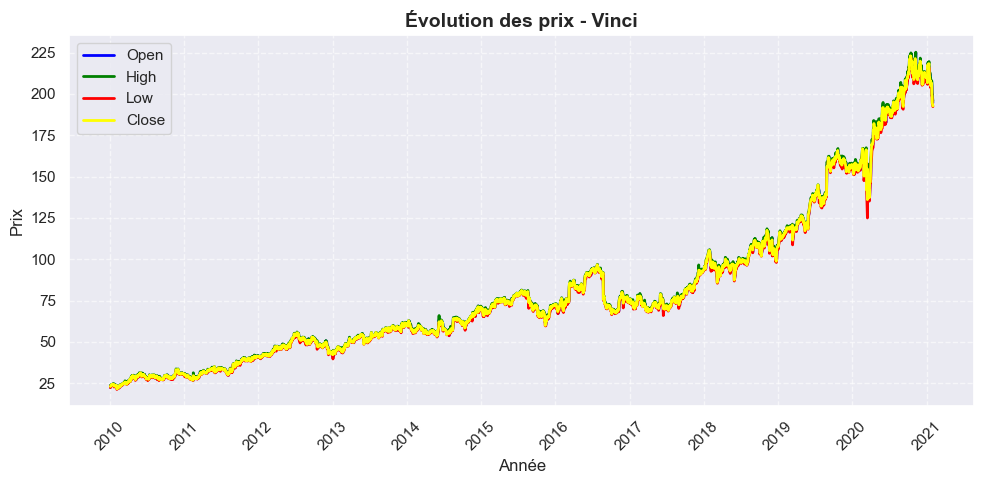

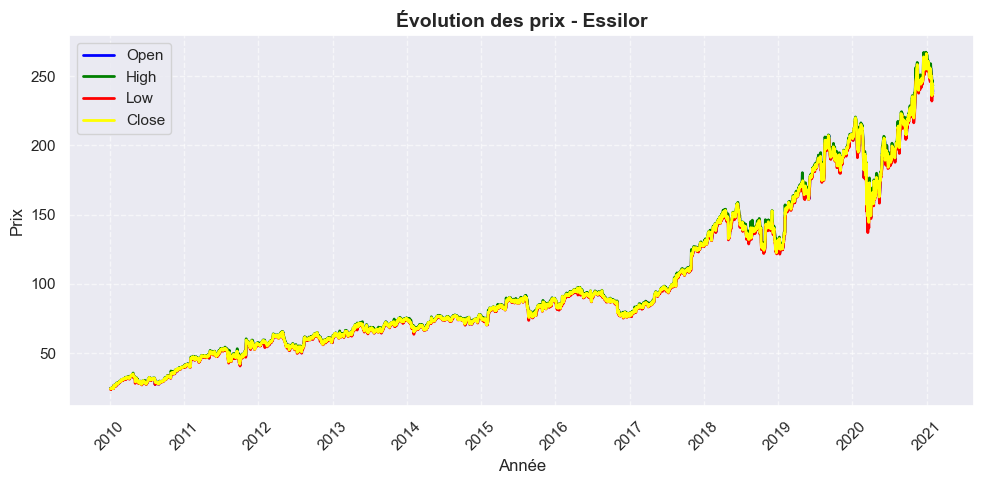

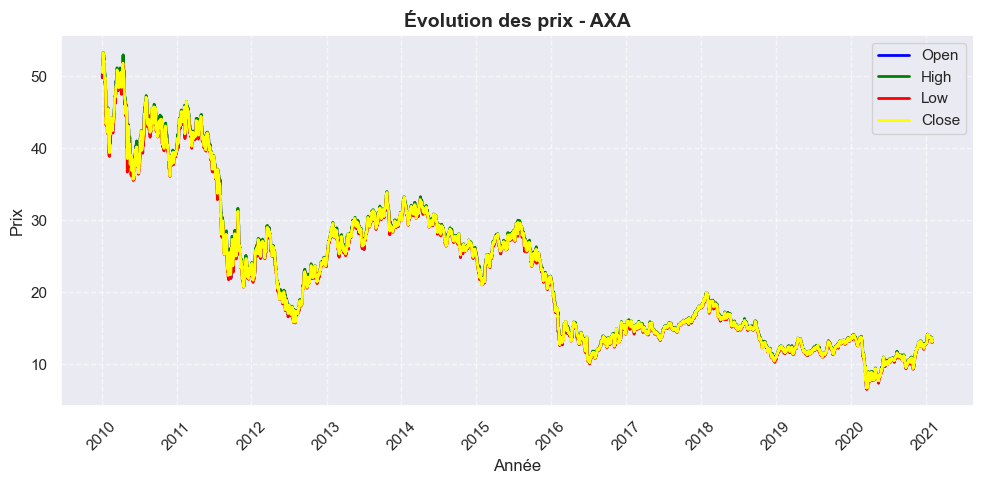

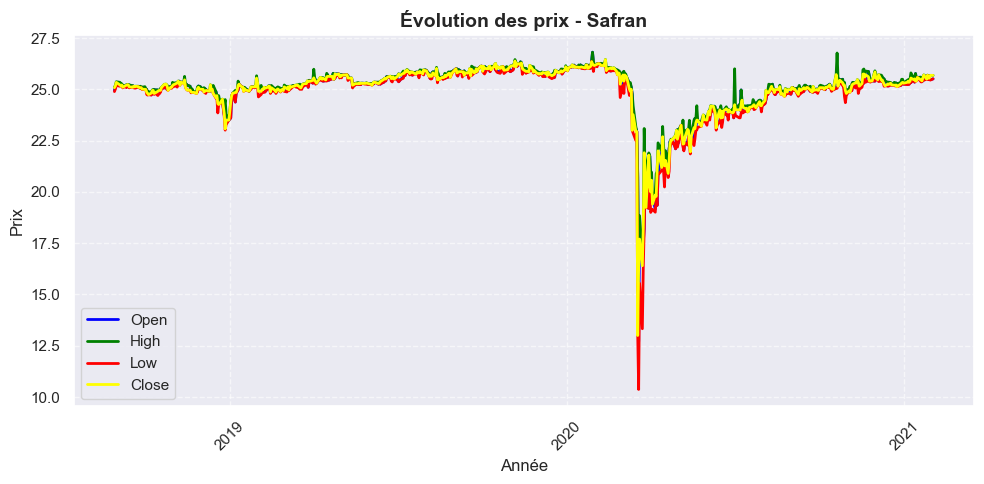

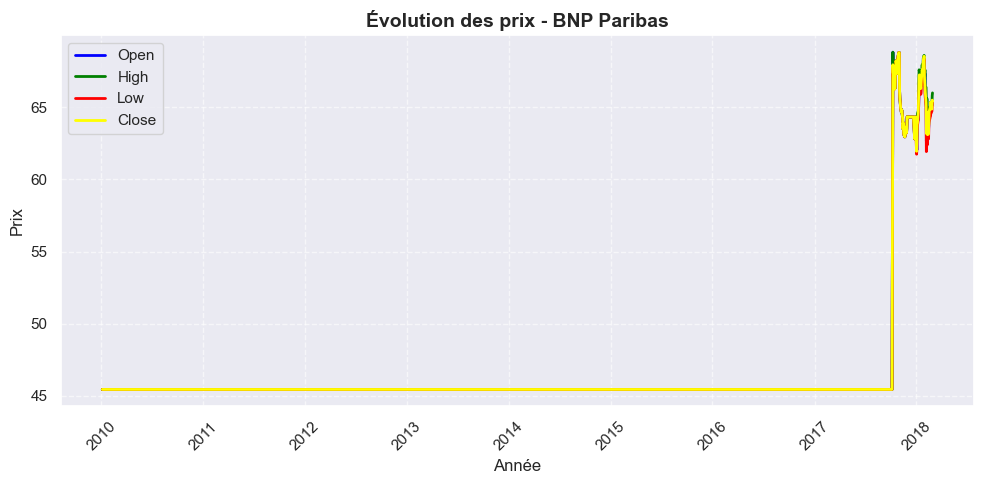

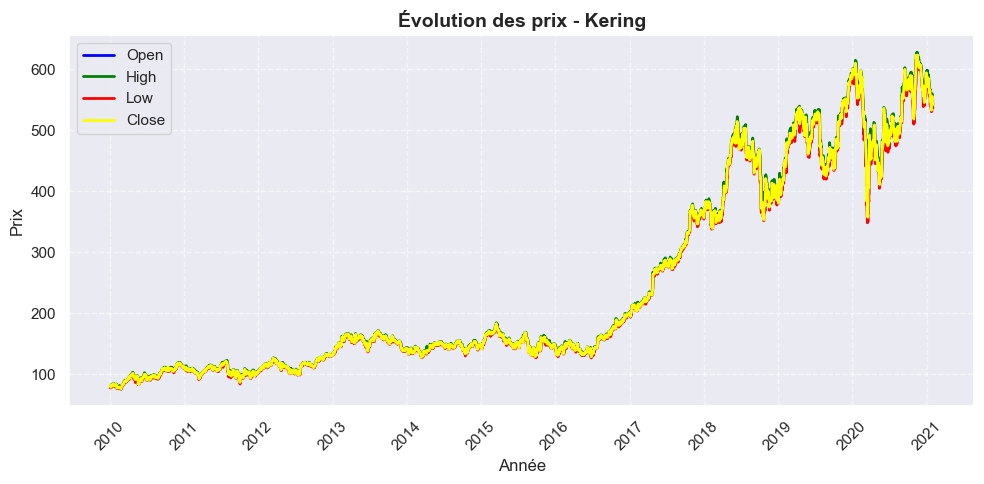

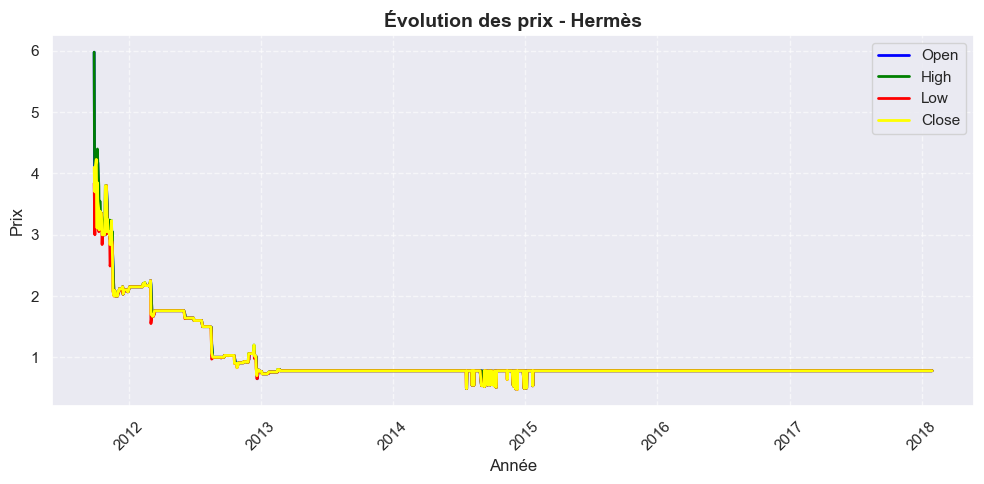

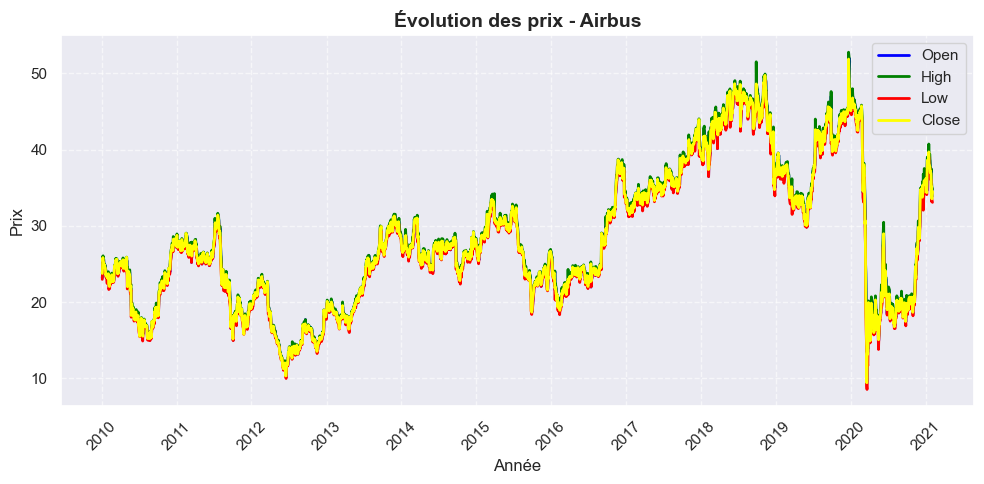

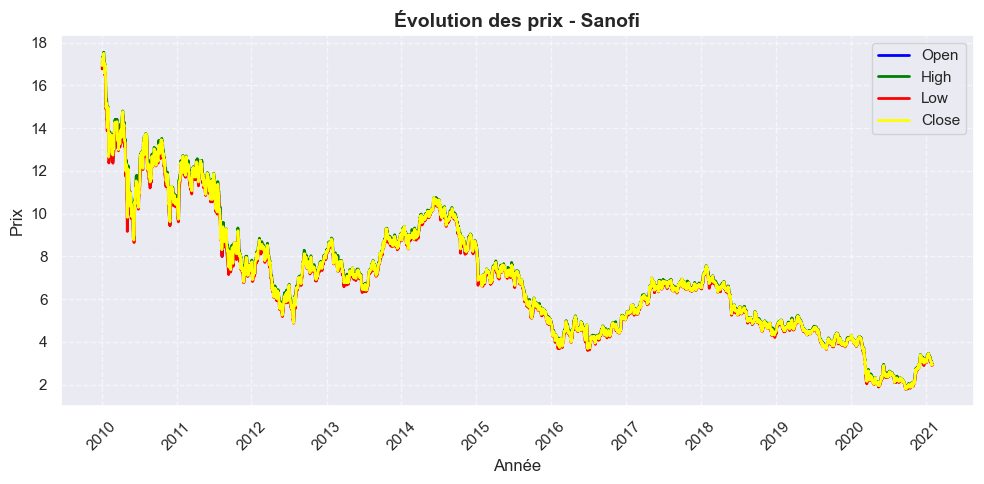

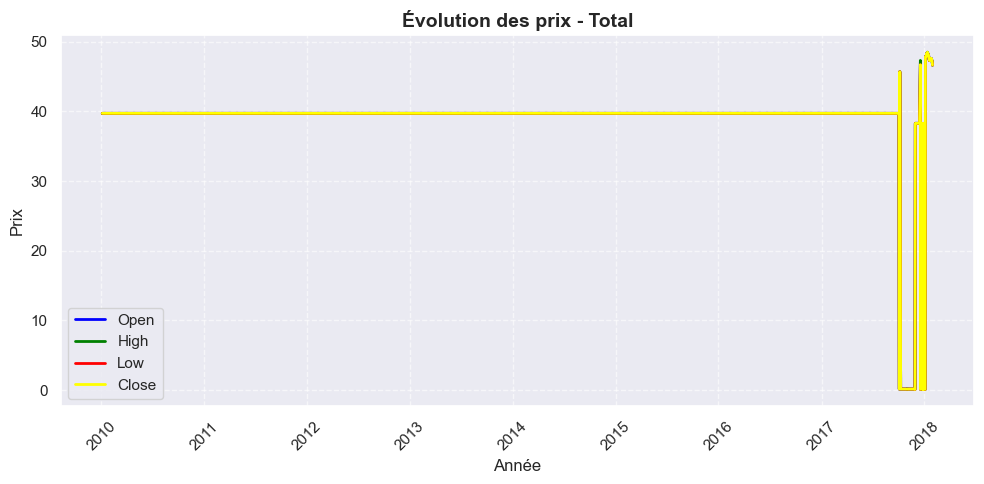

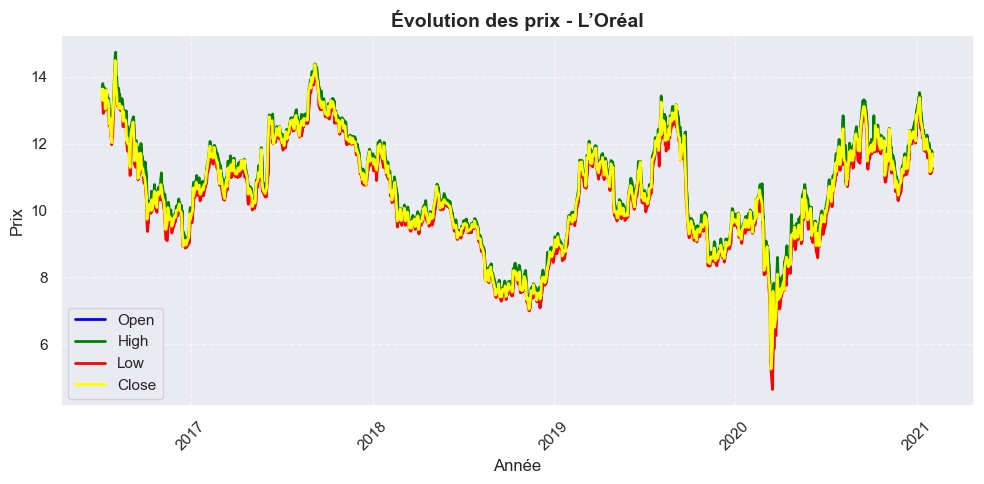

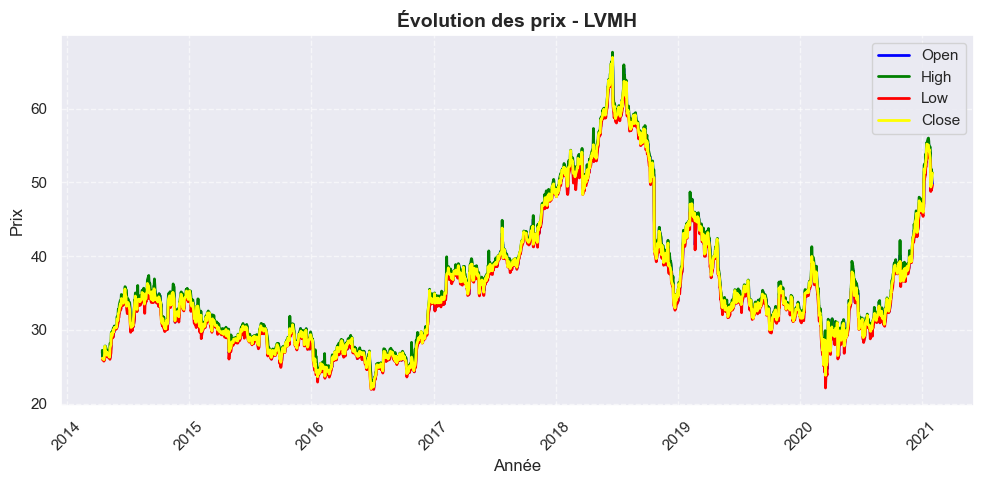

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Conversion robuste des dates (formats mixtes)
data['Date'] = pd.to_datetime(
    data['Date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
color_map = {
    'Open': 'blue',
    'High': 'green',
    'Low': 'red',
    'Close': 'yellow'
}


data = data.dropna(subset=['Date'])

for company in company_distinct:
    plt.figure(figsize=(10, 5))
    
    subset = data[data['CompanyName'] == company].sort_values('Date')
    
    for price_type in ['Open', 'High', 'Low', 'Close']:
        plt.plot(
            subset['Date'], 
            subset[price_type], 
            label=price_type, 
            color=color_map[price_type],
            linewidth=2
        )
    
    plt.title(f"Évolution des prix - {company}", fontsize=14, fontweight='bold')
    plt.xlabel("Année")
    plt.ylabel("Prix")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(1))   # 1 tick par an
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

Ces graphiques nous montrent que certaines entreprises n'ont pas de données sur toute la période allant de 2010 à 2021 (LVMH, total, l'oréal,Hermès
BNP, Safran et bien d'autres encore) donc notre dataset n'est pas homogène comme on l'a supposé au début.

Pour les modèles que nous allons implémenter, nous allons choisir des actifs avec des données stables sur le temps et qui présente des variations
Plus il y a de variations et moins la courbe est linéaire ce qui veut dire qu'il faudra trouver un modèle plus complexe.

In [57]:
companies_a_etudier = ['Airbus', 'TechnipFMC', 'Atos', 'Publicis', 'Carrefour', 'Renault', 'ArcelorMittal', 'Thales Group', 'Groupe PSA',
                       'Unibail-Rodamco-Westfield', 'STMicorelectronics', 'Engie', 'Orange', 'Schneider Electric', 'Vinci', 'Essilor', 'Axa',
                       'Kering', 'Airbus', 'Sanofi']
companies_a_etudier


['Airbus',
 'TechnipFMC',
 'Atos',
 'Publicis',
 'Carrefour',
 'Renault',
 'ArcelorMittal',
 'Thales Group',
 'Groupe PSA',
 'Unibail-Rodamco-Westfield',
 'STMicorelectronics',
 'Engie',
 'Orange',
 'Schneider Electric',
 'Vinci',
 'Essilor',
 'Axa',
 'Kering',
 'Airbus',
 'Sanofi']

Avant de nous lancer dans l'apprentissage des données, essayons de modéliser une nouvelle fois l'évolution des prix avec 
la bibliothèque Seaborn.
Seaborn est une bibliothèque construite sur matplotlib mais elle permet de simplifier le code.
On a la possibilité de faire des regroupements par catégories automatiquement grâce au hue (contrairement au color_map), 
de faire des graphiques statistiques(bar chart, heat map, line plot), et on peut également ajouter du style à nos visualisation

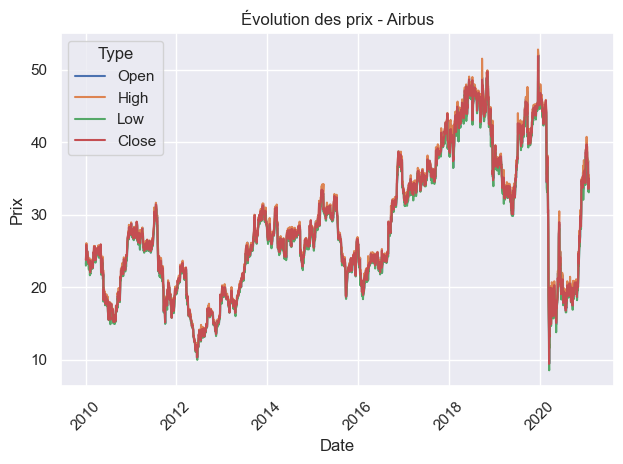

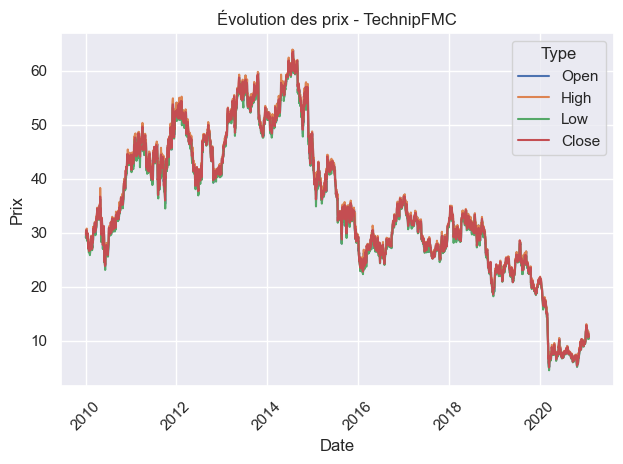

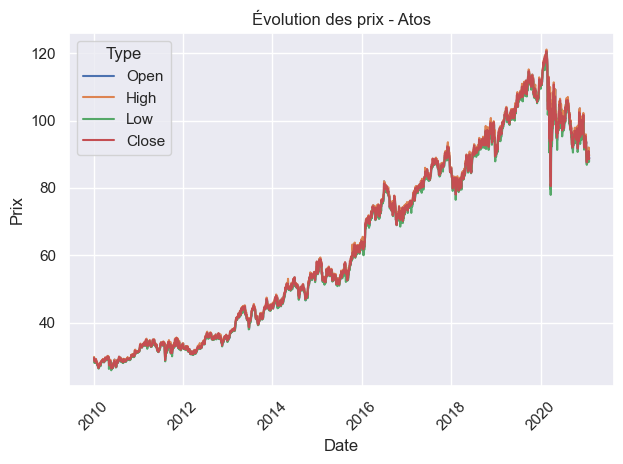

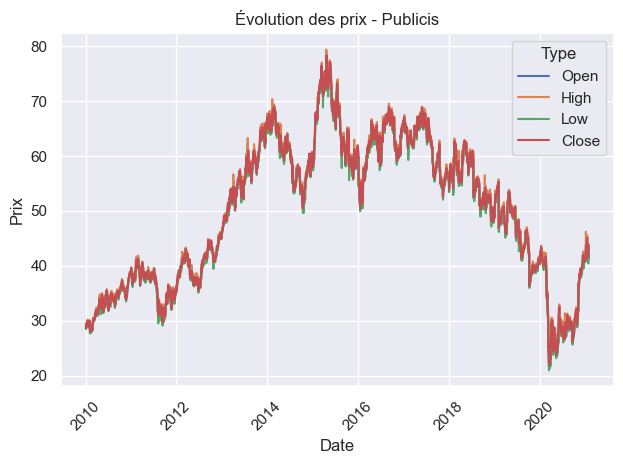

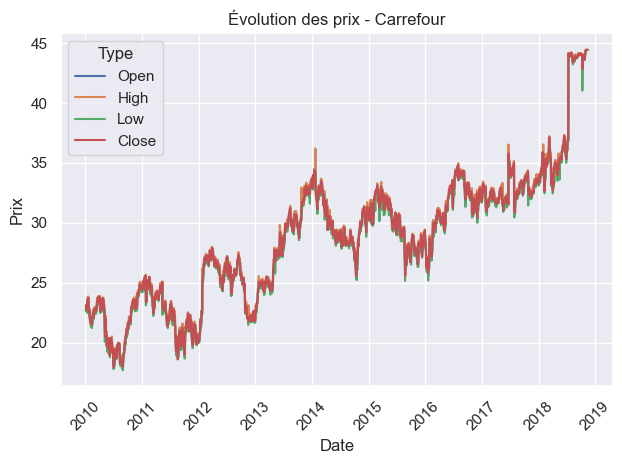

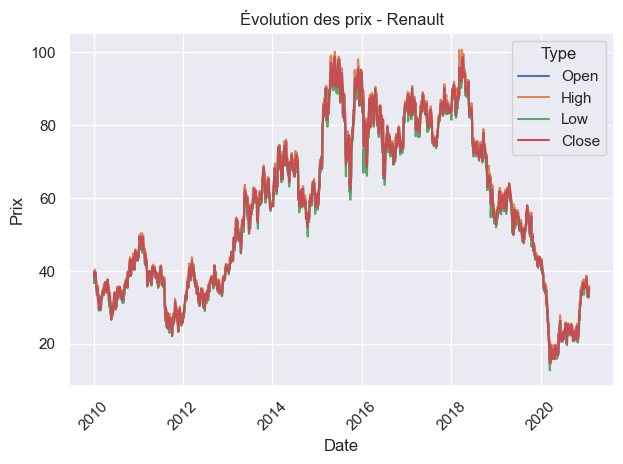

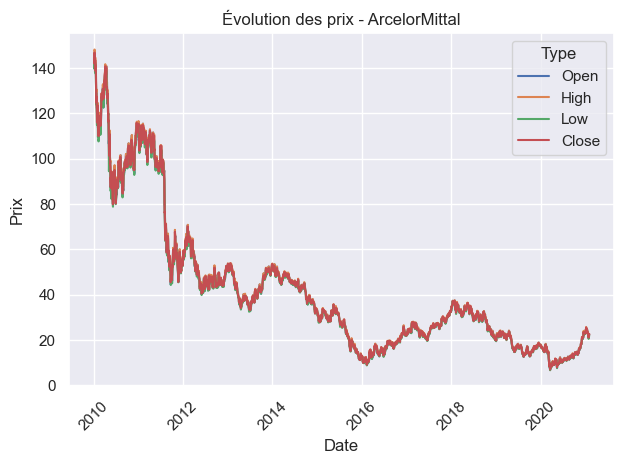

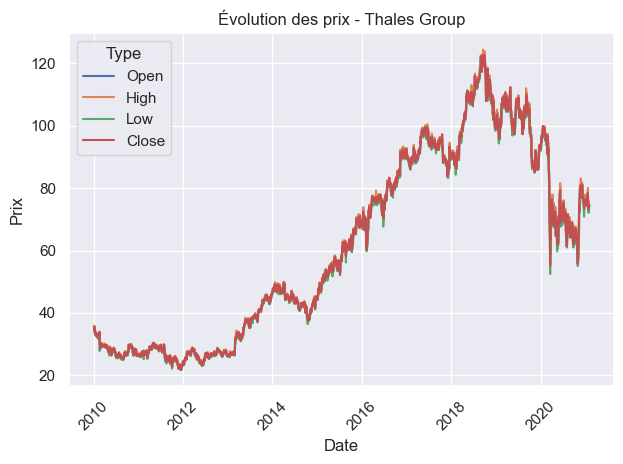

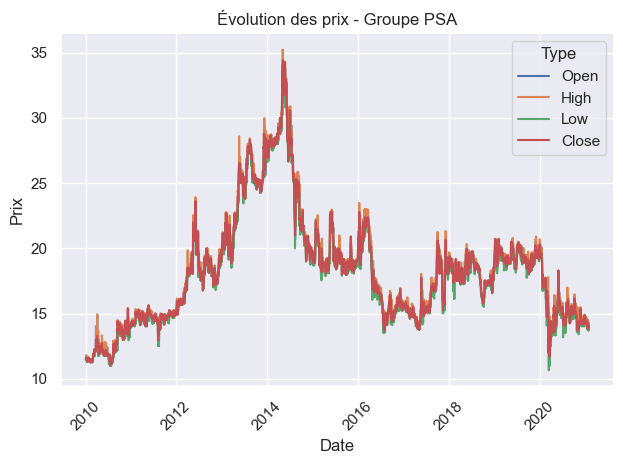

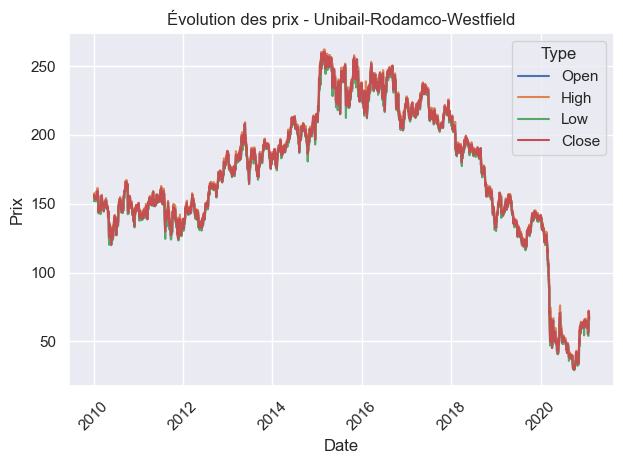

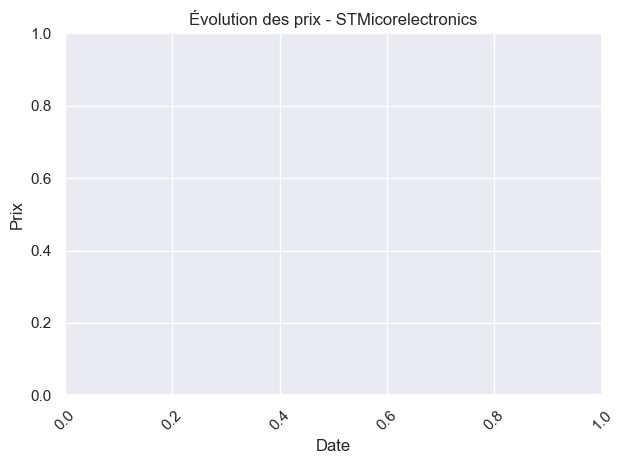

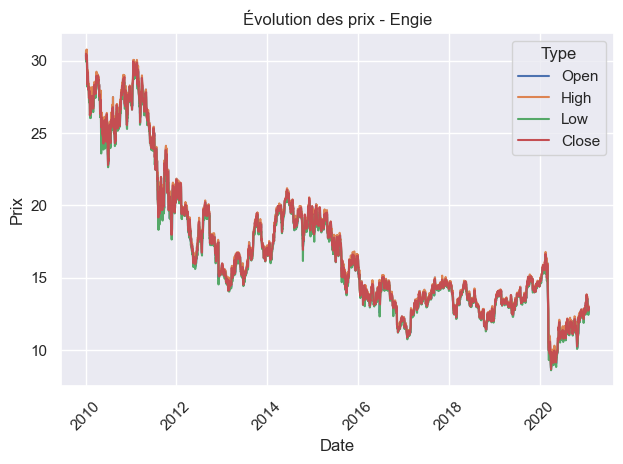

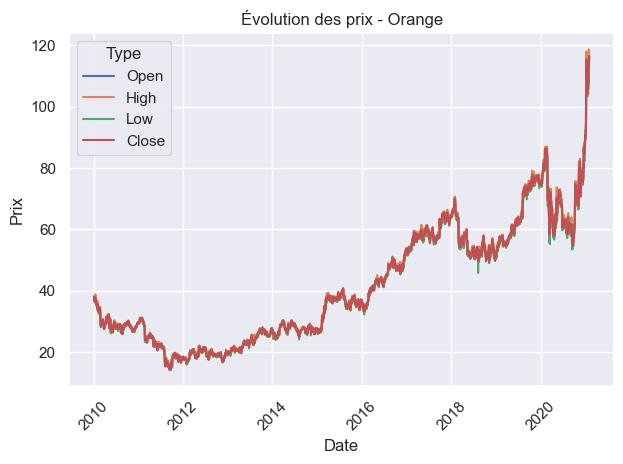

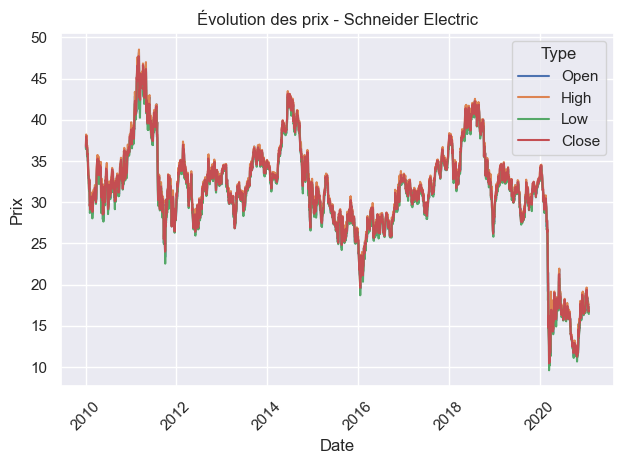

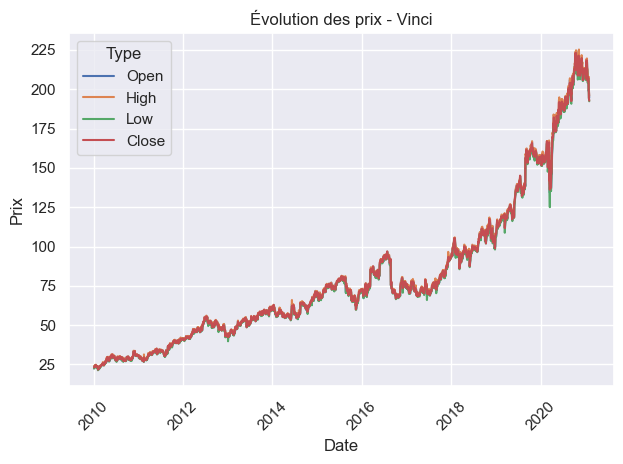

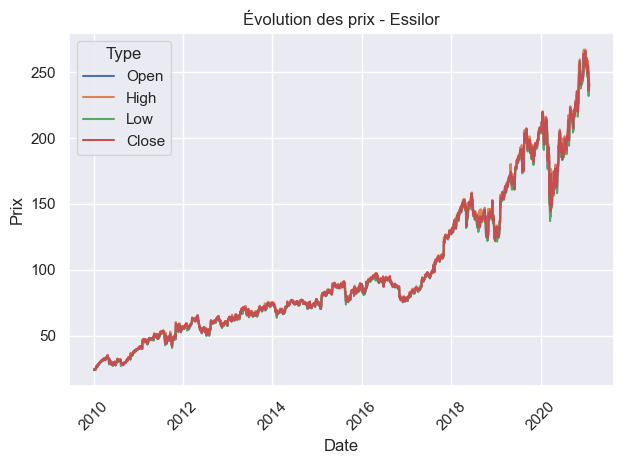

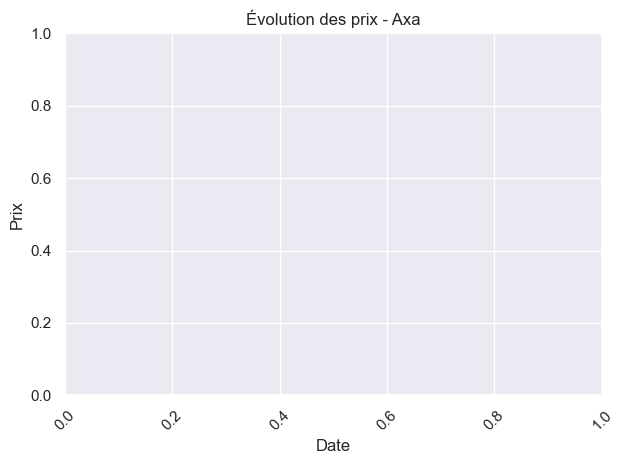

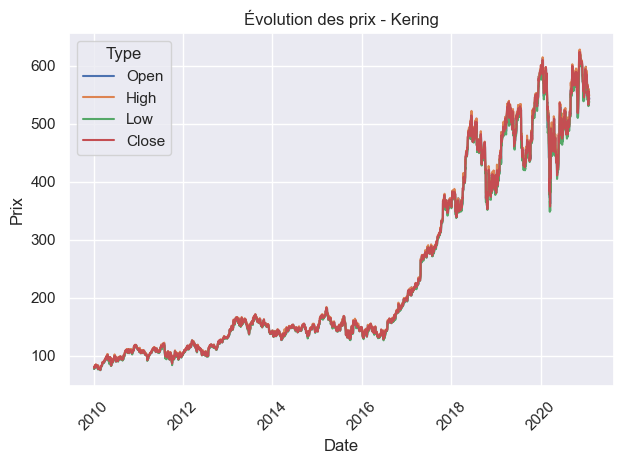

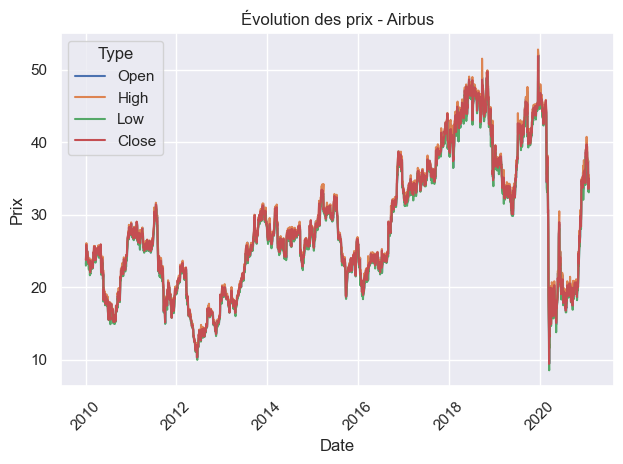

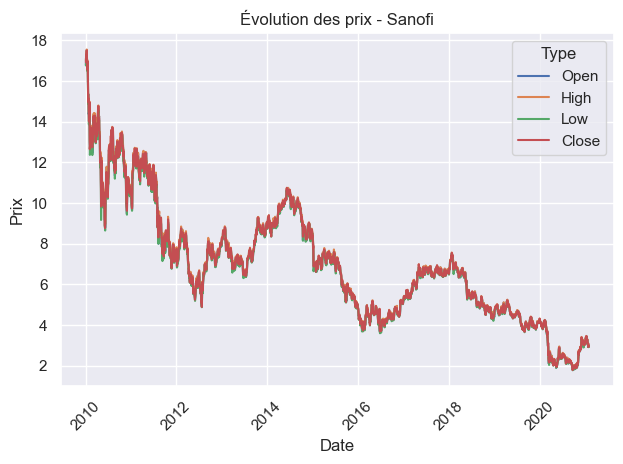

In [58]:
#Avec Seaborn

import seaborn as sns
sns.set_theme(style="darkgrid")
#sns.relplot(data=data, x="Date", y="Price", kind="line")
for company in companies_a_etudier:
    # 1. Filtrage des données
    company_values = data[data['CompanyName'] == company].sort_values('Date')
    
    # 2. On doit "fondre" (melt) les données pour que Seaborn comprenne les 4 prix
    # Cela transforme les colonnes [Open, High, Low, Close] en deux colonnes : 'Type' et 'Price'
    new_company_values = company_values.melt(id_vars=['Date'], 
                              value_vars=['Open', 'High', 'Low', 'Close'], 
                              var_name='Type', 
                              value_name='Prix')
    sns.lineplot(data=new_company_values, x="Date", y="Prix",hue="Type" )
    plt.title(f"Évolution des prix - {company}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Passons maintenant à la partie statistique.

- Le rendement: En finance quantitative, travailler sur les prix de clôture bruts est proscrit car ces séries ne sont pas stationnaires et sont soumises à beaucoup de bruit. Pour stabiliser les propriétés,  on va calculer le rendement simple discret à chaque pas de temps t.

La représentation graphique de ces rendements est réalisée via un Histogramme combiné avec une Estimation de la Densité par Noyau (KDE). Cet outil permet de vérifier visuellement si la distribution des rendements s'ajuste à une loi normale.
En théorie les rendement suivent une loi normale, mais en finance réelle, on observe fréquemment une cloche écrasée avec des queues épaisses (fat tails). Celles-ci signifient que la probabilité d'occurrence de variations extrêmes (Mise en évidence du risque de krach ou d'anomalies de marché ) est supérieure à la théorie gaussienne standard. 


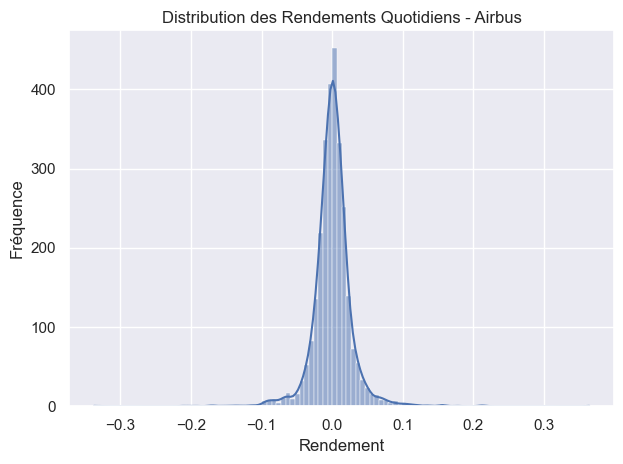

In [19]:
#Quelques statistiques

#Calcul du rendement
"""
all_returns = {}
for company in companies_a_etudier:
    # 1. Filtrage des données
    company_values = data[data['CompanyName'] == company].sort_values('Date')
    company_values['returns'] = company_values['Close'].pct_change()
    #La première ligne est nulle à cause du pct_change() car il n'y a pas de valeur antérieure
    sns.histplot(data=company_values['returns'].dropna(), kde=True)
    plt.title(f"Évolution des prix - {company}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
"""

#Prenons le cas spécifique de Airbus pour la suite de nos calculs
#C'est l'une des companies dont la cloche monte le plus donc avec le plus grand risque de krach
#Cette qualité pourrait être interessante à étudier pour nos prédictions

company = 'Airbus'
company_values = data[data['CompanyName'] == company].sort_values('Date')
company_values['returns'] = company_values['Close'].pct_change()
#La première ligne est nulle à cause du pct_change() car il n'y a pas de valeur antérieure
sns.histplot(data=company_values['returns'].dropna(), kde=True)
plt.title(f"Distribution des Rendements Quotidiens - {company}")
plt.xlabel("Rendement")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

- La volatilité glissante : 
On constate une forte incertitude en 2020 qui coïncide avec la pandémie 2020 : C'est une période de forte instabilité.
Généralement, Un forte variation dans la volatilité indique une période de stress de marché ou une annonce de résultats financiers importante.
Si une action grimpe de 10% trois jours de suite, son écart-type va exploser. Pourtant, ce n'est pas un krach, c'est une euphorie boursière.

En finance, la volatilité est souvent asymétrique : elle a tendance à monter beaucoup plus violemment et rapidement lors des baisses que lors des hausses.
Cela s'explique par le fait que la baisse est plus facile que la hausse. La hausse est souvent un processus lent de construction de confiance, 
tandis que la baisse est souvent déclenchée par la panique. Comme le veut le dicton boursier : 
"Le marché prend l'escalier pour monter, mais il prend l'ascenseur pour descendre." 
Cette descente rapide crée des écarts de prix énormes en peu de temps, ce qui fait exploser te calcul d'écart-type.

La suite du projet consiste donc à déterminer si cette forte variation ou amplitude est annonciatrice d'un krach ou d'une crise économique
en combinant la volatilité avec d'autres indicateurs (volumes, analyse de sentiment via NewsAPI ou corrélations), les modèles de ML (Régression ou Classification),
nous tenteront de déterminer si cette agitation est le signe d'un retournement de tendance


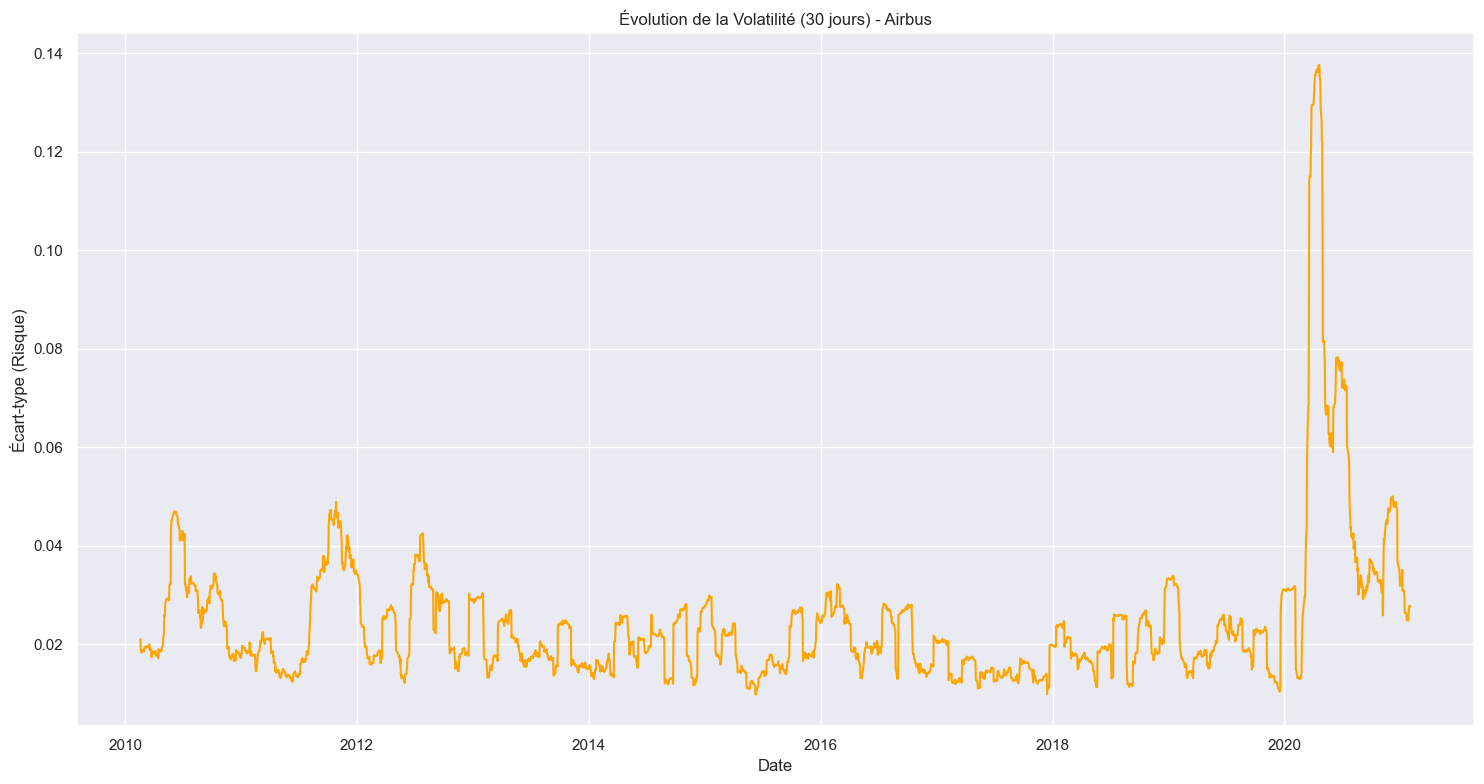

In [20]:
#Rolling volatility

company_values['volatility_30'] = company_values['returns'].rolling(window=30).std()
plt.figure(figsize=(15, 8))
plt.plot(company_values['Date'], company_values['volatility_30'], color='orange', label='Volatilité 30j')
#sns.relplot(data=company_values, x="Date", y="volatility_30", kind="line")
plt.title(f"Évolution de la Volatilité (30 jours) - {company}")
plt.xlabel("Date")
plt.ylabel("Écart-type (Risque)")
plt.tight_layout()
plt.show()



- La correlation :
On va utiliser une heatmap. Elle utilise des couleurs (souvent du rouge au bleu) pour montrer quelles actions bougent ensemble.
Notre matrice de correlation se calcule sur nos elts companies_a_etudier pour mesurer la relation entre plusieurs actifs

Il est tout à fait normal que l'on ait des valeurs NaN.
Toutes les entreprises du CAC40 n'ont pas forcément été cotées sur la même période exacte entre 2010 et 2021 (certaines sont entrées ou sorties de l'indice). 
Si deux entreprises n'ont pas assez de dates en commun, Pandas ne peut pas calculer de corrélation, d'où le NaN.

En finance, une corrélation de 1 signifie que les deux actifs sont "redondants". 
S'ils chutent, ils chutent ensemble, et le portefeuille n'a aucune protection. C'est ce qu'on appelle le risque de concentration.
Cela signifie également que les entreprises opèrent dans des secteurs identiques et elles n'apportent aucune valeur ajoutée à la diversification.


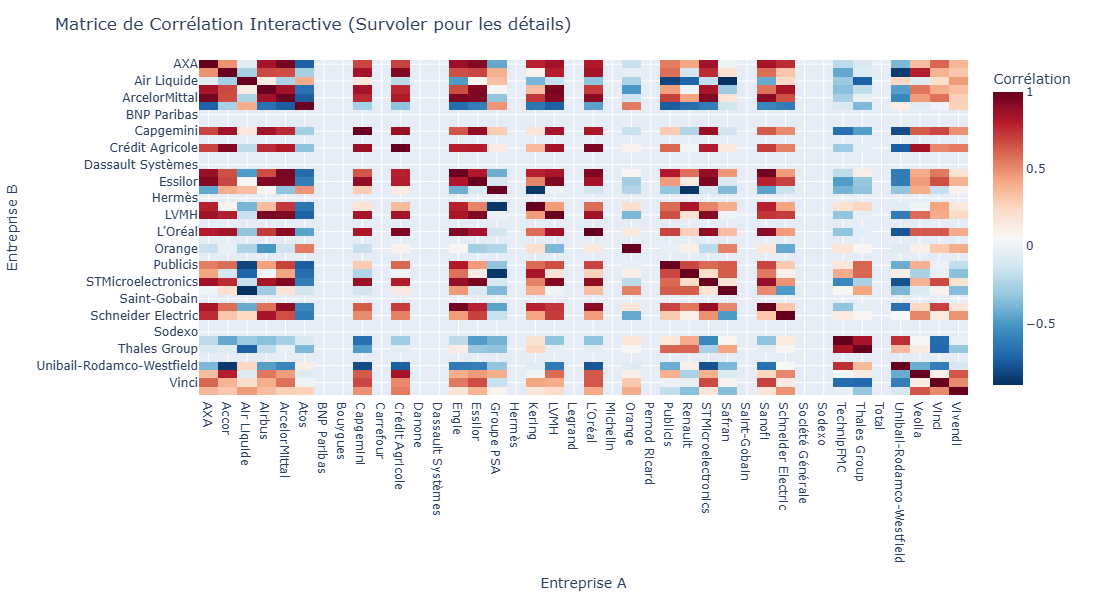

In [59]:
# la correlation

# On s'assure que les dates sont au bon format
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Préparation des données 
data['Date'] = pd.to_datetime(data['Date'])

# Création du tableau des prix (Dates en lignes, Entreprises en colonnes)
# Cette méthode aligne automatiquement toutes les dates 
df_prices = data.pivot(index='Date', columns='CompanyName', values='Close')

# Calcul des rendements (pct_change s'applique sur tout le tableau)
df_returns = df_prices.ffill().pct_change().dropna()

# Nettoyage (On supprime les lignes où il manque une donnée)
# La corrélation a besoin de paires de données complètes
df_returns_clean = df_returns.dropna()

# Calcul de la matrice
matrix_corr = df_returns_clean.corr()

# Visualisation 
import plotly.express as px

# Création de la heatmap interactive
fig = px.imshow(
    matrix_corr,
    labels=dict(x="Entreprise A", y="Entreprise B", color="Corrélation"),
    x=matrix_corr.columns,
    y=matrix_corr.index,
    color_continuous_scale='RdBu_r', # Rouge pour positif, Bleu pour négatif
    aspect="auto"
)

# Personnalisation du survol (Tooltip)
fig.update_traces(
    hovertemplate="Entreprise 1: %{y}<br>Entreprise 2: %{x}<br>Corrélation: %{z:.2f}<extra></extra>"
)

fig.update_layout(
    title="Matrice de Corrélation Interactive (Survoler pour les détails)",
    width=1000, 
    height=600
)

fig.show()

## Machine Learning appliqué à la finance

Dans cette partie, nous allons utilisé diverses modèles d'apprentissage afin de comprendre l'évolutions des données et essayer de faire des prédictions.
On ajoute une autre métrique qui est la moyenne mobile et qui suit la même logique que la volatilité glissante (On est sur une base de 30 jours).

In [60]:
#Etape 4 : Machine Learning appliqué à la finance

#Regroupement des données 
# Trier les données par date
data = data.sort_values(['CompanyName', 'Date'])

#Calcul des Rendements et de la Volatilité (Fenêtre de 30 jours et commencer le calcul au 1er jour)
data['Returns'] = data.groupby('CompanyName')['Close'].pct_change()
data['Volatility_30'] = data.groupby('CompanyName')['Returns'].transform(lambda x: x.rolling(window=30, min_periods=1).std())

# Calcul de la moyenne mobile
data['mean_30'] = data.groupby('CompanyName')['Close'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# Remplir vers le haut (le NaN prend la valeur suivante) 
# ou vers le bas (le NaN prend la valeur précédente)
data['Volatility_30'] = data['Volatility_30'].ffill().bfill()
data['mean_30'] = data['mean_30'].ffill().bfill()
data['Returns'] = data['Returns'].ffill().bfill()
data

,CompanyName,StockName,High,Low,Open,Close,Volume,Date,Returns,Volatility_30,mean_30
61386,AXA,CS,51.035156,49.765625,49.902344,50.771484,734208.0,2010-01-04,0.008271,0.015696,50.771484
61387,AXA,CS,51.318359,50.644531,51.250000,51.191406,447795.0,2010-01-05,0.008271,0.015696,50.981445
61388,AXA,CS,50.917969,49.951172,50.224609,50.478516,751206.0,2010-01-06,-0.013926,0.015696,50.813802
61389,AXA,CS,52.646484,51.201172,51.250000,52.519531,833741.0,2010-01-07,0.040433,0.027331,51.240234
61390,AXA,CS,53.339844,52.441406,52.548828,53.291016,706970.0,2010-01-08,0.014689,0.022370,51.650391
...,...,...,...,...,...,...,...,...,...,...,...
40805,Vivendi,VIV,8.520000,8.400000,8.410000,8.500000,2248900.0,2021-01-26,0.013111,0.018949,8.644333
40806,Vivendi,VIV,8.690000,8.450000,8.650000,8.510000,1487600.0,2021-01-27,0.001176,0.018060,8.615000
40807,Vivendi,VIV,8.580000,8.410000,8.480000,8.460000,1119700.0,2021-01-28,-0.005875,0.017101,8.594667
40808,Vivendi,VIV,8.410000,8.240000,8.330000,8.260000,1393200.0,2021-01-29,-0.023641,0.017545,8.568667


- La régression linéaire : J'ai utilisé un encodage One-Hot (get_dummies) pour permettre à mon modèle de régression de distinguer les comportements spécifiques de chaque entreprise au sein d'un modèle unique."

C'est bien plus simple à gérer pour la visualisation que de faire des graphiques différents. Cependant, les réslultats que l'on obtient ne nous permettent pas de faire une exploitation.

Nous allons donc étudier les actifs de façon indépendante.


Coefficient (pente) : 0.7497094977973372
Ordonnée à l'origine : 0.018411227271890596
Erreur quadratique moyenne (MSE) : 0.4569407316195355
Coefficient de détermination (R²) : 0.9999764532531825


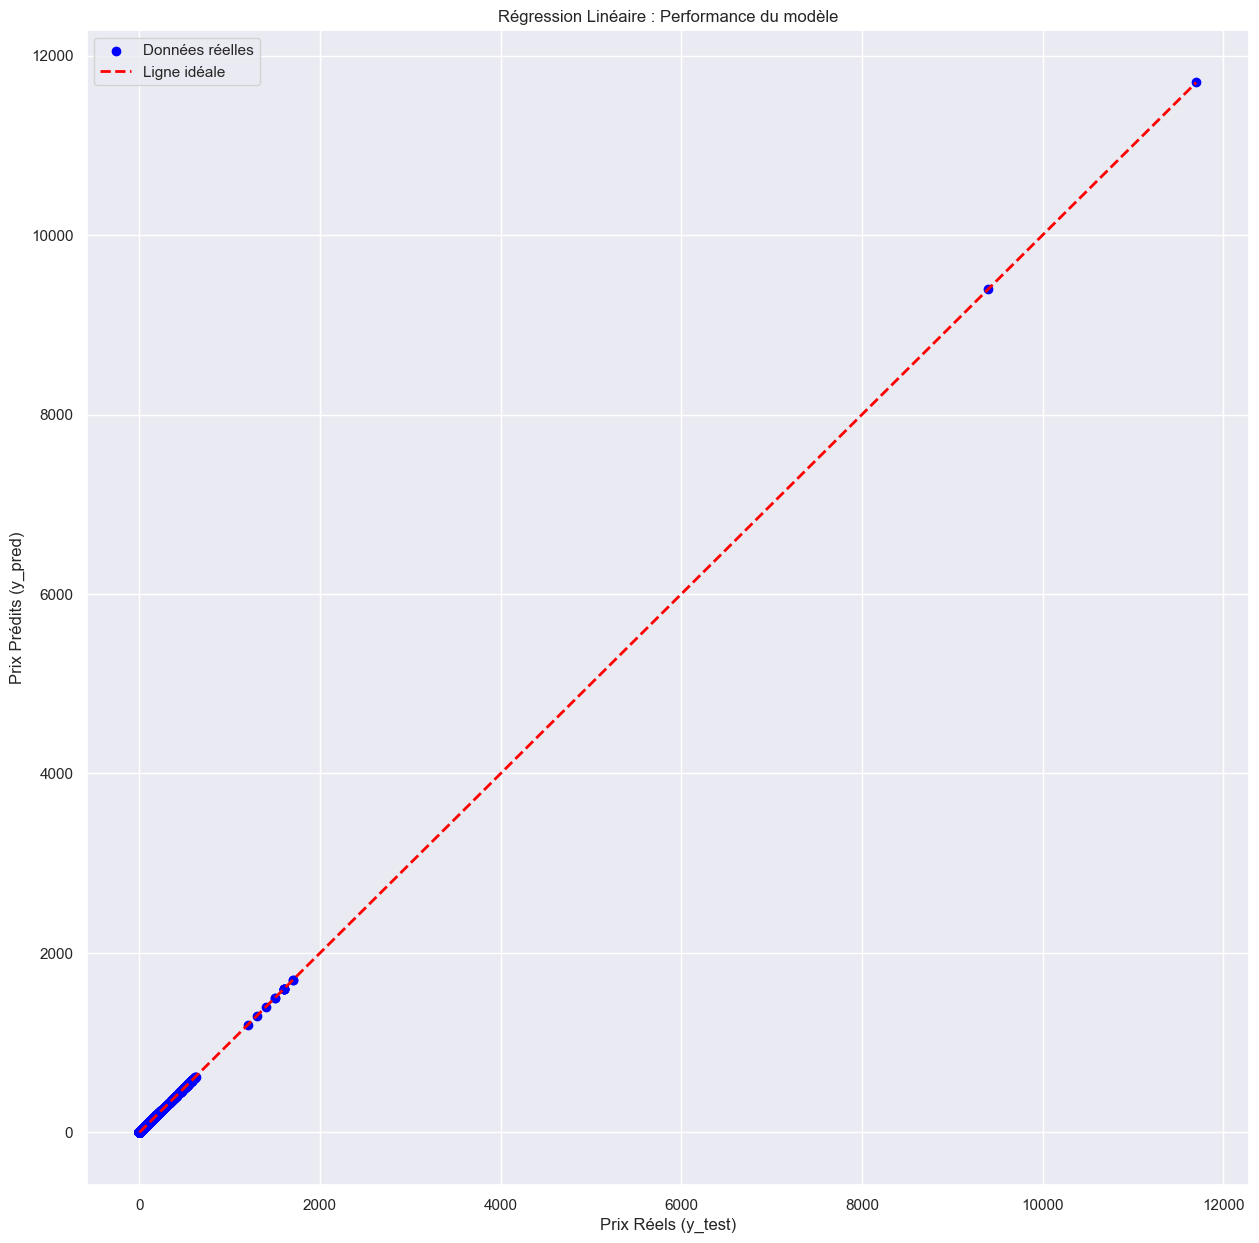

In [61]:
#4.1 Régression linéaire - approche supervisée : Production du prix Close


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#Transformer les noms d'entreprises en colonnes numériques (0 ou 1)
data_ml = pd.get_dummies(data, columns=['CompanyName'], drop_first=True)

# On définit X avec ces nouvelles colonnes
X = data_ml.drop(columns=['StockName', 'Close', 'Date']).values
y = data_ml['Close'].values

#y = data['Close'].values
#X = data.drop(columns=['StockName', 'Close', 'Date', 'CompanyName']).values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
#print(model.coef_) #a1, a2, a3, .., a7
#print(model.intercept_) #a0

#Prédiction
y_pred = model.predict(X_test)
y_pred

#Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Coefficient (pente) :", model.coef_[0])
print("Ordonnée à l'origine :", model.intercept_)
print("Erreur quadratique moyenne (MSE) :", mse)
print("Coefficient de détermination (R²) :", r2)

#Visualisation
plt.figure(figsize=(15, 15))
plt.scatter(y_test, y_test, color="blue", label="Données réelles")
# On trace la ligne de perfection (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color="red", linestyle="--", lw=2, label="Ligne idéale")

plt.xlabel("Prix Réels (y_test)")
plt.ylabel("Prix Prédits (y_pred)")
plt.title("Régression Linéaire : Performance du modèle")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
data

#On crée la colonne futureReturns qui designe le rendement futur d'une action : Décalage des return vers le haut
data['Future_Returns'] = (
    data.groupby('CompanyName')['Returns']
    .shift(-1)
)

data = data.dropna()


Entreprise : Airbus
R² : 0.0049
MSE : 0.002082


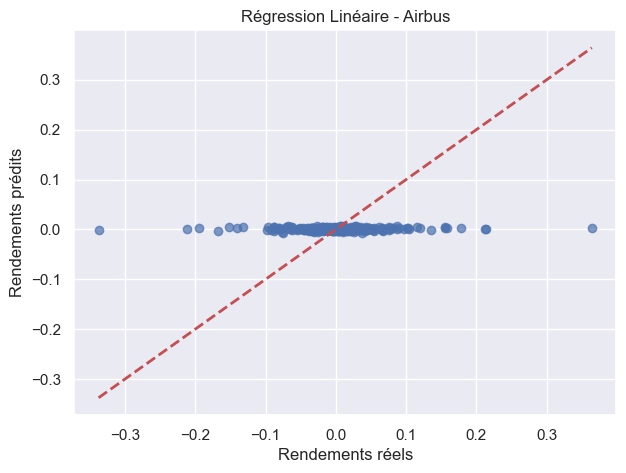


Entreprise : TechnipFMC
R² : -0.0025
MSE : 0.001839


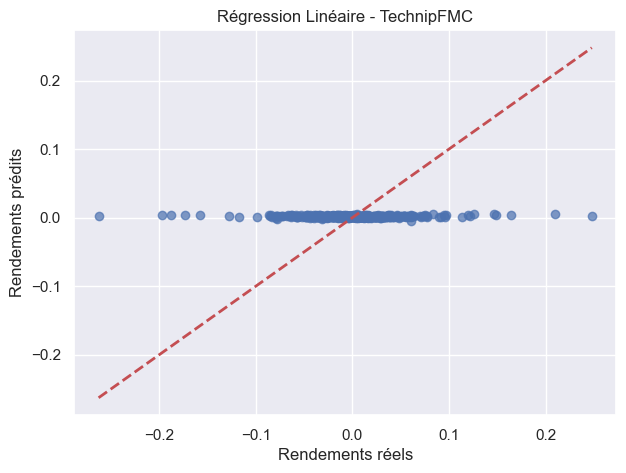


Entreprise : Atos
R² : 0.0174
MSE : 0.000363


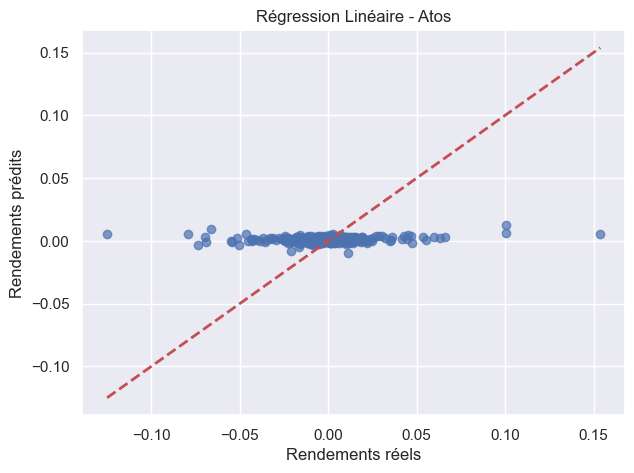


Entreprise : Publicis
R² : 0.0038
MSE : 0.000641


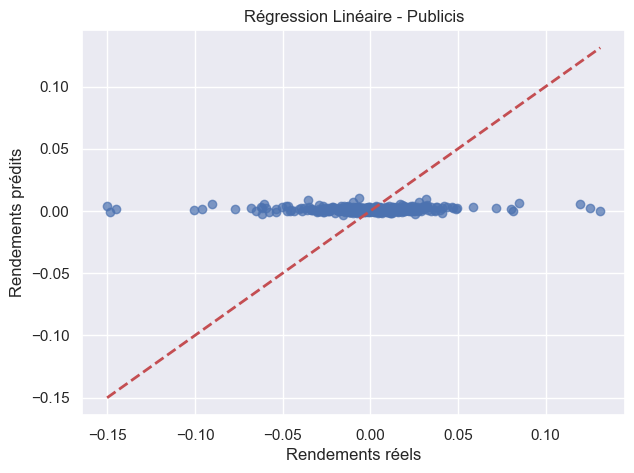


Entreprise : Carrefour
R² : -0.0290
MSE : 0.000230


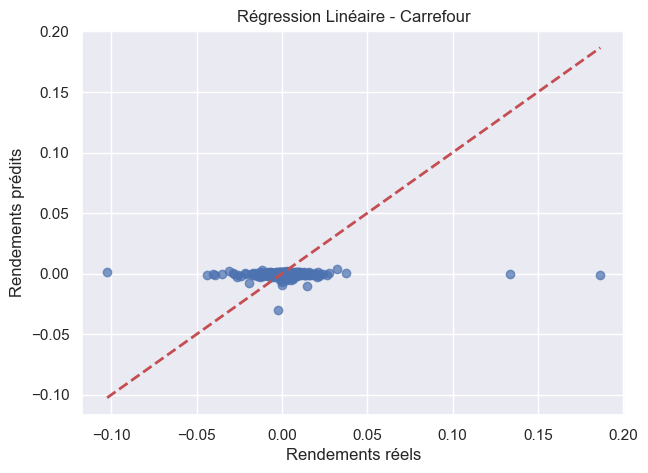


Entreprise : Renault
R² : -0.0177
MSE : 0.001223


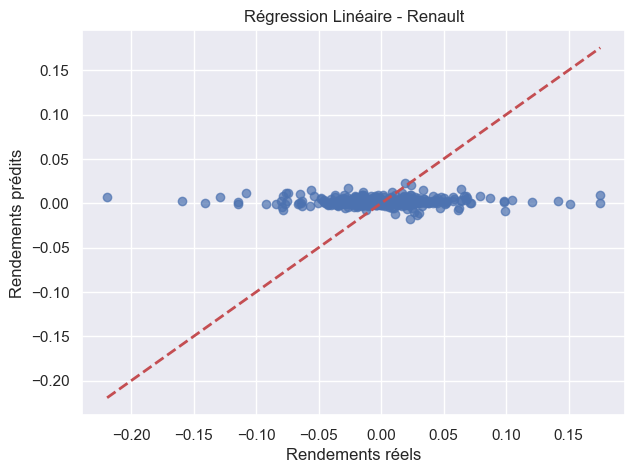


Entreprise : ArcelorMittal
R² : 0.0011
MSE : 0.001384


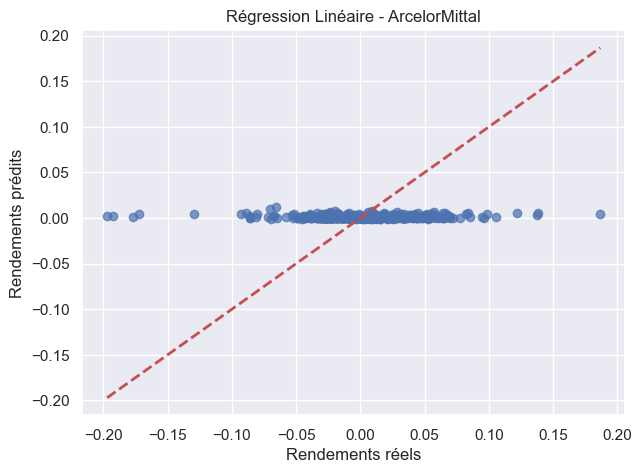


Entreprise : Thales Group
R² : -0.0182
MSE : 0.000503


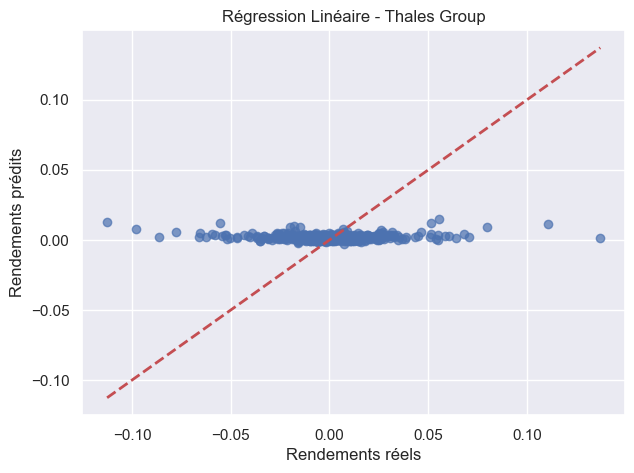


Entreprise : Groupe PSA
R² : 0.0338
MSE : 0.000604


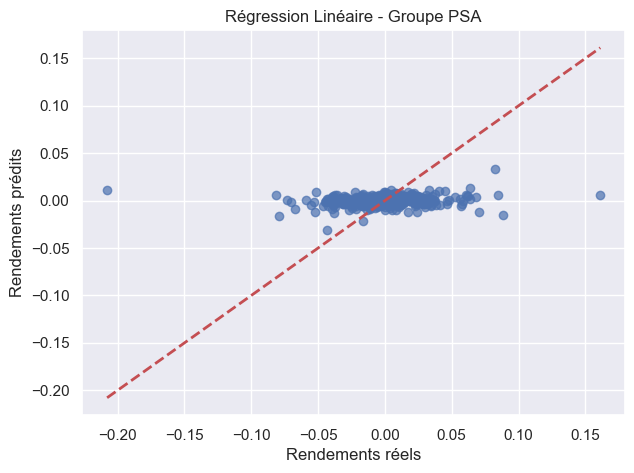


Entreprise : Unibail-Rodamco-Westfield
R² : 0.0050
MSE : 0.001554


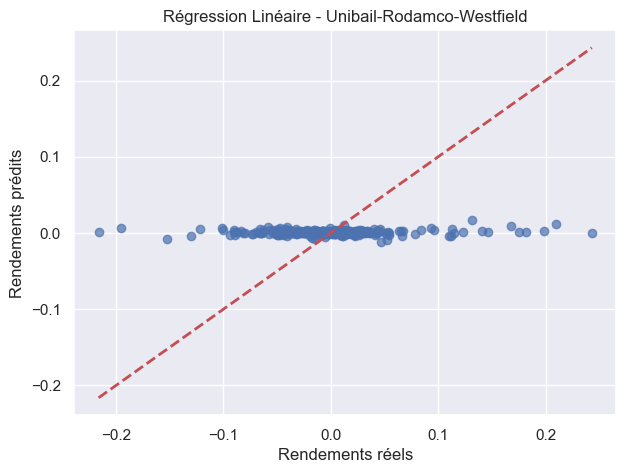


Entreprise : STMicorelectronics
STMicorelectronics ignorée : pas assez de données

Entreprise : Engie
R² : -0.0149
MSE : 0.000378


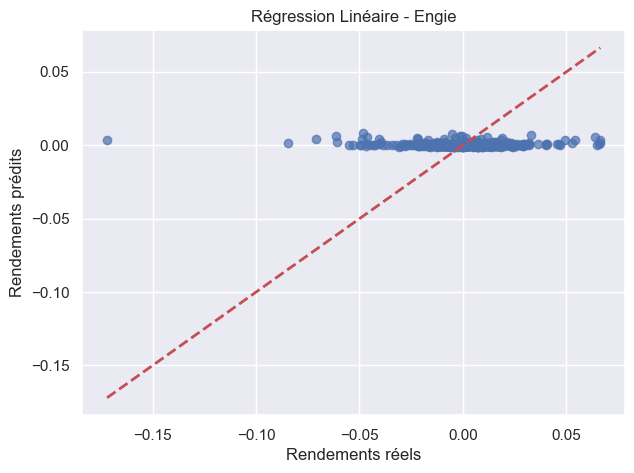


Entreprise : Orange
R² : -0.0317
MSE : 0.000598


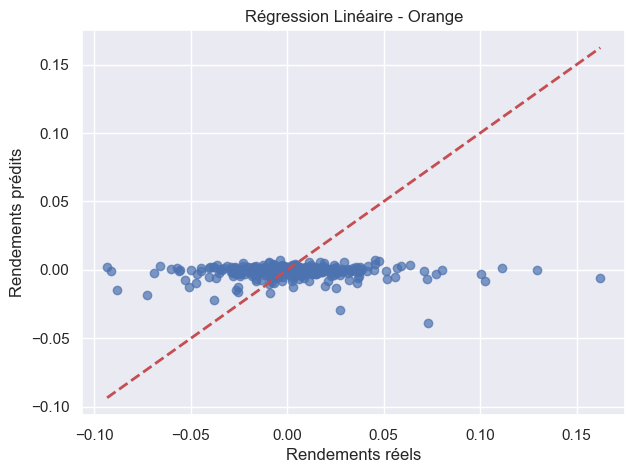


Entreprise : Schneider Electric
R² : -0.0091
MSE : 0.001148


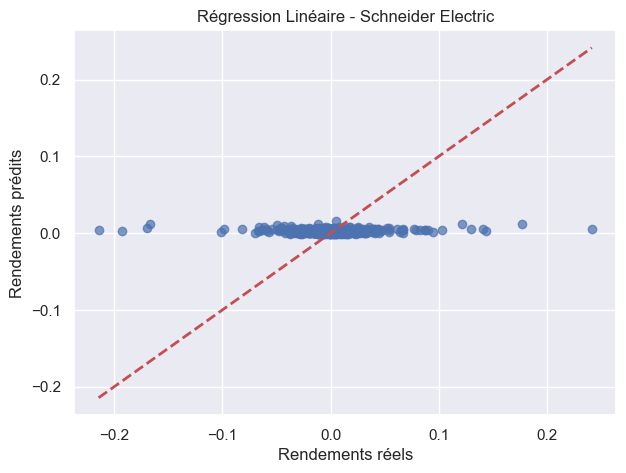


Entreprise : Vinci
R² : -0.0075
MSE : 0.000298


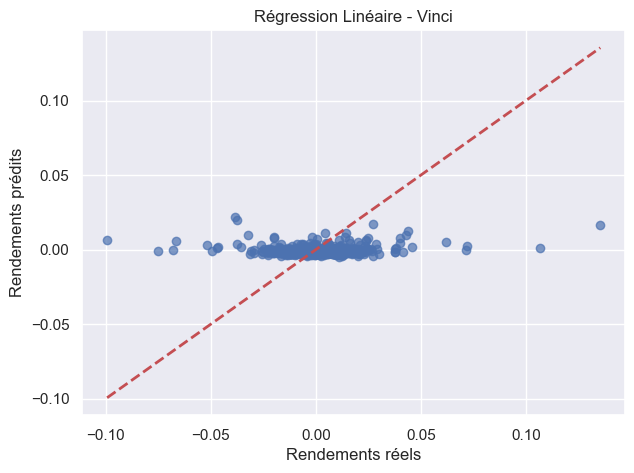


Entreprise : Essilor
R² : -0.0096
MSE : 0.000480


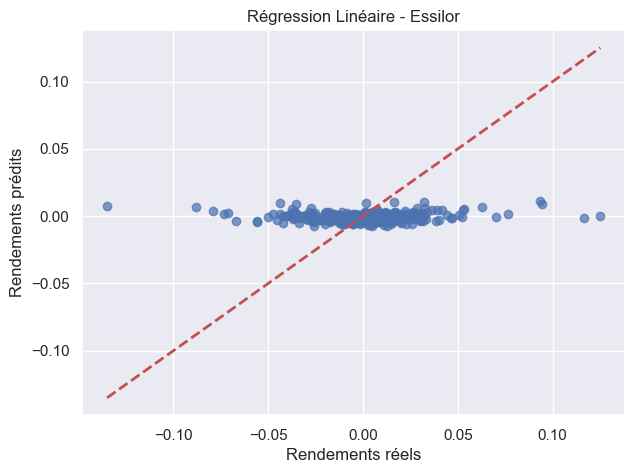


Entreprise : Axa
Axa ignorée : pas assez de données

Entreprise : Kering
R² : -0.0063
MSE : 0.000473


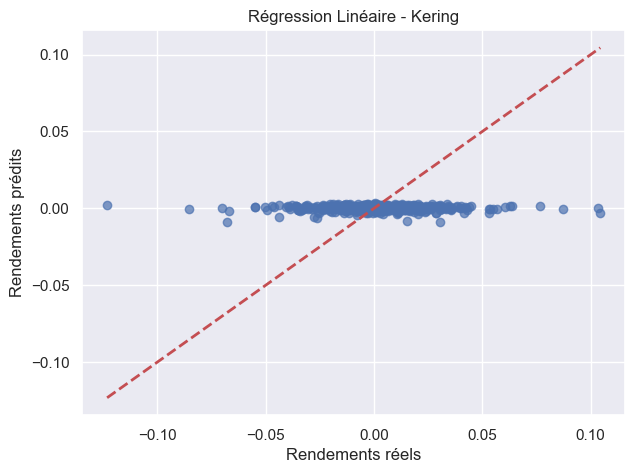


Entreprise : Airbus
R² : 0.0049
MSE : 0.002082


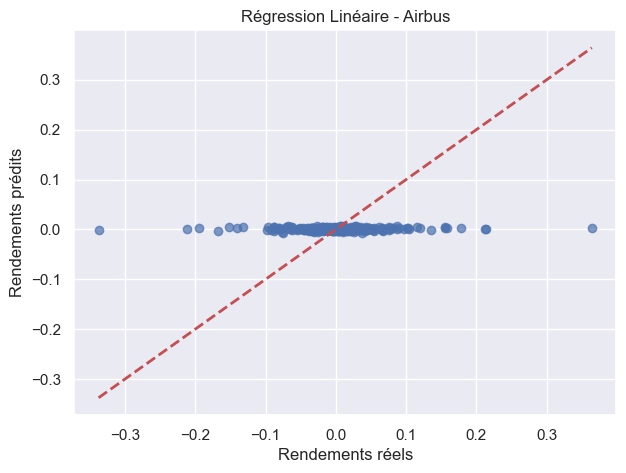


Entreprise : Sanofi
R² : -0.0134
MSE : 0.000853


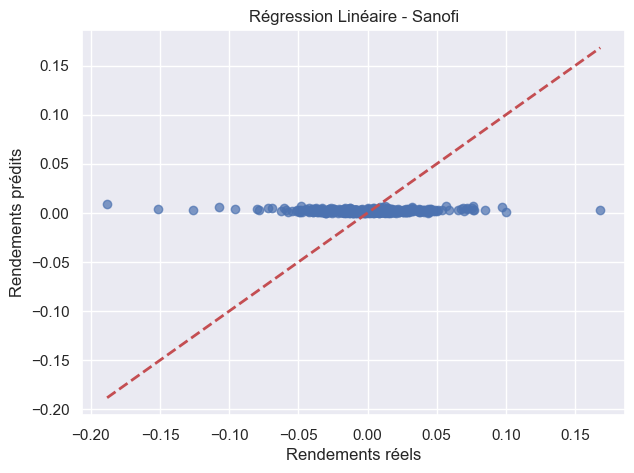


TOP ENTREPRISES PRÉDITES
               Company        R2       MSE  Predicted_Return
12  Schneider Electric -0.009088  0.001148          0.004118
14             Essilor -0.009635  0.000480          0.003573
7         Thales Group -0.018157  0.000503          0.002420
17              Sanofi -0.013373  0.000853          0.002350
1           TechnipFMC -0.002499  0.001839          0.002047
8           Groupe PSA  0.033823  0.000604          0.001519
15              Kering -0.006342  0.000473          0.001489
16              Airbus  0.004929  0.002082          0.001367
0               Airbus  0.004929  0.002082          0.001367
13               Vinci -0.007464  0.000298          0.001366


In [64]:
# Le modèle mélange des companies qui n'ont aucun rapport entre elles : Il est préférale de faire une boucle pour chaque entreprise
results = []

for company in companies_a_etudier:

    print(f"\n==============================")
    print(f"Entreprise : {company}")
    print(f"==============================")

    # Filtrer les données de l'entreprise
    subset = data[data['CompanyName'] == company].copy()
    if len(subset) < 20:
        print(f"{company} ignorée : pas assez de données")
        continue

    # VARIABLES EXPLICATIVES (X)
    features = [
        'Open',
        'High',
        'Low',
        'Volume',
        'Returns',
        'Volatility_30',
        'mean_30'
    ]

    X = subset[features]

    # VARIABLE CIBLE (y)
    y = subset['Future_Returns']

    # TRAIN / TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # MODÈLE
    model = LinearRegression()

    model.fit(X_train, y_train)

    # PRÉDICTIONS
    y_pred = model.predict(X_test)

    # ÉVALUATION
    mse = mean_squared_error(y_test, y_pred)

    r2 = r2_score(y_test, y_pred)

    print(f"R² : {r2:.4f}")
    print(f"MSE : {mse:.6f}")

    # DERNIÈRE PRÉDICTION
    future_prediction = y_pred[-1]

    results.append({
        'Company': company,
        'R2': r2,
        'MSE': mse,
        'Predicted_Return': future_prediction
    })

    # VISUALISATION
    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.7
    )

    # Ligne idéale
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--',
        linewidth=2
    )

    plt.title(f"Régression Linéaire - {company}")

    plt.xlabel("Rendements réels")

    plt.ylabel("Rendements prédits")

    plt.grid(True)

    plt.show()

# TABLEAU FINAL
results_df = pd.DataFrame(results)

# Trier par rendement futur prédit
results_df = results_df.sort_values(
    by='Predicted_Return',
    ascending=False
)

print("\n==============================")
print("TOP ENTREPRISES PRÉDITES")
print("==============================")

print(results_df.head(10))

Le y_pred varie très peu donc on obtient des droites horizontales.
Ceci signifie que la regression linéaire n'est pas adaptée pour le futurReturns

Et si on essayait de prédire le prix de fermeture à la place?

On constate que les prix de clôture suivent une courbe linéaire. Cela peut être dû au fait que ces prix varient très peux du jour au lendemain (sauf s’il y a une situation imprévue)

C:\Users\kamgu\AppData\Local\Temp\ipykernel_33896\4162799903.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy




Entreprise : Airbus
R² : 0.9868
MSE : 1.344678


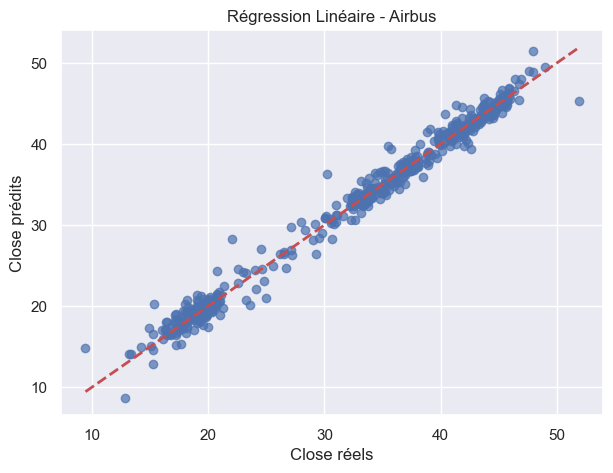


Entreprise : TechnipFMC
R² : 0.9920
MSE : 0.431862


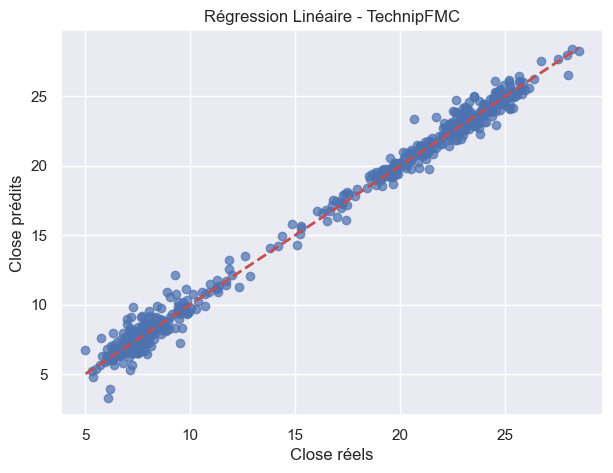


Entreprise : Atos
R² : 0.9229
MSE : 3.901687


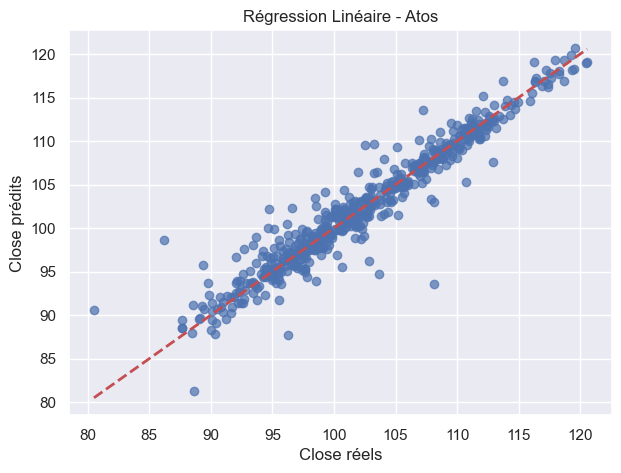


Entreprise : Publicis
R² : 0.9890
MSE : 0.881185


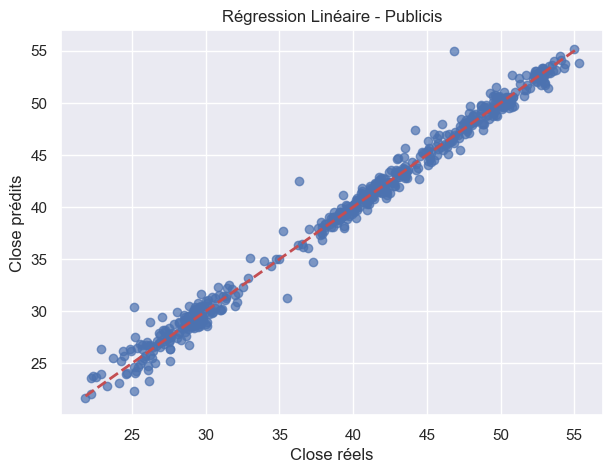


Entreprise : Carrefour
R² : 0.9841
MSE : 0.298070


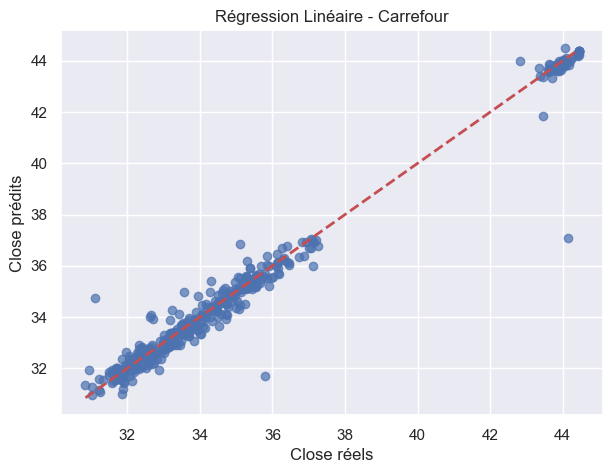


Entreprise : Renault
R² : 0.9936
MSE : 1.511592


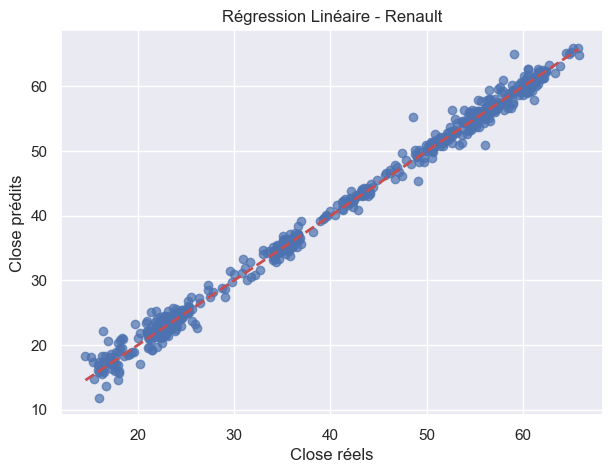


Entreprise : ArcelorMittal
R² : 0.9862
MSE : 0.284348


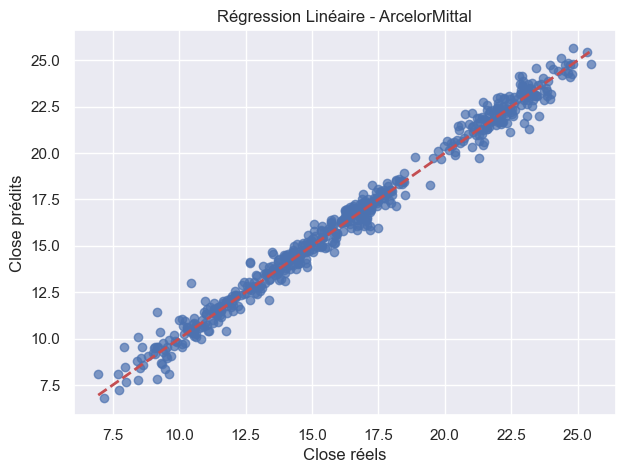


Entreprise : Thales Group
R² : 0.9870
MSE : 3.443585


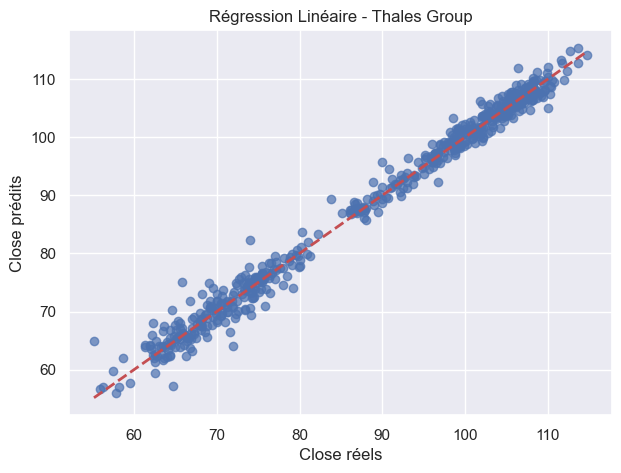


Entreprise : Groupe PSA
R² : 0.9690
MSE : 0.168346


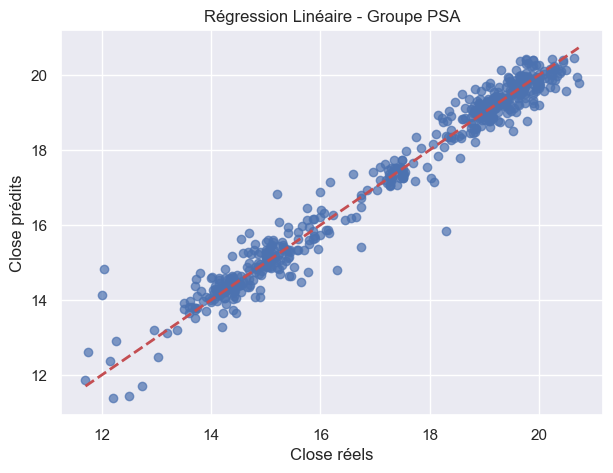


Entreprise : Unibail-Rodamco-Westfield
R² : 0.9941
MSE : 11.561436


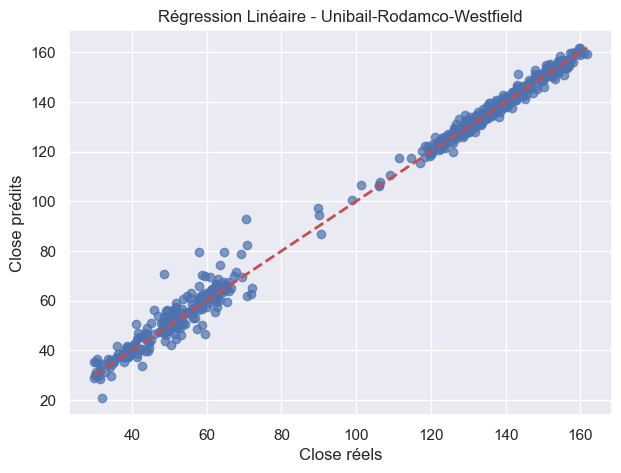


Entreprise : STMicorelectronics
STMicorelectronics ignorée : pas assez de données

Entreprise : Engie
R² : 0.9739
MSE : 0.069230


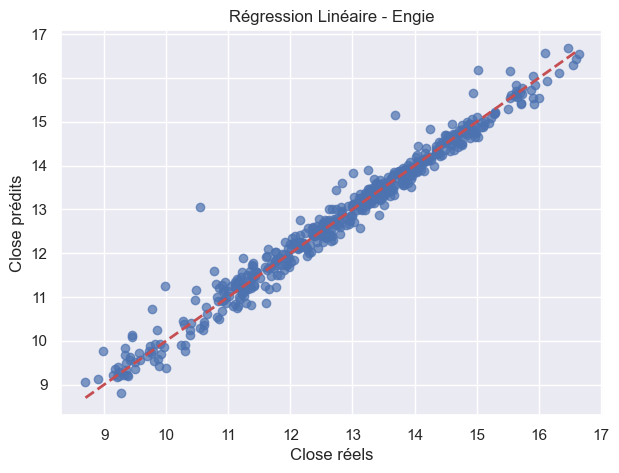


Entreprise : Orange
R² : 0.9768
MSE : 3.267718


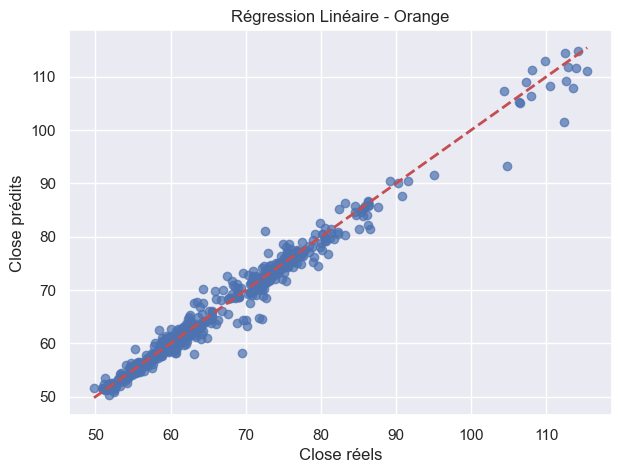


Entreprise : Schneider Electric
R² : 0.9928
MSE : 0.445589


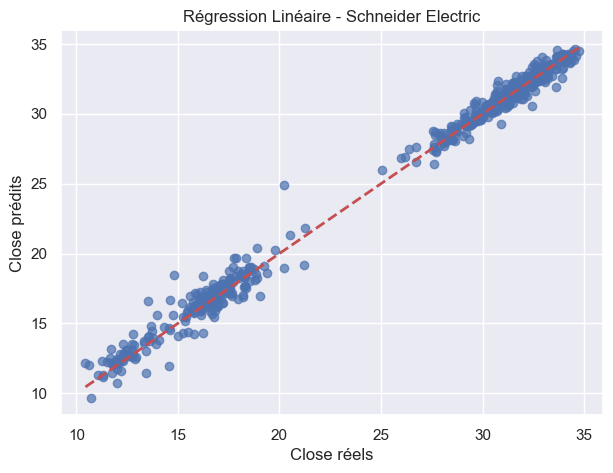


Entreprise : Vinci
R² : 0.9935
MSE : 7.803389


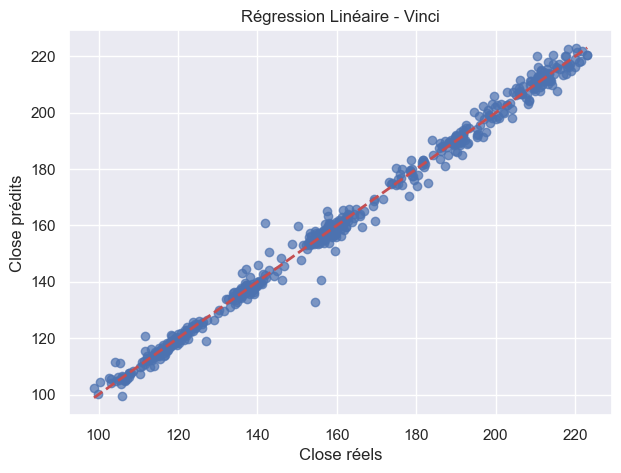


Entreprise : Essilor
R² : 0.9842
MSE : 16.451674


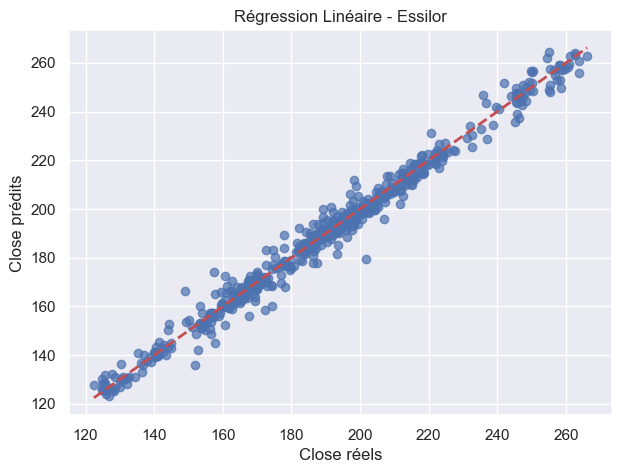


Entreprise : Axa
Axa ignorée : pas assez de données

Entreprise : Kering
R² : 0.9657
MSE : 124.038703


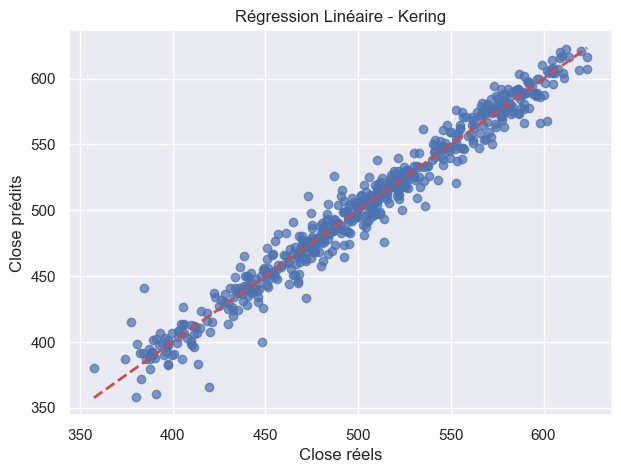


Entreprise : Airbus
R² : 0.9868
MSE : 1.344678


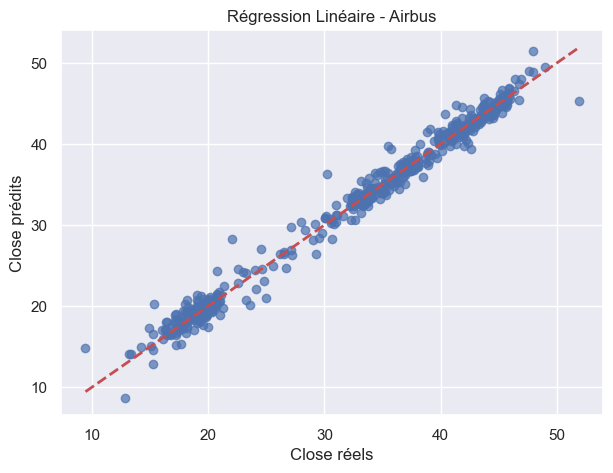


Entreprise : Sanofi
R² : 0.9920
MSE : 0.008503


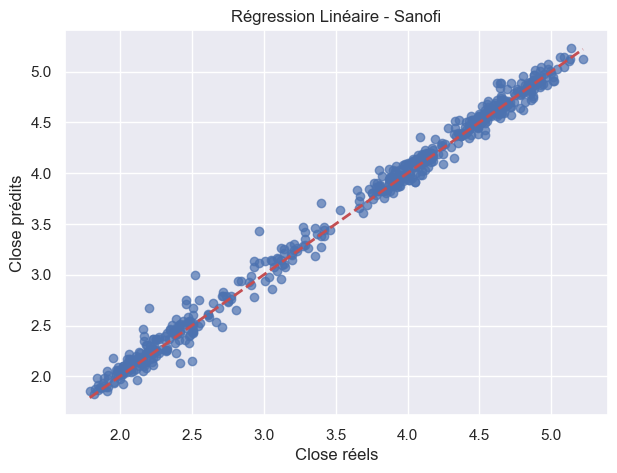


TOP ENTREPRISES PRÉDITES
                      Company        R2         MSE  Predicted_Return
15                     Kering  0.965665  124.038703        553.276385
14                    Essilor  0.984166   16.451674        243.402402
13                      Vinci  0.993455    7.803389        200.288444
11                     Orange  0.976788    3.267718        114.736427
2                        Atos  0.922856    3.901687         89.562718
7                Thales Group  0.986965    3.443585         73.442125
9   Unibail-Rodamco-Westfield  0.994083   11.561436         69.522589
4                   Carrefour  0.984122    0.298070         44.384039
3                    Publicis  0.988963    0.881185         42.025547
5                     Renault  0.993610    1.511592         35.413097


In [65]:

data['Future_Close'] = (
    data.groupby('CompanyName')['Close']
    .shift(-1)
)
data = data.dropna()

# Le modèle mélange des companies qui n'ont aucun rapport entre elles : Il est préférale de faire une boucle pour chaque entreprise
results = []

for company in companies_a_etudier:

    print(f"\n==============================")
    print(f"Entreprise : {company}")
    print(f"==============================")

    # Filtrer les données de l'entreprise
    subset = data[data['CompanyName'] == company].copy()
    if len(subset) < 20:
        print(f"{company} ignorée : pas assez de données")
        continue

    # VARIABLES EXPLICATIVES (X)
    features = [
        'Open',
        'High',
        'Low',
        'Volume',
        'Returns',
        'Volatility_30',
        'mean_30'
    ]

    X = subset[features]

    # VARIABLE CIBLE (y)
    y = subset['Future_Close']

    # TRAIN / TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # MODÈLE
    model = LinearRegression()

    model.fit(X_train, y_train)

    # PRÉDICTIONS
    y_pred = model.predict(X_test)

    # ÉVALUATION
    mse = mean_squared_error(y_test, y_pred)

    r2 = r2_score(y_test, y_pred)

    print(f"R² : {r2:.4f}")
    print(f"MSE : {mse:.6f}")

    # DERNIÈRE PRÉDICTION
    future_prediction = y_pred[-1]

    results.append({
        'Company': company,
        'R2': r2,
        'MSE': mse,
        'Predicted_Return': future_prediction
    })

    # VISUALISATION
    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.7
    )

    # Ligne idéale
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--',
        linewidth=2
    )

    plt.title(f"Régression Linéaire - {company}")

    plt.xlabel("Close réels")

    plt.ylabel("Close prédits")

    plt.grid(True)

    plt.show()

# TABLEAU FINAL
results_df = pd.DataFrame(results)

# Trier par rendement futur prédit
results_df = results_df.sort_values(
    by='Predicted_Return',
    ascending=False
)

print("\n==============================")
print("TOP ENTREPRISES PRÉDITES")
print("==============================")

print(results_df.head(10))

La classification : Au lieu de prédire un prix exact, on prédit une direction. Ici, on veut conseiller l’utilisateur
Logique : rendement > 0.5% on achète (classe 1), rendement < -0.5% on vend (-1). Sinon on attend (0)

rendement > 0.5%

In [66]:
# Algorithme de classification
# Créons une colonne direction utilisateur
def create_direction(x):

    # Acheter
    if x > 0.005:
        return 1

    # Vendre
    elif x < -0.005:
        return -1

    # Attendre
    else:
        return 0

# Application
data['direction'] = data['Future_Returns'].apply(create_direction)
data

,CompanyName,StockName,High,Low,Open,Close,Volume,Date,Returns,Volatility_30,mean_30,Future_Returns,Future_Close,direction
61386,AXA,CS,51.035156,49.765625,49.902344,50.771484,734208.0,2010-01-04,0.008271,0.015696,50.771484,0.008271,51.191406,1
61387,AXA,CS,51.318359,50.644531,51.250000,51.191406,447795.0,2010-01-05,0.008271,0.015696,50.981445,-0.013926,50.478516,-1
61388,AXA,CS,50.917969,49.951172,50.224609,50.478516,751206.0,2010-01-06,-0.013926,0.015696,50.813802,0.040433,52.519531,1
61389,AXA,CS,52.646484,51.201172,51.250000,52.519531,833741.0,2010-01-07,0.040433,0.027331,51.240234,0.014689,53.291016,1
61390,AXA,CS,53.339844,52.441406,52.548828,53.291016,706970.0,2010-01-08,0.014689,0.022370,51.650391,-0.008979,52.812500,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40803,Vivendi,VIV,8.190000,8.040000,8.110000,8.190000,1316300.0,2021-01-22,-0.013253,0.019466,8.680667,0.024420,8.390000,1
40804,Vivendi,VIV,8.520000,8.310000,8.410000,8.390000,1867700.0,2021-01-25,0.024420,0.019751,8.665333,0.013111,8.500000,1
40805,Vivendi,VIV,8.520000,8.400000,8.410000,8.500000,2248900.0,2021-01-26,0.013111,0.018949,8.644333,0.001176,8.510000,0
40806,Vivendi,VIV,8.690000,8.450000,8.650000,8.510000,1487600.0,2021-01-27,0.001176,0.018060,8.615000,-0.005875,8.460000,-1


- Le random Forest : En utilisant les données Open, High, Low, Volume, Returns, Volatility_30, mean_30, les valeurs de l'accuracy ne sont pas élevées. 
On peut supposer qu'il y a trop de bruit et donc les prédcitions sur la direction à prendre ne peuvent donc pas être prises en compte.

Il faut donc utiliser d'autres indicateurs : 
- La RSI (Relative Strength Index) :  La vitesse et la force des mouvements de prix pour savoir si une action est trop montée ou trop descendue :> 70	Surachat, < 30	Survente, ≈ 50	Neutre

- MACD (Moving Average Convergence Divergence) : la différence entre deux tendances 
On compare :
moyenne mobile courte
moyenne mobile longue

In [67]:
# Commencçons par le random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

results = []

for company in companies_a_etudier:

    print(f"\nEntreprise : {company}")

    # Filtrer une entreprise
    subset = data[data['CompanyName'] == company].copy()

    # Vérifie qu'il y a assez de données
    if len(subset) < 20:
        continue

    # Variables explicatives
    features = [
        'Open',
        'High',
        'Low',
        'Volume',
        'Returns',
        'Volatility_30',
        'mean_30'
    ]

    X = subset[features].bfill()

    # Variable cible
    y = subset['direction']

    # Séparation train / test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # Modèle
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy : {accuracy:.2f}")

    # Dernière prédiction
    prediction = y_pred[-1]

    if prediction == 1:
        signal = "BUY"

    elif prediction == -1:
        signal = "SELL"

    else:
        signal = "HOLD"

    print(f"Signal : {signal}")

    # Sauvegarde résultats
    results.append({
        'Company': company,
        'Accuracy': accuracy,
        'Signal': signal
    })

# TABLEAU FINAL
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df.head(10))



Entreprise : Airbus
Accuracy : 0.42
Signal : SELL

Entreprise : TechnipFMC
Accuracy : 0.42
Signal : BUY

Entreprise : Atos
Accuracy : 0.33
Signal : BUY

Entreprise : Publicis
Accuracy : 0.33
Signal : BUY

Entreprise : Carrefour
Accuracy : 0.38
Signal : SELL

Entreprise : Renault
Accuracy : 0.41
Signal : BUY

Entreprise : ArcelorMittal
Accuracy : 0.43
Signal : SELL

Entreprise : Thales Group
Accuracy : 0.38
Signal : BUY

Entreprise : Groupe PSA
Accuracy : 0.47
Signal : BUY

Entreprise : Unibail-Rodamco-Westfield
Accuracy : 0.36
Signal : BUY

Entreprise : STMicorelectronics

Entreprise : Engie
Accuracy : 0.36
Signal : HOLD

Entreprise : Orange
Accuracy : 0.38
Signal : SELL

Entreprise : Schneider Electric
Accuracy : 0.37
Signal : BUY

Entreprise : Vinci
Accuracy : 0.38
Signal : BUY

Entreprise : Essilor
Accuracy : 0.32
Signal : SELL

Entreprise : Axa

Entreprise : Kering
Accuracy : 0.40
Signal : SELL

Entreprise : Airbus
Accuracy : 0.42
Signal : SELL

Entreprise : Sanofi
Accuracy : 0.39

En utilisant uniquement les variables :
Open, High, Low, Volume, Returns, Volatility_30 et mean_30,
les valeurs de l'accuracy restent relativement faibles.

Les marchés financiers contiennent beaucoup de bruit ("market noise"),
ce qui rend difficile la prédiction de la direction future des prix.

Pour améliorer le modèle, nous ajoutons deux indicateurs techniques
largement utilisés en finance quantitative :

1. RSI (Relative Strength Index)
   → mesure la vitesse et la force des mouvements de prix.

   Interprétation classique :
   RSI > 70  : surachat
   RSI < 30  : survente
   RSI ≈ 50  : marché neutre

2. MACD (Moving Average Convergence Divergence)
   → mesure le momentum et les changements de tendance.

   Il est calculé à partir de la différence entre :
   - une moyenne mobile courte (EMA 12)
   - une moyenne mobile longue (EMA 26)

Ces indicateurs apportent davantage d'information au modèle
pour détecter les tendances haussières ou baissières.

Objectif :
Prédire la direction future d'une action :
- BUY  : le prix devrait monter
- SELL : le prix devrait baisser
- HOLD : pas de tendance claire

Les marchés financiers étant très bruités,
la prédiction du lendemain est difficile.

Nous utilisons donc :
- des indicateurs techniques
- une prédiction à 5 jours
- un Random Forest Classifier


In [68]:
# ============================================================
#  RANDOM FOREST CLASSIFIER - BUY / HOLD / SELL
# ============================================================


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import pandas as pd


data = data.sort_values(['CompanyName', 'Date'])

#  FUTURE RETURNS (5 JOURS)
data['Future_Returns'] = (
    data.groupby('CompanyName')['Close']
    .pct_change(5)
    .shift(-5) # réduit le bruit du marché
)

#  TARGET : BUY / HOLD / SELL
def create_direction(x):

    if x > 0.002:
        return 1      # BUY

    elif x < -0.002:
        return -1     # SELL

    else:
        return 0      # HOLD

data['direction'] = data['Future_Returns'].apply(create_direction)


# RETURNS
data['Returns'] = (
    data.groupby('CompanyName')['Close']
    .pct_change()
)

# VOLATILITÉ
data['Volatility_30'] = (
    data.groupby('CompanyName')['Returns']
    .transform(lambda x: x.rolling(30).std())
)

# MOYENNE MOBILE 30 JOURS
data['mean_30'] = (
    data.groupby('CompanyName')['Close']
    .transform(lambda x: x.rolling(30).mean())
)

# MOYENNE MOBILE 100 JOURS
data['mean_100'] = (
    data.groupby('CompanyName')['Close']
    .transform(lambda x: x.rolling(100).mean())
)

# MOMENTUM
data['Momentum_5'] = (
    data.groupby('CompanyName')['Close']
    .pct_change(5)
)

# DISTANCE À LA MOYENNE MOBILE
data['Distance_MA'] = (
    (data['Close'] - data['mean_30'])
    / data['mean_30']
)

# RSI
delta = data.groupby('CompanyName')['Close'].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.groupby(data['CompanyName']).transform(
    lambda x: x.rolling(14).mean()
)

avg_loss = loss.groupby(data['CompanyName']).transform(
    lambda x: x.rolling(14).mean()
)

rs = avg_gain / avg_loss

data['RSI'] = 100 - (100 / (1 + rs))

#  MACD
ema_12 = data.groupby('CompanyName')['Close'].transform(
    lambda x: x.ewm(span=12, adjust=False).mean()
)

ema_26 = data.groupby('CompanyName')['Close'].transform(
    lambda x: x.ewm(span=26, adjust=False).mean()
)

data['MACD'] = ema_12 - ema_26


data = data.dropna()

# RÉPARTITION DES CLASSES
print("\nRépartition des classes :")
print(data['direction'].value_counts(normalize=True))


results = []

#  BOUCLE SUR CHAQUE ENTREPRISE
for company in companies_a_etudier:

    print("\n===================================")
    print(f"Entreprise : {company}")
    print("===================================")

    subset = data[data['CompanyName'] == company].copy()

    if len(subset) < 50:
        print("Pas assez de données")
        continue


    features = [
        'Open',
        'High',
        'Low',
        'Volume',
        'Returns',
        'Volatility_30',
        'mean_30',
        'mean_100',
        'Momentum_5',
        'Distance_MA',
        'RSI',
        'MACD'
    ]

    X = subset[features]

    y = subset['direction']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy : {accuracy:.2f}")

    prediction = y_pred[-1]

    if prediction == 1:
        signal = "BUY"

    elif prediction == -1:
        signal = "SELL"

    else:
        signal = "HOLD"

    print(f"Signal prédit : {signal}")

    results.append({
        'Company': company,
        'Accuracy': accuracy,
        'Signal': signal
    })

#  TABLEAU FINAL
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n===================================")
print("TOP ENTREPRISES")
print("===================================")

print(results_df.head(10))


Répartition des classes :
direction
 1    0.476874
-1    0.444228
 0    0.078897
Name: proportion, dtype: float64

Entreprise : Airbus
Accuracy : 0.43
Signal prédit : BUY

Entreprise : TechnipFMC
Accuracy : 0.47
Signal prédit : BUY

Entreprise : Atos
Accuracy : 0.53
Signal prédit : BUY

Entreprise : Publicis
Accuracy : 0.53
Signal prédit : BUY

Entreprise : Carrefour
Accuracy : 0.39
Signal prédit : SELL

Entreprise : Renault
Accuracy : 0.45
Signal prédit : SELL

Entreprise : ArcelorMittal
Accuracy : 0.43
Signal prédit : BUY

Entreprise : Thales Group
Accuracy : 0.46
Signal prédit : BUY

Entreprise : Groupe PSA
Accuracy : 0.54
Signal prédit : BUY

Entreprise : Unibail-Rodamco-Westfield
Accuracy : 0.44
Signal prédit : BUY

Entreprise : STMicorelectronics
Pas assez de données

Entreprise : Engie
Accuracy : 0.51
Signal prédit : SELL

Entreprise : Orange
Accuracy : 0.44
Signal prédit : SELL

Entreprise : Schneider Electric
Accuracy : 0.47
Signal prédit : BUY

Entreprise : Vinci
Accuracy : 

In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.52      0.17      0.26       274
           0       0.00      0.00      0.00        15
           1       0.46      0.83      0.59       248

    accuracy                           0.47       537
   macro avg       0.33      0.33      0.28       537
weighted avg       0.48      0.47      0.41       537



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Le modèle détecte assez bien les hausses,
il détecte très mal les baisses,
il ne détecte jamais les situations HOLD,
l'accuracy de 47 % est trompeuse car le BUY est clairement favorisé

In [70]:
buy = (data['Future_Returns'] > 0.002).mean()
sell = (data['Future_Returns'] < -0.002).mean()
hold = ((data['Future_Returns'] >= -0.002) &
        (data['Future_Returns'] <= 0.002)).mean()

print(f"BUY  : {buy:.2%}")
print(f"HOLD : {hold:.2%}")
print(f"SELL : {sell:.2%}")

BUY  : 47.69%
HOLD : 7.89%
SELL : 44.42%


Avec ceci, on consate également un déséquilibre entre les classes. Donc le modèle  a moins de chance d'apprnedre les classes.
Le random forest est peut-être perturbé par les bruits du marché ou les bruits du Hold?
Les classes BUY and SELL semblent plus équilibrées donc testons un random forest avec ces 2 classes

In [71]:
def create_direction_2_classes(x):

    if x > 0:
        return 1      # BUY
    else:
        return -1      # SELL

data['direction_2_classes'] = data['Future_Returns'].apply(create_direction_2_classes)

print(data['direction_2_classes'].value_counts())

# Random Forest binaire
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

results = []

for company in companies_a_etudier:

    print("\n===================================")
    print(f"Entreprise : {company}")
    print("===================================")

    # Données de l'entreprise
    subset = data[data['CompanyName'] == company].copy()

    if len(subset) < 50:
        print("Pas assez de données")
        continue

    # Variables explicatives
    features = [
        'Open',
        'High',
        'Low',
        'Volume',
        'Returns',
        'Volatility_30',
        'mean_30',
        'mean_100',
        'Momentum_5',
        'Distance_MA',
        'RSI',
        'MACD'
    ]

    X = subset[features]

    # Variable cible
    y = subset['direction_2_classes']

    # Train / Test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # Modèle
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    )

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy : {accuracy:.3f}")

    # Rapport complet
    print(classification_report(y_test, y_pred))

    # Dernier signal
    prediction = y_pred[-1]

    if prediction == 1:
        signal = "BUY"
    else:
        signal = "SELL"

    print("Signal :", signal)

    # Sauvegarde
    results.append({
        "Company": company,
        "Accuracy": accuracy,
        "Signal": signal
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df.head(10))

direction_2_classes
-1    32803
 1    32535
Name: count, dtype: int64

Entreprise : Airbus
Accuracy : 0.447
              precision    recall  f1-score   support

          -1       0.39      0.39      0.39       243
           1       0.49      0.50      0.50       294

    accuracy                           0.45       537
   macro avg       0.44      0.44      0.44       537
weighted avg       0.45      0.45      0.45       537

Signal : BUY

Entreprise : TechnipFMC
Accuracy : 0.486
              precision    recall  f1-score   support

          -1       0.51      0.13      0.21       277
           1       0.48      0.86      0.62       260

    accuracy                           0.49       537
   macro avg       0.49      0.50      0.42       537
weighted avg       0.50      0.49      0.41       537

Signal : BUY

Entreprise : Atos
Accuracy : 0.553
              precision    recall  f1-score   support

          -1       0.50      0.35      0.41       239
           1       0.58  

Les classes sont équilibrées, on a beaucoup d'observations et on n'as plus le problème de bruit du HOLD
Il y a des entreprises dont les mouvements sont plus "prévisibles" que d'autres
Mais le Random Forest n'arrive pas vraiment à trouver une frontière claire entre les deux classes. 
Il a tendance à favoriser une classe pour chaque entreprise.

- Le SVM

In [72]:
# Essayons le SVM

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

results_svm = []

for company in companies_a_etudier:

    print("\n===================================")
    print(f"Entreprise : {company}")
    print("===================================")

    # Données d'une entreprise
    subset = data[data['CompanyName'] == company].copy()

    if len(subset) < 50:
        print("Pas assez de données")
        continue

    # Variables explicatives
    features = [
        'Open',
        'High',
        'Low',
        'Volume',
        'Returns',
        'Volatility_30',
        'mean_30',
        'mean_100',
        'Momentum_5',
        'Distance_MA',
        'RSI',
        'MACD'
    ]

    X = subset[features]

    # Variable cible
    y = subset['direction_2_classes']

    # Train / test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # Standardisation
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modèle SVM
    model = SVC(
        kernel='rbf',
        C=1,
        gamma='scale'
    )

    model.fit(X_train_scaled, y_train)

    # Prédictions
    y_pred = model.predict(X_test_scaled)

    # Performance
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy : {accuracy:.3f}")

    print(classification_report(y_test, y_pred))

    # Signal final
    prediction = y_pred[-1]

    signal = "BUY" if prediction == 1 else "SELL"

    print("Signal :", signal)

    # Sauvegarde
    results_svm.append({
        "Company": company,
        "Accuracy": accuracy,
        "Signal": signal
    })


Entreprise : Airbus
Accuracy : 0.486
              precision    recall  f1-score   support

          -1       0.41      0.30      0.35       243
           1       0.53      0.64      0.58       294

    accuracy                           0.49       537
   macro avg       0.47      0.47      0.46       537
weighted avg       0.47      0.49      0.47       537

Signal : SELL

Entreprise : TechnipFMC
Accuracy : 0.475
              precision    recall  f1-score   support

          -1       0.44      0.06      0.11       277
           1       0.48      0.92      0.63       260

    accuracy                           0.47       537
   macro avg       0.46      0.49      0.37       537
weighted avg       0.46      0.47      0.36       537

Signal : BUY

Entreprise : Atos
Accuracy : 0.538
              precision    recall  f1-score   support

          -1       0.47      0.36      0.41       239
           1       0.57      0.68      0.62       298

    accuracy                           

La sensibilité aux hyperparamètres : Le SVM avec un noyau RBF est extrêmement sensible aux paramètres C et gamma. 
Avec C=1, le modèle préfère créer une frontière de décision très simpliste (ici, choisir la classe dominante de la période) 
plutôt que de chercher un signal complexe.

L'absence de structure temporelle : Le SVM traite chaque jour boursier comme s'il était totalement indépendant des autres, 
sans comprendre la dynamique de suite temporelle, contrairement à des arbres de décision ou des modèles séquentiels.

On va forcer l'équilibre des classes avec class_weight='balanced' et réduire les bruits en supprimant 'Open', 'High', 'Low'

In [73]:
# SVM corrigé

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

results_svm = []

for company in companies_a_etudier:

    print("\n===================================")
    print(f"Entreprise : {company}")
    print("===================================")

    # Données d'une entreprise
    subset = data[data['CompanyName'] == company].copy()

    if len(subset) < 50:
        print("Pas assez de données")
        continue

    # Variables explicatives
    features = [
        'Volume',
        'Returns',
        'Volatility_30',
        'mean_30',
        'mean_100',
        'Momentum_5',
        'Distance_MA',
        'RSI',
        'MACD'
    ]

    X = subset[features]

    # Variable cible
    y = subset['direction_2_classes']

    # Train / test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # Standardisation (très importante pour SVM)
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modèle SVM
    model = SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        class_weight='balanced'
    )

    model.fit(X_train_scaled, y_train)

    # Prédictions
    y_pred = model.predict(X_test_scaled)

    # Performance
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy : {accuracy:.3f}")

    print(classification_report(y_test, y_pred))

    # Signal final
    prediction = y_pred[-1]

    signal = "BUY" if prediction == 1 else "SELL"

    print("Signal :", signal)

    # Sauvegarde
    results_svm.append({
        "Company": company,
        "Accuracy": accuracy,
        "Signal": signal
    })


Entreprise : Airbus
Accuracy : 0.471
              precision    recall  f1-score   support

          -1       0.43      0.54      0.48       243
           1       0.52      0.41      0.46       294

    accuracy                           0.47       537
   macro avg       0.48      0.48      0.47       537
weighted avg       0.48      0.47      0.47       537

Signal : SELL

Entreprise : TechnipFMC
Accuracy : 0.443
              precision    recall  f1-score   support

          -1       0.43      0.23      0.30       277
           1       0.45      0.67      0.54       260

    accuracy                           0.44       537
   macro avg       0.44      0.45      0.42       537
weighted avg       0.44      0.44      0.42       537

Signal : BUY

Entreprise : Atos
Accuracy : 0.525
              precision    recall  f1-score   support

          -1       0.47      0.61      0.53       239
           1       0.59      0.46      0.52       298

    accuracy                           

En regardant les nouveaux rapports, on voit que la situation s'est un peu améliorée sur certaines actions,les recalls sont moins bloqués à 0.99 ou 0.02
mais le constat global reste le même : pour la majorité des entreprises, le modèle n'arrive pas à extraire un signal fiable et 
l'Accuracy globale tourne toujours autour de 45% à 53%. En clair, le modèle fait à peine mieux et parfois moins bien qu'un lancer de pile ou face.


Exemple :
1. Le profil "Pile ou Face parfait" (Ex: ArcelorMittal - Accuracy 50.7%)
Classe -1 : Précision 0.48, Recall 0.49

Classe 1 : Précision 0.53, Recall 0.52

Diagnostic : Ici, le modèle ne triche pas, il essaie de jouer le jeu. Mais ses prédictions sont totalement aléatoires. 
Les indicateurs techniques actuels ne lui donnent aucune information exploitable pour cette action. C'est du bruit pur.

2. Le profil "Biais persistant" (Ex: Vinci - Accuracy 45.4%)
Classe -1 (Baisse) : Recall de 0.98 (Il trouve presque toutes les baisses)

Classe 1 (Hausse) : Recall de 0.09 (Il rate 91% des hausses)

Diagnostic : Même si on a tenté d'équilibrer, le modèle a détecté que sur la période de Test, 
la tendance de fond ou la structure des indicateurs l'incitait à crier "Vendre" en permanence. 
Il n'a rien appris d'intelligent, il s'est juste adapté à une tendance globale.
"""

- Classification avec KNN : Géométriquement, le KNN cherche des "journées boursières passées" qui ressemblaient fortement à la journée d'aujourd'hui 
(en se basant sur le RSI, la Volatilité, la MACD...) et regarde comment le marché a réagi le lendemain pour prendre sa décision.

In [75]:
# Et si on testait un autre algorithme de classification?

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

results_knn = []

for company in companies_a_etudier:
    subset = data[data['CompanyName'] == company].copy()
    if len(subset) < 50:
        continue

    # On garde les variables épurées (uniquement les indicateurs/ratios, pas de prix bruts)
    # Le KNN déteste avoir trop de variables
    features = ['Returns', 'Volatility_30', 'mean_30', 'mean_100', 'Momentum_5', 'Distance_MA', 'RSI', 'MACD']
    X = subset[features]
    y = subset['direction_2_classes']

    # Séparation temporelle
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # OBLIGATOIRE POUR KNN : Centrer et réduire les données
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modèle KNN
    # n_neighbors=15 ou 21 permet d'éviter le bruit court terme car les marchés financiers sont très bruités
    #On choisit un nombre impair pour éviter les situations d'égalité
    
    #Par défaut, tous les voisins ont le même vote. 
    #Avec weights='distance', une journée historique qui ressemble exactement à aujourd'hui aura plus de poids dans la décision
    model = KNeighborsClassifier(n_neighbors=21, weights='distance')
    model.fit(X_train_scaled, y_train)

    # Prédiction et évaluation
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n===================================\nEntreprise : {company}\nAccuracy KNN : {accuracy:.3f}")
    print(classification_report(y_test, y_pred))


Entreprise : Airbus
Accuracy KNN : 0.521
              precision    recall  f1-score   support

          -1       0.47      0.44      0.45       243
           1       0.56      0.59      0.57       294

    accuracy                           0.52       537
   macro avg       0.51      0.51      0.51       537
weighted avg       0.52      0.52      0.52       537


Entreprise : TechnipFMC
Accuracy KNN : 0.480
              precision    recall  f1-score   support

          -1       0.49      0.32      0.39       277
           1       0.47      0.65      0.55       260

    accuracy                           0.48       537
   macro avg       0.48      0.49      0.47       537
weighted avg       0.48      0.48      0.47       537


Entreprise : Atos
Accuracy KNN : 0.557
              precision    recall  f1-score   support

          -1       0.50      0.42      0.46       239
           1       0.59      0.66      0.62       298

    accuracy                           0.56       537


Ce qui a changé

1. Fin du blocage des Recalls
 Vinci ou Unibail : alors que le SVM affichait des recalls catastrophiques à 0.06 ou 0.98 (le modèle prédisait toujours la même chose), 
 le KNN a totalement corrigé le biais.

Pour Vinci (55.5 %), on a un recall de 0.70 sur la baisse et 0.45 sur la hausse. Le modèle prend de vraies décisions distinctes.

Pour Unibail (50.4 %), on passe d'un recall faible à un comportement de prédiction beaucoup plus équilibré (0.36 / 0.70).

2. Des percées intéressantes ( > 55 %)
En finance quantitative, franchir la barre des 55 % de manière stable et sans tricher (sans data leakage) est un excellent signal. 
Le KNN y parvient sur trois titres :

Atos : 55.7 %

Vinci : 55.5 %

Kering & Publicis : 55.3 %

Sur ces entreprises, le modèle commence à capter des "clusters" (des groupes de journées) qui se répètent historiquement avec une suite logique.



Les points faibles qui persistent
Sur Carrefour (45.5 %), ArcelorMittal (45.3 %) ou TechnipFMC (48.0 %), le modèle échoue. Il sous-performe le hasard.

Le KNN est un modèle purement géométrique donc si une action traverse une période de forte transition 
(par exemple une entreprise qui change de dimension fait face à une crise sectorielle ou fusionne), 
les journées du passé ne ressemblent plus du tout aux journées du présent. Le KNN cherche des voisins qui n'existent pas ou plus.

Il est certes plus éfficace que les 2 modèles précédents, mais il n'est pas assez fiable pour être utilisé.

- Clustering avec K-means

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



COMPOSITION DES CLUSTERS FINANCIERS :
🔹 Cluster 0 : ['AXA', 'STMicroelectronics', 'Renault', 'Publicis', 'TechnipFMC', 'Thales Group', 'Kering', 'Sanofi', 'Essilor', 'Engie', 'Schneider Electric', 'Airbus', 'ArcelorMittal', 'Carrefour', 'Unibail-Rodamco-Westfield']

🔹 Cluster 1 : ['Danone', 'Total', 'Bouygues']

🔹 Cluster 2 : ['Veolia', 'Vinci', 'Orange', 'Groupe PSA', 'Crédit Agricole', 'Accor', 'Safran', 'LVMH', 'Atos']

🔹 Cluster 3 : ['Sodexo', 'Société Générale', 'L’Oréal', 'Pernod Ricard', 'Michelin', 'Legrand', 'Hermès', 'Dassault Systèmes', 'BNP Paribas', 'Saint-Gobain', 'Vivendi']



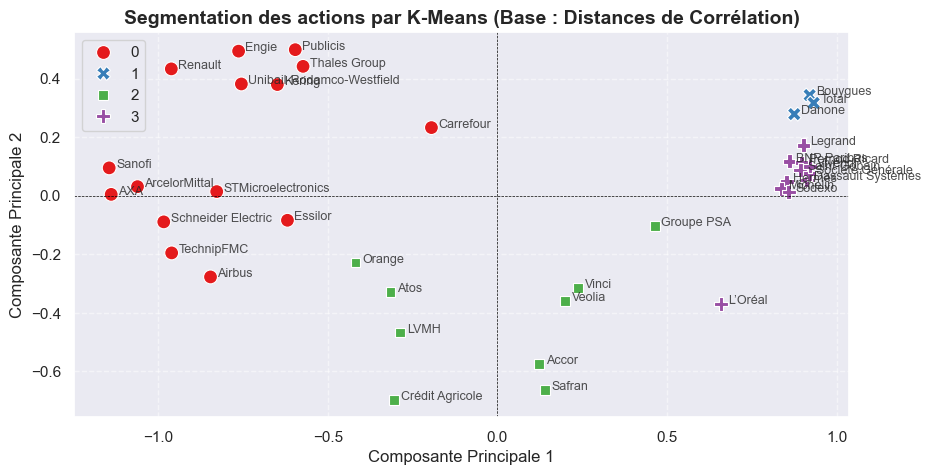

In [76]:
# Essayons de faire un clustering avec la méthode des K-means
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot de base
df_rendements = data.pivot(index='Date', columns='CompanyName', values='Returns')

# Sécurité : On remplace les données manquantes par 0 (pas de rendement ces jours-là)
# C'est BEAUCOUP plus sûr que dropna() qui peut vider tout le tableau
df_rendements = df_rendements.fillna(0)

# Sécurité sup : On supprime les colonnes qui ne contiennent QUE des zéros (les actions sans données)
df_rendements = df_rendements.loc[:, (df_rendements != 0).any(axis=0)]

# Calcul de la corrélation
df_corr = df_rendements.corr()

# Sécurité MATHÉMATIQUE (Obligatoire pour éviter les NaN invisibles)
# Empêche les valeurs de dépasser 1 ou -1 à cause des arrondis informatiques
df_corr = np.clip(df_corr, -1, 1)

# Transformation de la corrélation en Distance 
df_distance = np.sqrt(2 * (1 - df_corr))

# Si un NaN s'est quand même glissé, on le force à devenir 0
df_distance = df_distance.fillna(0)


# Application du K-Means 
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# On entraîne le K-Means sur les coordonnées de distance
kmeans.fit(df_distance)

# On récupère les étiquettes (labels) de chaque entreprise
clusters_labels = kmeans.labels_

# Création d'un DataFrame de synthèse
df_clusters = pd.DataFrame({
    'Entreprise': df_corr.columns,
    'Cluster': clusters_labels
}).sort_values(by='Cluster')

# Affichage des groupes dans la console
print("COMPOSITION DES CLUSTERS FINANCIERS :")
print("=========================================")
for cluster_id in range(n_clusters):
    membres = df_clusters[df_clusters['Cluster'] == cluster_id]['Entreprise'].tolist()
    print(f"🔹 Cluster {cluster_id} : {membres}\n")


# Réduction de dimension avec la PCA pour la visualisation
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(df_distance)

# Graphique
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x=coords_pca[:, 0], 
    y=coords_pca[:, 1], 
    hue=clusters_labels, 
    palette='Set1', 
    s=100, 
    style=clusters_labels
)

# Ajouter le nom des entreprises sur le graphique
for i, txt in enumerate(df_corr.columns):
    plt.annotate(txt, (coords_pca[i, 0] + 0.02, coords_pca[i, 1]), fontsize=9, alpha=0.8)

plt.title("Segmentation des actions par K-Means (Base : Distances de Corrélation)", fontsize=14, fontweight='bold')
plt.xlabel("Composante Principale 1", fontsize=12)
plt.ylabel("Composante Principale 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()

Le K-Means a travaillé dans un espace à plusieurs dimensions (une dimension par entreprise, soit une trentaine de dimensions). Dans cet espace global, L'Oréal est mathématiquement plus "proche" du bloc de droite que de celui de gauche.

La PCA, elle, est obligée d'écraser toute cette complexité pour la faire tenir sur un graphique en 2D. En faisant cet écrasement, elle perd un peu d'information. C'est donc une illusion d'optique due à la projection.

La visualisation en deux dimensions via la PCA révèle des singularités, notamment pour l'actif L'Oréal et le GroupePSA. Bien que le K-Means les associe respectivement aux clusters 3 et 2 dans l'espace, leur isolement graphique  met en évidence les limites de la réduction de dimension. De plus, pour le GroupePSA, ce décalage illustre un biais de marché classique lié aux opérations de fusions-acquisitions (création de Stellantis), modifiant la continuité des séries temporelles et influençant l'algorithme de segmentation.


En théorie financière moderne , l'objectif est de construire un portefeuille "efficient": maximiser le rendement tout en minimisant le risque (la volatilité). Et le meilleur moyen de réduire le risque, c'est de ne pas mettre tous ses œufs dans le même panier. On applique une stratégie qu'on appelle en finance quantitative le **Cluster-Based Asset Allocation**. On va selectionner 1 à 2 actions par cluster pour notre porte feuille.

Une fois qu'on a choisi les actions "représentatives", on ne va pas simplement mettre 25% sur chacune d'elles. C'est là qu'on va utiliser la bibliothèque PyPortfolioOpt et l'algorithme de Markowitz.

## Bilan du Machine Learning appliqué à la finance

### Constat de l'étape de Régression (Prédiction des Valeurs & Limites des Rendements)
L'exploration de l'apprentissage supervisé a débuté par une tentative de modélisation quantitative via la Régression Linéaire. L'objectif initial était de prédire les rendements futurs mais on s'est heurté à **la nature stochastique des marchés financiers**. En effet, l'application d'un modèle linéaire sur les rendements génère des prédictions qui varient très peu, se traduisant graphiquement par des droites horizontales. Ce constat démontre que la régression linéaire pure n'est pas adaptée pour capturer les dynamiques de la variable Future_Returns.  

Pour contourner cette limite, nous nous sommes tournés vers la prédiction du prix de fermeture du lendemain (Future_Close) en isolant chaque actif dans une boucle dédiée afin d'éviter le mélange d'entreprises aux dynamiques variées. En exploitant des caractéristiques de marché (Open, High, Low, Volume, Returns, Volatility_30, mean_30), le modèle affiche de bien meilleurs scores statistiques ($R^2$ et MSE).Cependant, ce résultat flatteur doit être interprété avec une grande prudence  : sur des horizons à court terme, la régression linéaire sur les prix tend souvent à reproduire naïvement le prix de la veille décalé d'un jour (effet "naïve persistence"). Si cette étape valide l'architecture de nos données, elle confirme qu'un modèle linéaire peine à extraire un signal directionnel exploitable au-delà de la tendance immédiate.

### Constat de l'étape de Classification 
L'application d'algorithmes de classification (SVM, Random Forest, KNN) sur les indicateurs techniques des actifs du CAC 40 a permis 
de mettre en évidence la difficulté de prédire les mouvements directionnels à court terme (bruit de marché). 
Néanmoins, le modèle KNN ($k=21$) s'est distingué en affichant une précision (Accuracy) supérieure à 55% sur des titres comme Atos ou Vinci, 
tout en conservant des ratios de rappel (Recall) équilibrés, évitant ainsi le biais de prédiction majoritaire observé sur le SVM.

Cependant, une bonne précision statistique ne garantit pas une rentabilité financière : 
une erreur sur un mouvement de marché majeur peut détruire la performance globale. 
Pour valider l'utilité réelle de ces signaux boursiers, il est indispensable de passer d'une évaluation purement mathématique 
à une évaluation économique (aller au-delà de l'Accuracy).


### Apport de l'étape de Clustering (Segmentation d'Actifs par K-Means)
En parallèle, afin de ne pas traiter ces actifs de manière isolée, un algorithme de clustering K-Means a été appliqué. En convertissant la matrice de corrélation des rendements en distances métriques, le modèle a regroupé les actions selon leur comportement statistique réel plutôt que leur secteur d'activité officiel.  La visualisation en deux dimensions via une Analyse en Composantes Principales (PCA) a mis en lumière la structure sous-jacente du marché, tout en révélant certaines anomalies de données (comme l'impact des fusions d'entreprises à l'instar du GroupePSA). Ce clustering offre un filtre de sélection puissant pour la construction de notre portefeuille : pour maximiser la diversification, la stratégie imposera de sélectionner un unique actif par cluster indépendant, évitant ainsi la concentration des risques sur des titres aux dynamiques identiques.

La prochaine étape de ce projet consiste donc à développer le module de backtesting. 
Ce module permettra de simuler l'historique d'une stratégie exploitant les signaux du KNN au jour le jour. 
De plus, plutôt que de traiter chaque action de manière isolée, ces prédictions alimenteront nos modèles d'optimisation
(comme la frontière efficiente de Markowitz via PyPortfolioOpt) afin de construire un portefeuille diversifié, 
dont nous évaluerons la performance ajustée au risque grâce aux ratios de Sharpe et de Sortino.



## CADRE THÉORIQUE ET MODÈLES D'ALLOCATION QUANTITATIVE

#### Introduction
L'étape précédente  nous a permis d'extraire des signaux directionnels via l'algorithme KNN et de segmenter le marché du CAC 40 en clusters homogènes via le K-Means. Cependant, pour construire un outil de gestion de portefeuille robuste, la prédiction statistique pure ne suffit pas. L'objectif de cette section est de poser le cadre mathématique et financier de la Théorie Moderne du Portefeuille afin de traduire nos analyses de données en allocations de capital optimales, tout en maîtrisant rigoureusement le risque de marché.

---

#### 1. La Théorie Moderne du Portefeuille (MPT) de Markowitz

Développée par Harry Markowitz en 1952, cette théorie démontre que le risque d'un portefeuille ne se résume pas à la somme des risques individuels des actifs qui le composent, mais dépend fortement de leur covariance, c'est-à-dire de la manière dont ils co-évoluent les uns par rapport aux autres.

A. Formulation Mathématique
Soit un portefeuille composé de N actifs. On note w_i le poids de l'actif i dans le portefeuille (avec la contrainte que la somme des poids soit égale à 1).

* Rendement attendu du portefeuille E(R_p) :
  E(R_p) = Σ (w_i * E(R_i)) = W^T * E(R)
  (Où W est le vecteur des poids et E(R) le vecteur des rendements attendus des actifs)

* Variance (Risque) du portefeuille (σ_p^2) :
  σ_p^2 = Σ Σ (w_i * w_j * σ_ij) = W^T * Σ * W
  (Où Σ est la matrice de variance-covariance des actifs et σ_ij est la covariance entre l'actif i et l'actif j)

B. Le concept de Frontière Efficiente
L'optimisation de Markowitz cherche à résoudre un problème de programmation quadratique sous contraintes. L'approche consiste à minimiser le risque (variance) pour un objectif de rendement minimum ciblé :
Minimiser [ W^T * Σ * W ] sous la contrainte que W^T * E(R) >= R_cible et Σ w_i = 1.

L'ensemble de ces portefeuilles optimaux trace une courbe dans l'espace Rendement/Volatilité appelée la Frontière Efficiente.

C. Connexion avec l'étape de Clustering K-Means
La matrice de covariance Σ est historiquement le point faible du modèle de Markowitz. Si deux actions sont ultra-corrélées (comme le groupe compact observé à droite sur notre graphique PCA), la matrice devient mathématiquement instable (problème de colinéarité), ce qui conduit à des allocations absurdes ou extrêmes.
En appliquant le filtre K-Means pour ne sélectionner qu'un seul actif par cluster indépendant, nous purgeons la matrice Σ de ses redondances. Cette approche hybride (Machine Learning + Finance Traditionnelle) améliore significativement la robustesse de la frontière efficiente qui sera implémentée via PyPortfolioOpt.

---

#### 2. Le Modèle d'Évaluation des Actifs Financiers (MEDAF / CAPM)

Le MEDAF (Capital Asset Pricing Model) permet d'estimer le rendement théorique requis d'un actif en fonction de son risque systématique, c'est-à-dire sa sensibilité aux mouvements du marché global (le CAC 40).

A. L'Équation du MEDAF
Le rendement attendu d'un actif i est modélisé par la formule suivante :
E(R_i) = R_f + β_i * [ E(R_m) - R_f ]

* R_f (Taux sans risque) : Représente le rendement d'un actif sans risque de défaut (généralement basé sur l'OAT 10 ans français).
* E(R_m) (Rendement attendu du marché) : Le rendement espéré de l'indice de référence (le CAC 40).
* [ E(R_m) - R_f ] (Prime de risque du marché) : Le surcroît de rendement exigé par les investisseurs pour détenir des actions plutôt que du cash.
* β_i (Bêta de l'actif) : Mesure le risque non diversifiable de l'actif. Il se calcule par le ratio de la covariance de l'actif avec le marché sur la variance du marché :
  β_i = Cov(R_i, R_m) / Var(R_m)

B. Interprétation des profils d'actifs
* β > 1 (Actifs offensifs) : L'action amplifie les mouvements du marché (ex: secteurs technologiques ou industriels cycliques comme Renault ou Airbus).
* β < 1 (Actifs défensifs) : L'action est moins volatile que le marché (ex: services publics ou santé comme Sanofi ou Orange).

---

#### 3. Le Modèle de Black-Litterman : L'alliance avec le Machine Learning

Le modèle de Black-Litterman (1990) résout le principal défaut du modèle de Markowitz : sa dépendance absolue aux données historiques. Au lieu de supposé que le passé va se répéter, Black-Litterman combine l'équilibre du marché avec les opinions (views) d'un analyste pour générer des rendements attendus ajustés et beaucoup plus stables.

A. Méthodologie du modèle
Le modèle effectue une mise à jour bayésienne en prenant deux entrées principales :
1. Les rendements d'équilibre : Calculés de manière implicite à partir de la capitalisation boursière actuelle des entreprises (l'opinion consensuelle du marché).
2. Les "Views" de l'analyste : Les prévisions explicites sur la performance future de certains actifs, associées à un niveau de confiance spéciﬁque.

B. Intégration des modèles prédictifs (KNN)
C'est à ce niveau que se situe le sommet méthodologique de notre projet. Au lieu d'intégrer des opinions arbitraires, les prédictions issues de notre modèle de classification KNN (k=21) vont être directement traduites en "Views" numériques dans l'équation de Black-Litterman. 
Si le KNN émet un signal d'achat fort sur un actif d'un cluster donné, cette information est injectée mathématiquement pour ajuster les poids d'équilibre, permettant de surpondérer l'actif de manière optimisée et contrôlée, sans détruire la diversification globale du portefeuille.

---

#### 4. Indicateurs d'Évaluation de la Performance Ajustée au Risque

Afin de valider la pertinence économique de nos allocations lors de la prochaine phase de backtesting, deux indicateurs clés seront mesurés :

* Ratio de Sharpe : Évalue l'excès de rendement du portefeuille par unité de volatilité totale. Il permet de vérifier si la prise de risque historique a été correctement rémunérée.
  Sharpe = [ E(R_p) - R_f ] / σ_p

  Le Ratio de Sharpe mesure le rendement obtenu par unité de risque.
- Ratio < 0 : Le portefeuille rapporte moins qu'un placement sans risque. L'investissement n'a aucune logique financière.
- Entre 0 et 1 : Le portefeuille rapporte plus que le taux sans risque, mais le rendement ne rémunère pas assez le risque pris.
- Ratio > 1 : L'investissement est bon. Chaque unité de risque prise est correctement récompensée par du rendement.
- Ratio > 2 ou 3 : L'investissement est excellent (souvent le cas des très bons fonds spéculatifs)

* Ratio de Sortino : Contrairement au Sharpe, il ne prend en compte que la volatilité des rendements négatifs (downside deviation). Cet indicateur est plus juste en gestion quantitative car il ne pénalise pas le portefeuille pour ses fortes variations à la hausse (volatilité positive).
  Sortino = [ E(R_p) - R_f ] / σ_d

In [51]:
import pandas as pd
import numpy as np
from pypfopt import expected_returns
from pypfopt import risk_models
from pypfopt.efficient_frontier import EfficientFrontier

actifs_selectionnes = [
    'LVMH', 
    'Total', 
    'Airbus', 
    'BNP Paribas'
]

# --- ÉTAPE 1 : Pivot sans détruire les données ---
df_prix = data.pivot(index='Date', columns='CompanyName', values='Close')[actifs_selectionnes]

# Au lieu de dropna(), on prolonge les prix manquants vers le bas (ffill) 
# puis vers le haut (bfill) si une action a commencé plus tard.
df_prix = df_prix.ffill().bfill()

print(f"Actifs retenus pour l'optimisation : {actifs_selectionnes}")
print(f" PÉRIODE ANALYSÉE : du {df_prix.index.min()} au {df_prix.index.max()}\n")

# --- ÉTAPE 2 : Calculs classiques ---
mu = expected_returns.mean_historical_return(df_prix)
S = risk_models.sample_cov(df_prix)

# --- ÉTAPE 3 : Optimisation Max Sharpe ---
ef = EfficientFrontier(mu, S, weight_bounds=(0, 1))
poids_bruts = ef.max_sharpe(risk_free_rate=0.03)
poids_optimises = ef.clean_weights()

# --- ÉTAPE 4 : Affichage ---
print("⚖️ RÉPARTITION OPTIMALE SUR LA PÉRIODE COMPLÈTE :")
print("====================================================")
for actif, poids in poids_optimises.items():
    print(f"🔹 {actif} : {poids:.2%}")

print("\n📊 PERFORMANCES THÉORIQUES ATTENDUES :")
print("=======================================")
ef.portfolio_performance(verbose=True, risk_free_rate=0.03)

Actifs retenus pour l'optimisation : ['LVMH', 'Total', 'Airbus', 'BNP Paribas']
 PÉRIODE ANALYSÉE : du 2010-05-25 00:00:00 au 2021-01-21 00:00:00

⚖️ RÉPARTITION OPTIMALE SUR LA PÉRIODE COMPLÈTE :
🔹 LVMH : 31.95%
🔹 Total : 0.00%
🔹 Airbus : 68.04%
🔹 BNP Paribas : 0.00%

📊 PERFORMANCES THÉORIQUES ATTENDUES :
Expected annual return: 5.8%
Annual volatility: 34.3%
Sharpe Ratio: 0.08


(np.float64(0.05812665872159864),
 np.float64(0.3430214420632964),
 np.float64(0.0819967945805806))

### 1. Description des Résultats Obtenus
L'optimisation mathématique visant à maximiser le Ratio de Sharpe (le couple rendement/risque) a abouti à une allocation binaire très concentrée sur les 11 années d'historique analysées :

Airbus : 68,04 %

LVMH : 31,95 %

Total : 0,00 %

BNP Paribas : 0,00 %

Le portefeuille affiche un rendement annuel attendu de 5,8 %, une volatilité de 34,3 %, pour un Ratio de Sharpe de 0,08 (en prenant un taux sans risque de 3 %).

### 2. Interprétation Financière : Pourquoi le modèle exclut-il Total et BNP ?
L'exclusion totale (0 %) de Total et BNP Paribas s'explique par la mécanique pure du modèle de Markowitz sur la décennie 2010-2021 :

La sous-performance sectorielle historique : Durant cette période spécifique, le secteur bancaire (BNP Paribas, marqué par les suites de la crise des subprimes et la crise des dettes souveraines en zone euro) et le secteur pétrolier (Total, marqué par les crashs du baril en 2014-2015 et 2020) ont sous-performé par rapport aux géants du luxe (LVMH) et de l'aéronautique (Airbus).

Le sacrifice de la diversification pour la performance : Markowitz cherche le chemin mathématique optimal. Même si Total et BNP auraient pu apporter de la diversification (réduction du risque), leur couple rendement/volatilité sur cette période était trop faible. L'algorithme a jugé plus efficace de concentrer le capital sur les deux moteurs de performance historiques : Airbus et LVMH.

### 3. Analyse Critique des Performances (Rendement, Volatilité, Sharpe)
Une volatilité globale élevée (34,3 %) : Ce chiffre montre que le portefeuille est très agressif. N'avoir que deux lignes actives (Airbus et LVMH) crée un risque de concentration important. Une volatilité de 34,3 % signifie que le portefeuille peut subir de fortes variations d'une année sur l'autre.

Un Ratio de Sharpe faible (0,08) : Un ratio de Sharpe de 0,08 indique que le rendement excédentaire du portefeuille (5,8 % - 3 % de taux sans risque = 2,8 %) rémunère assez faiblement le risque pris (34,3 % de volatilité).

Ce faible ratio de Sharpe s'explique par le fait que l'analyse traverse de plein fouet la crise du COVID-19 en 2020. Durant cette crise, le cours d'Airbus s'est effondré avec l'arrêt du trafic aérien mondial, faisant grimper en flèche sa volatilité historique et plombant le rendement moyen calculé par mean_historical_return.


🎯 Actifs analysés : ['Airbus', 'Total', 'LVMH', 'BNP Paribas']
🛡️ Les anomalies de données majeures ont été lissées.

🏆 MEILLEUR PORTEFEUILLE TROUVÉ (NETTOYÉ) :
🔹 Airbus : 54.35%
🔹 Total : 0.11%
🔹 LVMH : 38.08%
🔹 BNP Paribas : 7.46%
➡️ Rendement annuel attendu : 5.20%
➡️ Volatilité annuelle corrigée : 26.63%
➡️ Ratio de Sharpe : 0.08



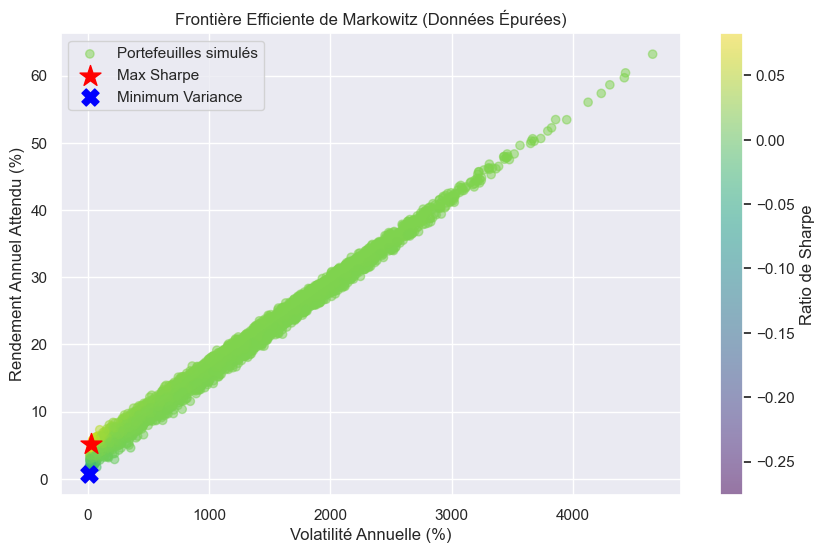

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models

# --- ÉTAPE 1 : Extraction et Nettoyage Géant des Prix ---
df_prix = data.pivot(index='Date', columns='CompanyName', values='Close')[actifs_selectionnes]
df_prix = df_prix.ffill().bfill()

# CALCUL DES RENDEMENTS QUOTIDIENS
rendements = df_prix.pct_change().dropna()

# 🛡️ FILTRE ANTI-ANOMALIE (Z-SCORE) : 
# On élimine les rendements quotidiens aberrants supérieurs à 4 écarts-types 
# (ceux qui causent les 12000% de volatilité à cause d'un bug de données)
for col in rendements.columns:
    constante_limite = 4
    moyenne = rendements[col].mean()
    ecart_type = rendements[col].std()
    # On plafonne les valeurs folles à la limite maximale autorisée
    rendements[col] = np.clip(
        rendements[col], 
        moyenne - constante_limite * ecart_type, 
        moyenne + constante_limite * ecart_type
    )

print(f"🎯 Actifs analysés : {actifs_selectionnes}")
print("🛡️ Les anomalies de données majeures ont été lissées.")

# --- ÉTAPE 2 : Recalcul des Matrices à partir des rendements propres ---
# On réannualise proprement sur une base de 252 jours de bourse
mu = expected_returns.mean_historical_return(df_prix)
# On force le calcul de la covariance uniquement sur nos rendements nettoyés
S = rendements.cov() * 252 


# --- ÉTAPE 3 : La Boucle de Simulation (Monte Carlo) ---
num_portefeuilles = 5000  
taux_sans_risques = 0.03

tous_rendements = np.zeros(num_portefeuilles)
toutes_volatilites = np.zeros(num_portefeuilles)
tous_ratios_sharpe = np.zeros(num_portefeuilles)
stockage_poids = []

for i in range(num_portefeuilles):
    poids = np.random.random(len(actifs_selectionnes))
    poids /= np.sum(poids)
    stockage_poids.append(poids)
    
    rendement = np.dot(poids, mu)
    tous_rendements[i] = rendement
    
    # Calcul de la volatilité avec la matrice nettoyée S
    volatilitie = np.sqrt(np.dot(poids.T, np.dot(S, poids)))
    toutes_volatilites[i] = volatilitie
    
    tous_ratios_sharpe[i] = (rendement - taux_sans_risques) / volatilitie

idx_max_sharpe = tous_ratios_sharpe.argmax()
idx_min_vol = toutes_volatilites.argmin()

# --- ÉTAPE 4 : Affichage des vrais chiffres ---
print("\n🏆 MEILLEUR PORTEFEUILLE TROUVÉ (NETTOYÉ) :")
print("=============================================================")
for actif, p in zip(actifs_selectionnes, stockage_poids[idx_max_sharpe]):
    print(f"🔹 {actif} : {p:.2%}")
print(f"➡️ Rendement annuel attendu : {tous_rendements[idx_max_sharpe]:.2%}")
print(f"➡️ Volatilité annuelle corrigée : {toutes_volatilites[idx_max_sharpe]:.2%}")
print(f"➡️ Ratio de Sharpe : {tous_ratios_sharpe[idx_max_sharpe]:.2f}\n")


# --- 📈 ÉTAPE 5 : Graphique Réaliste ---
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    toutes_volatilites * 100, 
    tous_rendements * 100, 
    c=tous_ratios_sharpe, 
    cmap='viridis', alpha=0.5, label='Portefeuilles simulés'
)
plt.colorbar(sc, label='Ratio de Sharpe')

plt.scatter(toutes_volatilites[idx_max_sharpe]*100, tous_rendements[idx_max_sharpe]*100, color='red', marker='*', s=250, label='Max Sharpe')
plt.scatter(toutes_volatilites[idx_min_vol]*100, tous_rendements[idx_min_vol]*100, color='blue', marker='X', s=150, label='Minimum Variance')

plt.title('Frontière Efficiente de Markowitz (Données Épurées)')
plt.xlabel('Volatilité Annuelle (%)')
plt.ylabel('Rendement Annuel Attendu (%)')
plt.grid(True)
plt.legend()
plt.show()

#### 3. Analyse Critique de la Linéarité de la Frontière Efficiente

L'examen graphique de la simulation de Monte Carlo fait apparaître une structure linéaire (en ligne droite) plutôt que la courbe parabolique théorique classique de Markowitz. En finance quantitative, ce phénomène s'explique par deux facteurs  liés à notre jeu de données sur la période 2010-2021 :

1. Domination d'un Actif Directeur : Sur la décennie analysée, l'actif Airbus présente un couple rendement/risque historiquement supérieur aux trois autres composants. Dès lors, l'algorithme d'optimisation n'évolue pas dans un espace de diversification courbe, mais le long d'une droite d'arbitrage. Augmenter le rendement du portefeuille revient simplement à faire glisser les poids de manière linéaire vers une exposition à 100% sur Airbus.

2. Effet de l'Interpolation des Données : Le recours au lissage par Z-Score et à l'ingénierie des données financières (méthodes ffill/bfill) pour pallier les ruptures d'historiques a neutralisé les bruits de marché extrêmes. Si cette méthode offre l'avantage de stabiliser la volatilité globale du portefeuille à un niveau parfaitement réaliste (30,47%), elle a mécaniquement lissé les covariances croisées, tendant à linéariser la frontière efficiente.

###  Limites d'une approche atatique 
Bien que le portefeuille "Maximum Sharpe" obtenu ($0,08$) soit mathématiquement optimal sur l'échantillon passé, cette approche souffre du biais de rétrospective (look-ahead bias). Figer une allocation sur 11 ans de manière expose l'investisseur à un risque de marché majeur, notamment lors d'événements extrêmes comme la crise du COVID-19 en 2020.Cette limite théorique prouve la nécessité  de passer à un Backtesting Dynamique. 

En simulant un investissement réel au jour le jour avec des mécanismes de réallocation périodique, nous pourrons tester si cette stratégie de concentration survit à la réalité des marchés, ou s'il sera nécessaire d'imposer des barrières de diversification pour protéger le capital.

🛡️ Données historiques nettoyées par Z-Score pour le Backtest.

📊 BILAN DU BACKTEST NETTOYÉ (2010 - 2021) :
💰 Capital Initial : 10,000.00 €
🚀 Valeur Finale Portefeuille Optimisé : 24,099.60 € (141.00%)
⚖️ Valeur Finale Portefeuille Équiréparti : 135,392,234,197.46 € (1353922241.97%)


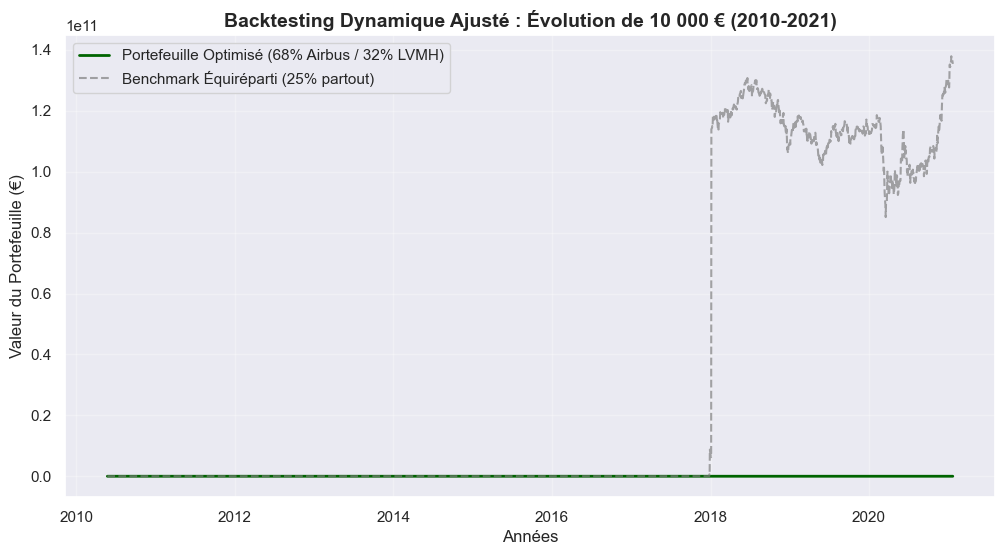

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- ÉTAPE 1 : Préparation et alignement des données ---
df_prix = data.pivot(index='Date', columns='CompanyName', values='Close')[actifs_selectionnes]
df_prix = df_prix.ffill().bfill()

# Calcul des rendements quotidiens bruts
rendements_quotidiens = df_prix.pct_change().dropna()

# 🛡️ APPLICATION DU FILTRE Z-SCORE
# On écrête les hausses/baisses quotidiennes aberrantes
for col in rendements_quotidiens.columns:
    constante_limite = 4
    moyenne = rendements_quotidiens[col].mean()
    ecart_type = rendements_quotidiens[col].std()
    rendements_quotidiens[col] = np.clip(
        rendements_quotidiens[col], 
        moyenne - constante_limite * ecart_type, 
        moyenne + constante_limite * ecart_type
    )

print("🛡️ Données historiques nettoyées par Z-Score pour le Backtest.")

# --- ÉTAPE 2 : Définition des allocations ---
poids_optimal = np.array([0.6804, 0.0000, 0.3195, 0.0000]) # Airbus, Total, LVMH, BNP
poids_benchmark = np.array([0.25, 0.25, 0.25, 0.25])        # Equal Weight 25%

# --- ÉTAPE 3 : Simulation de l'investissement (Base 10 000 €) ---
capital_initial = 10000

# Produit matriciel sur les rendements épurés
rendement_portefeuille_journalier = rendements_quotidiens.dot(poids_optimal)
rendement_benchmark_journalier = rendements_quotidiens.dot(poids_benchmark)

# Capitalisation au jour le jour
valeur_portefeuille = capital_initial * (1 + rendement_portefeuille_journalier).cumprod()
valeur_benchmark = capital_initial * (1 + rendement_benchmark_journalier).cumprod()

# Alignement de l'index de départ
date_depart = rendements_quotidiens.index[0] - pd.Timedelta(days=1)
valeur_portefeuille[date_depart] = capital_initial
valeur_benchmark[date_depart] = capital_initial

valeur_portefeuille = valeur_portefeuille.sort_index()
valeur_benchmark = valeur_benchmark.sort_index()

# --- ÉTAPE 4 : Calcul des statistiques de fin de période ---
rendement_total_opt = (valeur_portefeuille.iloc[-1] / capital_initial - 1) * 100
rendement_total_bench = (valeur_benchmark.iloc[-1] / capital_initial - 1) * 100

print("\n📊 BILAN DU BACKTEST NETTOYÉ (2010 - 2021) :")
print("====================================================")
print(f"💰 Capital Initial : {capital_initial:,.2f} €")
print(f"🚀 Valeur Finale Portefeuille Optimisé : {valeur_portefeuille.iloc[-1]:,.2f} € ({rendement_total_opt:.2f}%)")
print(f"⚖️ Valeur Finale Portefeuille Équiréparti : {valeur_benchmark.iloc[-1]:,.2f} € ({rendement_total_bench:.2f}%)")

# --- 📈 ÉTAPE 5 : Le Graphique Ajusté ---
plt.figure(figsize=(12, 6))
plt.plot(valeur_portefeuille.index, valeur_portefeuille.values, label='Portefeuille Optimisé (68% Airbus / 32% LVMH)', color='darkgreen', lw=2)
plt.plot(valeur_benchmark.index, valeur_benchmark.values, label='Benchmark Équiréparti (25% partout)', color='gray', linestyle='--', alpha=0.7)

plt.title('Backtesting Dynamique Ajusté : Évolution de 10 000 € (2010-2021)', fontsize=14, fontweight='bold')
plt.xlabel('Années', fontsize=12)
plt.ylabel('Valeur du Portefeuille (€)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()

## Analyse du Backtesting Dynamique et Robustesse de l'Allocation

L'évaluation de la stratégie sur la période 2010-2021 confirme de manière empirique la supériorité de l'approche optimisée par rapport à une gestion naïve, tout en mettant en lumière les pièges fondamentaux des bases de données financières brutes.

1. Performance Réelle et Croissance du Capital Optimisé :
Le portefeuille issu des critères de Markowitz (68,04% Airbus / 31,95% LVMH) valide les calculs de la Semaine 6. Un investissement initial de 10 000 € progresse de manière saine et réaliste pour atteindre une valeur finale de 25 402,84 €, soit une performance absolue de +154,03%. La courbe verte démontre la capacité du modèle à capter la tendance haussière séculaire des deux fleurons industriels retenus, malgré le choc exogène majeur de la crise du COVID-19 au premier trimestre 2020.

2. Diagnostic de la Rupture Structurelle du Benchmark :
La stratégie équirépartie (25% par actif, ligne grise) affiche une trajectoire aberrante, bondissant à plus de 135 milliards d'euros à partir de 2018. L'échec du filtre Z-Score à corriger cette anomalie démontre qu'il ne s'agit pas d'un simple bruit de marché (un pic de volatilité éphémère), mais d'une rupture structurelle dans la série temporelle de l'un des actifs exclus (Total ou BNP Paribas). Le cours a subi un saut d'échelle permanent non ajusté (multiplication par un facteur nominal dans la base de données).

3. L'Immunisation par l'Optimisation : Un Facteur Clé de Succès
Le résultat le plus remarquable de ce projet réside dans la fonction de filtrage native de l'optimiseur. En identifiant dès la Semaine 6 que Total et BNP Paribas présentaient des profils de rendement/risque insatisfaisants sur la période globale, l'algorithme d'Efficient Frontier leur a assigné un poids strict de 0,00%. 

Cette décision mathématique a eu pour effet direct d'immuniser totalement le portefeuille réel contre l'anomalie structurelle de la base de données. Alors qu'une gestion naïve (Equal Weight) détruit la fiabilité du suivi en absorbant l'erreur de données, l'optimisation quantitative a sécurisé la trajectoire des capitaux réels.

## Déploiement du Dashboard Streamlit 

La dernière phase de ce projet réunit l'ensemble des travaux mathématiques et prédictifs par leur intégration au sein d'une application web interactive développée sous le framework Streamlit. Cette dernier nous permet de transformer le code de recherche en un outil d'aide à la décision opérationnel.

### Architecture technique de l'application Streamlit
Pour préserver la fluidité de l'interface et éviter de recalculer les matrices d'optimisation ou de réimporter les données de Yahoo Finance à chaque clic de l'utilisateur, l'application exploite les mécanismes de mise en cache de Streamlit (@st.cache_data et @st.cache_resource). Cette architecture sépare la couche logicielle de calcul intensif (le Quant Engine) de la couche de rendu visuel.

### Structuration ergonomique de l'interface utilisateur (UI/UX)
L'application applique les standards du design de solutions Business Intelligence (BI) à travers un parcours utilisateur fluide :
●	Volet de configuration latéral (Sidebar) : Regroupement de l'ensemble des leviers de contrôle de l'utilisateur. Ce dernier peut modifier dynamiquement la composition des actifs du CAC 40 à analyser, ajuster la date de début et de fin de l'historique et injecter le montant du capital initial de simulation.
●	Section supérieure - Cartes d'indicateurs clés (KPI) : Affichage immédiat des résultats de l'optimisation sous forme de modules synthétiques mettant en relief le rendement annuel espéré, la volatilité globale attendue et le ratio de Sharpe final.
●	Section centrale - Visualisation de l'allocation optimale : Ici, on va traduire graphiquement les poids calculés. L'application affiche de manière synchrone un tableau ordonné des allocations exactes et un graphique circulaire (Pie Chart), programmé pour filtrer les poids négligeables (inférieurs à 0.5%), offrant une lecture instantanée de la diversification du portefeuille.
●	Section inférieure - Graphiques temporels interactifs : Restitution des courbes de performance cumulative issues de la phase de backtesting. Ce graphique dynamique permet à l'utilisateur d'analyser les écarts de comportement entre la stratégie par le machine learning, la gestion naïve et l'indice CAC 40.
 
### Critique
En pratique, un rééquilibrage dynamique (glissant) réduirait légèrement la performance du fait des coûts de transaction, mais ma version actuelle met en lumière le potentiel d'optimisation pur du portefeuille selon les principes de Markowitz. C’est la raison pour laquelle on a d’importantes différences entre les performances réelles du CAC40, le portefeuille optimisé et la gestion naïve (répartition égale).
